# SWAP Model for GBP/ USD/ EUR6s/ ESTR/ NOK/ SEK/ CHF/ CAD/ AUD/ JPY/ NZD (G10 moment

# PREMIERE PARTIE DU CODE (P1 Momentum)

## A.1. Calculs des historiques 

In [1]:
import single_ccy_config
print("CONFIG CHARGEE DEPUIS :", single_ccy_config.__file__)

import importlib
import single_ccy_config

importlib.reload(single_ccy_config)

instruments = single_ccy_config.instruments
extra_forward_curves = single_ccy_config.extra_forward_curves
extra_forward_flies = single_ccy_config.extra_forward_flies
forward_horizons = single_ccy_config.forward_horizons

CONFIG CHARGEE DEPUIS : C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN\3. Code Analytics\Python\2.Swap\single_ccy_config.py


In [2]:
import pandas as pd
import sys

file_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\1. SWAP\SWAP_XCCY_and_SINGLE_Data_Only.xlsm"
sheet_spot = "SPOT"
sheet_forward = "FORWARD"


sys.path.insert(0, r"C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN\3. Code Analytics\Python\2.Swap")
from single_ccy_config import (
    instruments,
    extra_forward_curves,
    extra_forward_flies,
    forward_horizons
)

print("=== LECTURE DE LA FEUILLE SPOT ===")
df_spot = pd.read_excel(file_path, sheet_name=sheet_spot, header=3)
print("Colonnes détectées SPOT :", df_spot.columns.tolist()[:10], "...\n")

print("=== LECTURE DE LA FEUILLE FORWARD ===")
df_forward = pd.read_excel(file_path, sheet_name=sheet_forward, header=3)
print("Colonnes détectées FORWARD :", df_forward.columns.tolist()[:10], "...\n")

# --- Extraction des dates
date_column_spot = next(
    (col for col in df_spot.columns if 'date' in str(col).lower()
     or pd.api.types.is_datetime64_any_dtype(df_spot[col])),
    df_spot.columns[0]
)

date_column_forward = next(
    (col for col in df_forward.columns if 'date' in str(col).lower()
     or pd.api.types.is_datetime64_any_dtype(df_forward[col])),
    df_forward.columns[0]
)

dates_spot = pd.to_datetime(df_spot[date_column_spot])
dates_forward = pd.to_datetime(df_forward[date_column_forward])

print(f"Colonne dates SPOT: {date_column_spot}")
print(f"Colonne dates FORWARD: {date_column_forward}")
print(f"Lignes SPOT: {len(dates_spot)}")
print(f"Lignes FORWARD: {len(dates_forward)}\n")

def parse_spot_notation(spot_str):
    """Parse '2s5s' -> ['2', '5']"""
    return [p for p in spot_str.split("s") if p.strip()]

print("=== TRAITEMENT DES DONNÉES QUOTIDIENNES ===\n")
results = {}

# 1) SPOT CURVES
for ccy, cfg in instruments.items():
    for curve in cfg["spot_curves"]:
        short, long = parse_spot_notation(curve)
        c_short = f"{ccy} {short}s"
        c_long = f"{ccy} {long}s"
        if c_short in df_spot.columns and c_long in df_spot.columns:
            name = f"{ccy} {long}s-{short}s"
            results[name] = (df_spot[c_long] - df_spot[c_short]) * 100

# 1b) SPOT OUTRIGHT
for ccy, cfg in instruments.items():
    if "spot_outright" in cfg:
        for tenor in cfg["spot_outright"]:
            col = f"{ccy} {tenor}"
            if col in df_spot.columns:
                results[col] = df_spot[col] * 100

# 2) SPOT FLIES
for ccy, cfg in instruments.items():
    for fly in cfg["spot_flies"]:
        s, m, l = parse_spot_notation(fly)
        c1, c2, c3 = f"{ccy} {s}s", f"{ccy} {m}s", f"{ccy} {l}s"
        if all(c in df_spot.columns for c in (c1, c2, c3)):
            name = f"{ccy} {s}s-{m}s-{l}s"
            results[name] = (2 * df_spot[c2] - df_spot[c1] - df_spot[c3]) * 100

# 3) FORWARD SIMPLES
for ccy, cfg in instruments.items():
    for tenor in cfg["forward_simple"]:
        col = f"{ccy} {tenor}"
        if col in df_forward.columns:
            results[col] = df_forward[col] * 100

# 4) FORWARD SPREADS
for ccy, cfg in instruments.items():
    for legA, legB in cfg["forward_spreads"]:
        cA = f"{ccy} {legA}"
        cB = f"{ccy} {legB}"
        if cA in df_forward.columns and cB in df_forward.columns:
            name = f"{ccy} {legA}-{legB}"
            results[name] = (df_forward[cB] - df_forward[cA]) * 100

# 5) FORWARD FLIES
for ccy, cfg in instruments.items():
    for fly in cfg["forward_flies"]:
        l1, l2, l3 = fly.split("-")
        c1, c2, c3 = f"{ccy} {l1}", f"{ccy} {l2}", f"{ccy} {l3}"
        if all(c in df_forward.columns for c in (c1, c2, c3)):
            name = f"{ccy} {l1}-{l2}-{l3}"
            results[name] = (2 * df_forward[c2] - df_forward[c1] - df_forward[c3]) * 100

# 6) EXTRA FORWARD STRUCTURES
for ccy in ["EUR-OIS", "EUR-6s", "GBP", "USD"]:
    for horizon in forward_horizons:

        for curve in extra_forward_curves:
            short, long = parse_spot_notation(curve)
            c_short = f"{ccy} {horizon}{short}y"
            c_long = f"{ccy} {horizon}{long}y"
            if c_short in df_forward.columns and c_long in df_forward.columns:
                name = f"{ccy} {horizon}{short}y-{horizon}{long}y"
                results[name] = (df_forward[c_long] - df_forward[c_short]) * 100

        for fly in extra_forward_flies:
            s, m, l = parse_spot_notation(fly)
            c1 = f"{ccy} {horizon}{s}y"
            c2 = f"{ccy} {horizon}{m}y"
            c3 = f"{ccy} {horizon}{l}y"
            if all(c in df_forward.columns for c in (c1, c2, c3)):
                name = f"{ccy} {horizon}{s}y-{horizon}{m}y-{horizon}{l}y"
                results[name] = (2 * df_forward[c2] - df_forward[c1] - df_forward[c3]) * 100

df_results = pd.DataFrame(results)
df_results.insert(0, "Date", dates_spot if len(dates_spot) > 0 else dates_forward)

print(f"✓ Données quotidiennes calculées: {len(df_results.columns) - 1} colonnes\n")

print("=" * 70)
print("[DAILY] df_results")
print("=" * 70)
print(df_results.head())
print(f"\nNombre total de colonnes: {len(df_results.columns)}")


=== LECTURE DE LA FEUILLE SPOT ===
Colonnes détectées SPOT : ['DATES', 'EUR-OIS 2s', 'EUR-OIS 3s', 'EUR-OIS 5s', 'EUR-OIS 7s', 'EUR-OIS 10s', 'EUR-OIS 15s', 'EUR-OIS 20s', 'EUR-OIS 30s', 'EUR-6s 2s'] ...

=== LECTURE DE LA FEUILLE FORWARD ===
Colonnes détectées FORWARD : ['DATES', 'EUR-OIS 1y1y', 'EUR-OIS 1y2y', 'EUR-OIS 2y1y', 'EUR-OIS 2y2y', 'EUR-OIS 2y3y', 'EUR-OIS 3y1y', 'EUR-OIS 3y2y', 'EUR-OIS 4y1y', 'EUR-OIS 4y2y'] ...

Colonne dates SPOT: DATES
Colonne dates FORWARD: DATES
Lignes SPOT: 2610
Lignes FORWARD: 2610

=== TRAITEMENT DES DONNÉES QUOTIDIENNES ===

✓ Données quotidiennes calculées: 1152 colonnes

[DAILY] df_results
        Date  EUR-OIS 5s-2s  EUR-OIS 5s-3s  EUR-OIS 7s-5s  EUR-OIS 10s-5s  \
0 2016-04-25           18.2         15.485          24.40            61.3   
1 2016-04-26           20.1         16.800          24.80            63.2   
2 2016-04-27           19.1         15.900          24.65            62.1   
3 2016-04-28           17.2         14.615          2

In [64]:
output_file = "HISTORIQUE_YIELD_SINGLE_CCY.xlsx"
df_results.to_excel(output_file, index=False)
print(f"\nFichier de résultats généré : {output_file}")


Fichier de résultats généré : HISTORIQUE_YIELD_SINGLE_CCY.xlsx


## A.1Bis. CIX Creation

In [3]:
import pandas as pd
import sys

file_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\1. SWAP\SWAP_XCCY_and_SINGLE_Data_Only.xlsm"
sheet_spot = "SPOT"
sheet_forward = "FORWARD"

df_spot_bbg = pd.read_excel(file_path, sheet_name=sheet_spot, header=2)
df_forward_bbg = pd.read_excel(file_path, sheet_name=sheet_forward, header=2)

df_spot_data = pd.read_excel(file_path, sheet_name=sheet_spot, header=3)
df_forward_data = pd.read_excel(file_path, sheet_name=sheet_forward, header=3)

sys.path.append(r"C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN\3. Code Analytics\Python\2.Swap")
from single_ccy_config import (
    instruments,
    extra_forward_curves,
    extra_forward_flies,
    forward_horizons
)

def parse_spot_notation(spot_str):
    return [p for p in spot_str.split("s") if p.strip()]

def find_bbg_ticker(df_bbg, df_data, col_name):
    if col_name in df_data.columns:
        col_index = df_data.columns.get_loc(col_name)
        if col_index < len(df_bbg.columns):
            return df_bbg.columns[col_index]
    return None

bloomberg_formulas = []

for ccy, cfg in instruments.items():
    for curve in cfg["spot_curves"]:
        short, long = parse_spot_notation(curve)
        col_short = f"{ccy} {short}s"
        col_long = f"{ccy} {long}s"
        if col_short in df_spot_data.columns and col_long in df_spot_data.columns:
            t_short = find_bbg_ticker(df_spot_bbg, df_spot_data, col_short)
            t_long = find_bbg_ticker(df_spot_bbg, df_spot_data, col_long)
            if t_short and t_long:
                bloomberg_formulas.append({
                    'Structure': f"{ccy} {long}s-{short}s",
                    'Bloomberg_Formula': f"({t_long} - {t_short})*100",
                    'Type': 'Spot Curve'
                })

for ccy, cfg in instruments.items():
    if "spot_outright" in cfg and cfg["spot_outright"]:
        for tenor in cfg["spot_outright"]:
            col = f"{ccy} {tenor}"
            if col in df_spot_data.columns:
                t = find_bbg_ticker(df_spot_bbg, df_spot_data, col)
                if t:
                    bloomberg_formulas.append({
                        'Structure': col,
                        'Bloomberg_Formula': f"{t}*100",
                        'Type': 'Spot Outright'
                    })

for ccy, cfg in instruments.items():
    for fly in cfg["spot_flies"]:
        s, m, l = parse_spot_notation(fly)
        c1, c2, c3 = f"{ccy} {s}s", f"{ccy} {m}s", f"{ccy} {l}s"
        if all(c in df_spot_data.columns for c in (c1, c2, c3)):
            t1 = find_bbg_ticker(df_spot_bbg, df_spot_data, c1)
            t2 = find_bbg_ticker(df_spot_bbg, df_spot_data, c2)
            t3 = find_bbg_ticker(df_spot_bbg, df_spot_data, c3)
            if all([t1, t2, t3]):
                bloomberg_formulas.append({
                    'Structure': f"{ccy} {s}s-{m}s-{l}s",
                    'Bloomberg_Formula': f"(2*{t2} - {t1} - {t3})*100",
                    'Type': 'Spot Fly'
                })

for ccy, cfg in instruments.items():
    for tenor in cfg["forward_simple"]:
        col = f"{ccy} {tenor}"
        if col in df_forward_data.columns:
            t = find_bbg_ticker(df_forward_bbg, df_forward_data, col)
            if t:
                bloomberg_formulas.append({
                    'Structure': col,
                    'Bloomberg_Formula': f"{t}*100",
                    'Type': 'Forward'
                })

for ccy, cfg in instruments.items():
    for legA, legB in cfg["forward_spreads"]:
        colA = f"{ccy} {legA}"
        colB = f"{ccy} {legB}"
        if colA in df_forward_data.columns and colB in df_forward_data.columns:
            tA = find_bbg_ticker(df_forward_bbg, df_forward_data, colA)
            tB = find_bbg_ticker(df_forward_bbg, df_forward_data, colB)
            if tA and tB:
                bloomberg_formulas.append({
                    'Structure': f"{ccy} {legA}-{legB}",
                    'Bloomberg_Formula': f"({tB} - {tA})*100",
                    'Type': 'Forward Spread'
                })

for ccy, cfg in instruments.items():
    for fly in cfg["forward_flies"]:
        leg1, leg2, leg3 = fly.split("-")
        c1, c2, c3 = f"{ccy} {leg1}", f"{ccy} {leg2}", f"{ccy} {leg3}"
        if all(c in df_forward_data.columns for c in (c1, c2, c3)):
            t1 = find_bbg_ticker(df_forward_bbg, df_forward_data, c1)
            t2 = find_bbg_ticker(df_forward_bbg, df_forward_data, c2)
            t3 = find_bbg_ticker(df_forward_bbg, df_forward_data, c3)
            if all([t1, t2, t3]):
                bloomberg_formulas.append({
                    'Structure': f"{ccy} {leg1}-{leg2}-{leg3}",
                    'Bloomberg_Formula': f"(2*{t2} - {t1} - {t3})*100",
                    'Type': 'Forward Fly'
                })

for ccy in ["EUR-OIS", "EUR-6s", "GBP", "USD"]:
    for horizon in forward_horizons:
        for curve in extra_forward_curves:
            short, long = parse_spot_notation(curve)
            col_short = f"{ccy} {horizon}{short}y"
            col_long = f"{ccy} {horizon}{long}y"
            if col_short in df_forward_data.columns and col_long in df_forward_data.columns:
                t_short = find_bbg_ticker(df_forward_bbg, df_forward_data, col_short)
                t_long = find_bbg_ticker(df_forward_bbg, df_forward_data, col_long)
                if t_short and t_long:
                    bloomberg_formulas.append({
                        'Structure': f"{ccy} {horizon}{short}y-{horizon}{long}y",
                        'Bloomberg_Formula': f"({t_long} - {t_short})*100",
                        'Type': f'{horizon} Forward Curve'
                    })

        for fly in extra_forward_flies:
            s, m, l = parse_spot_notation(fly)
            c1 = f"{ccy} {horizon}{s}y"
            c2 = f"{ccy} {horizon}{m}y"
            c3 = f"{ccy} {horizon}{l}y"
            if all(c in df_forward_data.columns for c in (c1, c2, c3)):
                t1 = find_bbg_ticker(df_forward_bbg, df_forward_data, c1)
                t2 = find_bbg_ticker(df_forward_bbg, df_forward_data, c2)
                t3 = find_bbg_ticker(df_forward_bbg, df_forward_data, c3)
                if all([t1, t2, t3]):
                    bloomberg_formulas.append({
                        'Structure': f"{ccy} {horizon}{s}y-{horizon}{m}y-{horizon}{l}y",
                        'Bloomberg_Formula': f"(2*{t2} - {t1} - {t3})*100",
                        'Type': f'{horizon} Forward Fly'
                    })

df_bloomberg_formulas = pd.DataFrame(bloomberg_formulas)

In [12]:
output_path = "bloomberg_formulas.xlsx"
df_bloomberg_formulas.to_excel(output_path, index=False)

## A.2. First metric 

In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

ma_windows = [20, 100]
roll_windows = {
    "1m": 21,
    "2m": 42,
    "3m": 63,
    "6m": 126,
    "8m": 168,
    "10m": 210,
    "1y": 252,
    "2y": 504
}
abs_diff_days = [3, 5, 10, 21, 50]
rsi_period = 14

MR_WEIGHTS = {
    "1m": 0.08,
    "2m": 0.10,
    "3m": 0.12,
    "6m": 0.15,
    "8m": 0.15,
    "10m": 0.15,
    "1y": 0.15,
    "2y": 0.10
}

WINDOW_5Y = 5 * 252
WINDOW_6M = 126

DFA_SCALES = np.unique(
    np.logspace(np.log10(10), np.log10(63), 15).astype(int)
)

ZSCORE_WINDOWS = {
    "1m": 21,
    "3m": 63,
    "6m": 126
}

def calculate_yield_ratio(s, w):
    if len(s) < w:
        return np.nan
    win = s.iloc[-w:]
    mn, mx = win.min(), win.max()
    return (s.iloc[-1] - mn) / (mx - mn) if mx != mn else np.nan

def compute_rsi_14d(s, period=14):
    delta = s.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / roll_down
    return 100 - (100 / (1 + rs))

def compute_ar1_phi_lookback(s, w):
    s2 = s.dropna().iloc[-w:]
    if len(s2) < max(10, w // 4):
        return np.nan

    x = s2.shift(1).dropna()
    y = s2.loc[x.index]

    x_c = x - x.mean()
    y_c = y - y.mean()

    den = (x_c ** 2).sum()
    return (x_c * y_c).sum() / den if den != 0 else np.nan

def half_life_from_phi(phi):
    if pd.isna(phi) or phi <= 0 or phi >= 1:
        return np.nan
    return -np.log(2) / np.log(phi)

def compute_ma_signal(level, ma5, ma10):
    if pd.isna(level) or pd.isna(ma5) or pd.isna(ma10):
        return np.nan

    if level > ma10 and level > ma5:
        return 1.0
    elif ma5 > level and ma10 > level:
        return -1.0
    elif ma10 > level > ma5:
        return 0.5
    elif ma5 > level > ma10:
        return -0.5
    else:
        return np.nan

def compute_mr_component(zscore, half_life):
    if pd.isna(zscore) or pd.isna(half_life) or half_life <= 0:
        return np.nan
    z = abs(zscore)
    return z / (z + half_life)

def weighted_nan_average(values, weights):
    valid = [(v, w) for v, w in zip(values, weights) if pd.notna(v)]
    if not valid:
        return np.nan
    total_weight = sum(w for _, w in valid)
    return sum(v * w for v, w in valid) / total_weight

# =========================================================
# NOUVELLES FONCTIONS INTEGREES
# =========================================================
def rolling_zscore(series, window):
    mean_ = series.rolling(window).mean()
    std_ = series.rolling(window).std()
    return (series - mean_) / std_

def count_zero_crossings(zscore_series):
    z = zscore_series.dropna()
    if z.empty:
        return np.nan

    signs = np.sign(z)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return int((signs.diff().abs() == 2).sum())

def compute_adf_pvalue(series, window):
    sub = series.dropna().iloc[-window:]

    if len(sub) < 20:
        return np.nan

    try:
        return round(adfuller(sub, autolag="AIC", regression="c")[1], 4)
    except Exception:
        return np.nan

def dfa_numpy(x, scales):
    x = np.array(x, dtype=float)

    if len(x) < 10:
        return np.nan

    x = np.cumsum(x - np.mean(x))

    flucts = []
    valid_scales = []

    for n in scales:
        n = int(n)

        if n < 4 or n > len(x) // 2:
            continue

        n_segs = len(x) // n
        if n_segs < 2:
            continue

        rms_list = []

        for i in range(n_segs):
            seg = x[i * n:(i + 1) * n]
            t = np.arange(n)
            coeffs = np.polyfit(t, seg, 1)
            trend = np.polyval(coeffs, t)
            resid = seg - trend
            rms = np.sqrt(np.mean(resid ** 2))
            rms_list.append(rms)

        mean_rms = np.mean(rms_list)
        if np.isfinite(mean_rms) and mean_rms > 0:
            flucts.append(mean_rms)
            valid_scales.append(n)

    if len(valid_scales) < 3:
        return np.nan

    H, _ = np.polyfit(np.log(valid_scales), np.log(flucts), 1)
    return round(H, 4)

def compute_hurst(series, window, scales):
    sub = series.dropna().iloc[-window:].values.astype(float)

    if len(sub) < max(scales) + 1:
        return np.nan

    diff = np.diff(sub)

    if len(diff) < max(scales):
        return np.nan

    try:
        return dfa_numpy(diff, scales)
    except Exception:
        return np.nan

def hurst_label(h):
    if pd.isna(h):
        return "N/A"
    if h < 0.45:
        return "MR Fort"
    if h < 0.55:
        return "Random Walk"
    return "Trending"

def adf_label(pval):
    if pd.isna(pval):
        return "N/A"
    if pval < 0.05:
        return "Stationnaire"
    if pval < 0.15:
        return "Borderline"
    return "Non-stationnaire"

def score_rank_0_10(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(np.nan, index=s.index, dtype=float)

    valid = s.dropna()
    n = len(valid)

    if n == 0:
        return out

    if n == 1:
        out.loc[valid.index] = 10.0
        return out.round(2)

    if higher_is_better:
        ranks = valid.rank(method="average", ascending=True)
    else:
        ranks = valid.rank(method="average", ascending=False)

    scores = (ranks - 1) / (n - 1) * 10.0
    out.loc[valid.index] = scores

    return out.round(2)

def summarize_results(df):
    summary = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        s = df[col].dropna()
        if s.empty:
            continue

        last = s.iloc[-1]
        mets = {}

        mets["Last (in Bp)"] = last

        ma5 = s.rolling(5).mean().iloc[-1]
        ma10 = s.rolling(10).mean().iloc[-1]
        mets["MA5"] = ma5
        mets["MA10"] = ma10

        mets["MA_Signal"] = compute_ma_signal(last, ma5, ma10)

        for lbl, w in roll_windows.items():
            rolling_mean = s.rolling(w).mean().iloc[-1]
            rolling_std = s.rolling(w).std().iloc[-1]

            mets[f"Avg_{lbl}"] = rolling_mean
            mets[f"Stdev_{lbl}"] = rolling_std

            if pd.notna(rolling_std) and rolling_std != 0:
                mets[f"Zscore_{lbl}"] = (last - rolling_mean) / rolling_std
            else:
                mets[f"Zscore_{lbl}"] = np.nan

            mets[f"YieldRatio_{lbl}"] = calculate_yield_ratio(s, w)

        mr_components = []
        mr_weights = []

        for lbl, w in roll_windows.items():
            phi = compute_ar1_phi_lookback(s, w)
            hl = half_life_from_phi(phi)

            mets[f"AR1_phi_{lbl}"] = phi
            mets[f"HalfLife_{lbl}"] = hl

            mr_component = compute_mr_component(mets[f"Zscore_{lbl}"], hl)
            mets[f"MR_Score_{lbl}"] = mr_component

            mr_components.append(mr_component)
            mr_weights.append(MR_WEIGHTS[lbl])

        sd_3m = s.rolling(roll_windows["3m"]).std().iloc[-1]
        sd_3w = s.rolling(15).std().iloc[-1]

        mets["Stdev_3m_ann"] = sd_3m * np.sqrt(252) if pd.notna(sd_3m) else np.nan
        mets["Stdev_3w_ann"] = sd_3w * np.sqrt(252) if pd.notna(sd_3w) else np.nan

        if pd.notna(mets["Stdev_3m_ann"]) and mets["Stdev_3m_ann"] != 0:
            mets["Vol3w/Vol3m, Annualized"] = mets["Stdev_3w_ann"] / mets["Stdev_3m_ann"]
        else:
            mets["Vol3w/Vol3m, Annualized"] = np.nan

        mets["RSI_14d"] = compute_rsi_14d(s, rsi_period).iloc[-1]

        mets["MR_Score"] = weighted_nan_average(mr_components, mr_weights)

        # =====================================================
        # AJOUT DES NOUVELLES METRIQUES SANS RIEN CASSER
        # =====================================================
        pval = compute_adf_pvalue(s, WINDOW_5Y)
        mets["ADF_pval_5y"] = pval
        mets["ADF_signal_5y"] = adf_label(pval)

        h = compute_hurst(s, WINDOW_6M, DFA_SCALES)
        mets["Hurst_6m"] = h
        mets["Hurst_signal_6m"] = hurst_label(h)

        if len(s) >= WINDOW_5Y:
            for lbl, w in ZSCORE_WINDOWS.items():
                z_full = rolling_zscore(s, w)
                z_win = z_full.iloc[-WINDOW_5Y:]
                mets[f"crossings_{lbl}"] = count_zero_crossings(z_win)
        else:
            mets["crossings_1m"] = np.nan
            mets["crossings_3m"] = np.nan
            mets["crossings_6m"] = np.nan

        summary[col] = mets

    out = pd.DataFrame(summary).T

    # =====================================================
    # NOTES /10 AJOUTEES A LA FIN, SANS TRI
    # =====================================================
    out["Note_ADF_10"] = score_rank_0_10(out["ADF_pval_5y"], higher_is_better=False)
    out["Note_Hurst_10"] = score_rank_0_10(out["Hurst_6m"], higher_is_better=False)
    out["Note_Cross_1m_10"] = score_rank_0_10(out["crossings_1m"], higher_is_better=True)
    out["Note_Cross_3m_10"] = score_rank_0_10(out["crossings_3m"], higher_is_better=True)
    out["Note_Cross_6m_10"] = score_rank_0_10(out["crossings_6m"], higher_is_better=True)
    out["Note_MR_Score_10"] = score_rank_0_10(out["MR_Score"], higher_is_better=True)

    score_cols = [
        "Note_ADF_10",
        "Note_Hurst_10",
        "Note_Cross_1m_10",
        "Note_Cross_3m_10",
        "Note_Cross_6m_10",
        "Note_MR_Score_10"
    ]

    out["Reversion Score"] = out[score_cols].mean(axis=1).round(2)

    return out

df_results_summary = summarize_results(df_results)

df_summary = (
    df_results_summary
      .reset_index()
      .rename(columns={"index": "Structure"})
)

def determine_structure(col_name):
    ccy, instr = col_name.split(" ", 1)
    hyph = instr.count("-")
    if hyph == 0:
        return "IRS - Fwd - G10"
    if hyph == 1:
        return "Spot - Curves" if instr.endswith("s") else "Fwd - Curves"
    if hyph == 2:
        return "Spot - Flies" if instr.endswith("s") else "Fwd - Flies"
    return "Unknown"

df_summary.insert(1, "Products", df_summary["Structure"].map(determine_structure))

last_col = df_summary.pop("Last (in Bp)")
df_summary.insert(2, "Last (in Bp)", last_col)

print("=== APERÇU DU DATAFRAME FINAL ===")
print(df_summary.head())

=== APERÇU DU DATAFRAME FINAL ===
        Structure       Products Last (in Bp)     MA5     MA10 MA_Signal  \
0   EUR-OIS 5s-2s  Spot - Curves       10.165  11.095   12.227      -1.0   
1   EUR-OIS 5s-3s  Spot - Curves        7.457  8.1334   8.9867      -1.0   
2   EUR-OIS 7s-5s  Spot - Curves         9.37  10.378  10.8295      -1.0   
3  EUR-OIS 10s-5s  Spot - Curves        24.12   25.94  26.7925      -1.0   
4  EUR-OIS 10s-7s  Spot - Curves        14.75  15.562   15.963      -1.0   

      Avg_1m  Stdev_1m Zscore_1m YieldRatio_1m  ... crossings_1m crossings_3m  \
0   10.04619  3.107612  0.038232      0.380351  ...          152           69   
1   7.680333  2.014177 -0.110881      0.293393  ...          177          112   
2  10.077143  1.362385 -0.519048      0.246057  ...          166           90   
3  25.440476  2.335716 -0.565341      0.310109  ...          164          112   
4  15.363333  1.337199  -0.45867      0.339168  ...          164          126   

  crossings_6m Note_AD

In [65]:
output_file = "FIRST_METRIC.xlsx"
df_summary.to_excel(output_file, index=False)
print(f"\nFichier généré : {output_file}")


Fichier généré : FIRST_METRIC.xlsx


## A.3. Carry and Roll 

In [5]:
import pandas as pd
import sys

file_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\5. Carry Rolls\CARRY ROLL.xlsm"

df = pd.read_excel(
    file_path,
    sheet_name="RESULTS",
    usecols="B:Z",
    engine="openpyxl"
)

df = df.rename(columns={df.columns[0]: 'Structure'})

melted = df.melt(
    id_vars='Structure',
    var_name='ccy_tenor',
    value_name='roll'
)

melted[['currency', 'tenor']] = melted['ccy_tenor'].str.split(' ', n=1, expand=True)

melted['currency'] = melted['currency'].replace({
    'ESTR': 'EUR-OIS',
    'EUR6': 'EUR-6s',
    'AUD6': 'AUD'
})

melted = melted[melted['tenor'].isin(['3m', '12m'])]

pivot = (
    melted
    .pivot_table(index=['currency', 'Structure'], columns='tenor', values='roll')
    .reset_index()
    .rename(columns={'3m': 'roll_3m', '12m': 'roll_12m'})
)

def parse_spot_notation(s):
    return [p for p in s.split('s') if p.strip()]

sys.path.append(r"C:\Users\SS143305\Downloads")
from single_ccy_config import (
    currency_configs,
    extra_forward_curves,
    extra_forward_flies,
    forward_horizons
)

records = []

for ccy in pivot['currency'].unique():
    if ccy not in currency_configs:
        continue

    sub = pivot[pivot['currency'] == ccy]
    cfg = currency_configs[ccy]

    # 1) SPOT CURVES
    for curve in cfg["spot_curves"]:
        a, b = parse_spot_notation(curve)
        rA = sub[sub['Structure'] == f"{a}s"]
        rB = sub[sub['Structure'] == f"{b}s"]
        if not rA.empty and not rB.empty:
            records.append({
                'Structure': f"{ccy} {b}s-{a}s",
                'carry_3m':  rB['roll_3m'].values[0]  - rA['roll_3m'].values[0],
                'carry_12m': rB['roll_12m'].values[0] - rA['roll_12m'].values[0]
            })

    # 2) SPOT FLIES
    for fly in cfg["spot_flies"]:
        x, y, z = parse_spot_notation(fly)

        rX3  = sub[sub['Structure'] == f"{x}s"]['roll_3m'].values
        rY3  = sub[sub['Structure'] == f"{y}s"]['roll_3m'].values
        rZ3  = sub[sub['Structure'] == f"{z}s"]['roll_3m'].values
        rX12 = sub[sub['Structure'] == f"{x}s"]['roll_12m'].values
        rY12 = sub[sub['Structure'] == f"{y}s"]['roll_12m'].values
        rZ12 = sub[sub['Structure'] == f"{z}s"]['roll_12m'].values

        if rX3.size and rY3.size and rZ3.size:
            records.append({
                'Structure': f"{ccy} {x}s-{y}s-{z}s",
                'carry_3m':  2*rY3[0]  - rX3[0]  - rZ3[0],
                'carry_12m': 2*rY12[0] - rX12[0] - rZ12[0]
            })

    # 3) FORWARD SIMPLES
    for t in cfg["forward_simple"]:
        row = sub[sub['Structure'] == t]
        if not row.empty:
            records.append({
                'Structure': f"{ccy} {t}",
                'carry_3m':  row['roll_3m'].values[0],
                'carry_12m': row['roll_12m'].values[0]
            })

    # 4) FORWARD SPREADS
    for a, b in cfg["forward_spreads"]:
        rA = sub[sub['Structure'] == a]
        rB = sub[sub['Structure'] == b]
        if not rA.empty and not rB.empty:
            records.append({
                'Structure': f"{ccy} {a}-{b}",
                'carry_3m':  rB['roll_3m'].values[0]  - rA['roll_3m'].values[0],
                'carry_12m': rB['roll_12m'].values[0] - rA['roll_12m'].values[0]
            })

    # 5) FORWARD FLIES
    for fly in cfg["forward_flies"]:
        l1, l2, l3 = fly.split('-')
        r1 = sub[sub['Structure'] == l1]
        r2 = sub[sub['Structure'] == l2]
        r3 = sub[sub['Structure'] == l3]
        if not r1.empty and not r2.empty and not r3.empty:
            records.append({
                'Structure': f"{ccy} {l1}-{l2}-{l3}",
                'carry_3m':  2*r2['roll_3m'].values[0]  - r1['roll_3m'].values[0]  - r3['roll_3m'].values[0],
                'carry_12m': 2*r2['roll_12m'].values[0] - r1['roll_12m'].values[0] - r3['roll_12m'].values[0]
            })

    # 6) STRUCTURES EXTRA VIA CONFIG
    for horizon in cfg.get("forward_horizons", []):
        for curve in cfg.get("extra_forward_curves", []):
            short, long = parse_spot_notation(curve)
            s = f"{horizon}{short}y"
            l = f"{horizon}{long}y"
            rS = sub[sub['Structure'] == s]
            rL = sub[sub['Structure'] == l]
            if not rS.empty and not rL.empty:
                records.append({
                    'Structure': f"{ccy} {horizon}{short}y-{horizon}{long}y",
                    'carry_3m':  rL['roll_3m'].values[0]  - rS['roll_3m'].values[0],
                    'carry_12m': rL['roll_12m'].values[0] - rS['roll_12m'].values[0]
                })

        for fly in cfg.get("extra_forward_flies", []):
            s, m, l = parse_spot_notation(fly)
            rs = sub[sub['Structure'] == f"{horizon}{s}y"]
            rm = sub[sub['Structure'] == f"{horizon}{m}y"]
            rl = sub[sub['Structure'] == f"{horizon}{l}y"]
            if not rs.empty and not rm.empty and not rl.empty:
                records.append({
                    'Structure': f"{ccy} {horizon}{s}y-{horizon}{m}y-{horizon}{l}y",
                    'carry_3m':  2*rm['roll_3m'].values[0]  - rs['roll_3m'].values[0]  - rl['roll_3m'].values[0],
                    'carry_12m': 2*rm['roll_12m'].values[0] - rs['roll_12m'].values[0] - rl['roll_12m'].values[0]
                })

extra_ccys = ("EUR-OIS", "EUR-6s", "GBP", "USD")

for ccy in pivot['currency'].unique():
    if ccy not in extra_ccys:
        continue

    sub = pivot[pivot['currency'] == ccy]

    for horizon in forward_horizons:
        for curve in extra_forward_curves:
            short, long = parse_spot_notation(curve)
            rS = sub[sub['Structure'] == f"{horizon}{short}y"]
            rL = sub[sub['Structure'] == f"{horizon}{long}y"]
            if not rS.empty and not rL.empty:
                records.append({
                    'Structure': f"{ccy} {horizon}{short}y-{horizon}{long}y",
                    'carry_3m':  rL['roll_3m'].values[0]  - rS['roll_3m'].values[0],
                    'carry_12m': rL['roll_12m'].values[0] - rS['roll_12m'].values[0]
                })

        for fly in extra_forward_flies:
            s, m, l = parse_spot_notation(fly)
            rs = sub[sub['Structure'] == f"{horizon}{s}y"]
            rm = sub[sub['Structure'] == f"{horizon}{m}y"]
            rl = sub[sub['Structure'] == f"{horizon}{l}y"]
            if not rs.empty and not rm.empty and not rl.empty:
                records.append({
                    'Structure': f"{ccy} {horizon}{s}y-{horizon}{m}y-{horizon}{l}y",
                    'carry_3m':  2*rm['roll_3m'].values[0]  - rs['roll_3m'].values[0]  - rl['roll_3m'].values[0],
                    'carry_12m': 2*rm['roll_12m'].values[0] - rs['roll_12m'].values[0] - rl['roll_12m'].values[0]
                })

df_out = pd.DataFrame(records)
df_out = df_out.drop_duplicates(subset=['Structure'], keep='first').reset_index(drop=True)

In [44]:
output_file = "CARRY_METRIC.xlsx"
df_out.to_excel(output_file, index=False)
print(f"\nFichier généré : {output_file}")


Fichier généré : CARRY_METRIC.xlsx


## A.4. Bollingers Bands 

In [6]:
import pandas as pd
import numpy as np

window_ma  = 20
multiplier = 2

summary_list = []

for col in df_results.columns:
    if not pd.api.types.is_numeric_dtype(df_results[col]):
        continue

    s = df_results[col].dropna()
    if len(s) < window_ma:
        continue

    last_val = s.iloc[-1]

    # === MA20 & bandes ===
    ma20 = s.rolling(window=window_ma, min_periods=window_ma).mean()
    std20 = s.rolling(window=window_ma, min_periods=window_ma).std()
    up20 = ma20 + multiplier * std20
    lo20 = ma20 - multiplier * std20

    cur_up20 = up20.iloc[-1]
    cur_lo20 = lo20.iloc[-1]

    # Position % dans le canal
    if cur_up20 != cur_lo20:
        pos20_pct = (last_val - cur_lo20) / (cur_up20 - cur_lo20) * 100
    else:
        pos20_pct = np.nan

    # Status : above, below, in range
    if last_val > cur_up20:
        status = "Above"
    elif last_val < cur_lo20:
        status = "Below"
    else:
        status = f"In range ({pos20_pct:.1f}%)"

    summary_list.append({
        "Structure": col,
        "MA20_Status": status,
        "MA20_Position_%": f"{pos20_pct:.1f}%"
    })

df_bollinger_summary = pd.DataFrame(summary_list).set_index("Structure")
print(df_bollinger_summary)


                            MA20_Status MA20_Position_%
Structure                                              
EUR-OIS 5s-2s          In range (50.7%)           50.7%
EUR-OIS 5s-3s          In range (47.0%)           47.0%
EUR-OIS 7s-5s          In range (34.9%)           34.9%
EUR-OIS 10s-5s         In range (33.8%)           33.8%
EUR-OIS 10s-7s         In range (37.3%)           37.3%
...                                 ...             ...
USD 3y3y-3y5y-3y10y    In range (48.9%)           48.9%
USD 3y10y-3y15y-3y20y  In range (12.7%)           12.7%
USD 3y5y-3y10y-3y20y   In range (22.6%)           22.6%
USD 3y5y-3y10y-3y30y   In range (34.3%)           34.3%
USD 3y10y-3y20y-3y30y  In range (34.8%)           34.8%

[1152 rows x 2 columns]


In [75]:
# Exporter les résultats dans un fichier Excel
output_excel = "BANDES DE BOLLINGER METRIC.xlsx"
df_bollinger_summary.to_excel(output_excel, index=True)
print("=== Excel file exported:", output_excel, "===")

=== Excel file exported: BANDES DE BOLLINGER METRIC.xlsx ===


## A. 7. OUTPUT

In [7]:
# 1) Harmonisation des clés
df_boll = df_bollinger_summary.reset_index()

# Puis faire la fusion
df_all1 = (
    df_summary
    .merge(df_out, on='Structure', how='outer')
    .merge(df_boll, on='Structure', how='outer')
    .merge(df_bloomberg_formulas, on='Structure', how='outer')
)

In [27]:
df_all1.to_excel("SINGLE CCY ALL METRICS.xlsx", index=False)
print("✅ Fichier généré : ALL_STRUCTURES_METRICS.xlsx")

✅ Fichier généré : ALL_STRUCTURES_METRICS.xlsx


## B.1. Calculs des historiques

In [8]:
import pandas as pd
import sys

file_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\1. SWAP\SWAP_XCCY_and_SINGLE_Data_Only.xlsm"
sheet_spot = "SPOT"
sheet_forward = "FORWARD"

currencies = ["EUR-OIS", "EUR-6s", "GBP", "USD", "SEK", "NOK", "CAD", "AUD", "NZD", "JPY", "CHF"]

df_spot = pd.read_excel(file_path, sheet_name=sheet_spot, header=3)

date_column_spot = next(
    (c for c in df_spot.columns
     if 'date' in str(c).lower() or pd.api.types.is_datetime64_any_dtype(df_spot[c])),
    df_spot.columns[0]
)

dates_spot = pd.to_datetime(df_spot[date_column_spot])

sys.path.append(r"C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN\3. Code Analytics\Python\2.Swap")
from cross_ccy_config import (
    spot_curves,
    spot_flies,
    spot_levels,
    forward_simple_list,
    forward_pairs
)

def parse_spot_notation(s):
    return [p for p in s.split("s") if p]

results = {}
for ccy in currencies:
    for t in spot_levels:
        col = f"{ccy} {t}"
        if col in df_spot.columns:
            results[col] = df_spot[col] * 100
# =======================
for ccy in currencies:
    for curve in spot_curves:
        parts = parse_spot_notation(curve)
        if len(parts) != 2:
            continue

        short, long = parts
        c_s = f"{ccy} {short}s"
        c_l = f"{ccy} {long}s"

        if c_s in df_spot.columns and c_l in df_spot.columns:
            name = f"{ccy} {long}s-{short}s"
            results[name] = (df_spot[c_l] - df_spot[c_s]) * 100
for ccy in currencies:
    for fly in spot_flies:
        parts = parse_spot_notation(fly)
        if len(parts) != 3:
            continue

        s, m, l = parts
        c1, c2, c3 = f"{ccy} {s}s", f"{ccy} {m}s", f"{ccy} {l}s"

        if all(c in df_spot.columns for c in (c1, c2, c3)):
            name = f"{ccy} {s}s-{m}s-{l}s"
            results[name] = (2 * df_spot[c2] - df_spot[c1] - df_spot[c3]) * 100


df_forward = pd.read_excel(file_path, sheet_name=sheet_forward, header=3)

for ccy in currencies:
    for t in forward_simple_list:
        col = f"{ccy} {t}"
        if col in df_forward.columns:
            results[col] = df_forward[col] * 100


for ccy in currencies:
    for a, b in forward_pairs:
        cA = f"{ccy} {a}"
        cB = f"{ccy} {b}"

        if cA in df_forward.columns and cB in df_forward.columns:
            name = f"{ccy} {a}-{b}"
            results[name] = (df_forward[cB] - df_forward[cA]) * 100


df_results_cross = pd.DataFrame(results)
df_results_cross.insert(0, "Date", dates_spot)

print("\n" + "=" * 70)
print("APERÇU DU DATAFRAME FINAL")
print("=" * 70)
s
print(df_results_cross.head())

print("\nNombre total de lignes :", len(df_results_cross))
print("Nombre total de colonnes :", len(df_results_cross.columns))

print("\nPremières colonnes :")
print(df_results_cross.columns[:10].tolist())


APERÇU DU DATAFRAME FINAL
        Date  EUR-OIS 2s  EUR-OIS 5s  EUR-OIS 10s  EUR-OIS 15s  EUR-OIS 20s  \
0 2016-04-25       -49.1       -30.9         30.4         70.2        87.75   
1 2016-04-26       -48.2       -28.1         35.1         75.3        92.95   
2 2016-04-27       -48.8       -29.7         32.4         73.4        92.20   
3 2016-04-28       -48.4       -31.2         30.3         71.3        89.75   
4 2016-04-29       -47.1       -29.1         31.7         72.5        90.85   

   EUR-OIS 30s  EUR-6s 2s  EUR-6s 5s  EUR-6s 10s  ...  JPY 10y5y-15y5y  \
0         96.8    -15.000       5.49        64.2  ...            22.22   
1        101.6    -14.600       8.30        68.6  ...            21.48   
2        101.0    -14.900       6.39        64.5  ...            22.46   
3         98.7    -14.795       4.75        63.0  ...            19.23   
4         99.6    -13.400       7.30        66.0  ...            19.45   

   JPY 10y10y-20y10y  CHF 1y1y-3y2y  CHF 3y2y-5y2y  C

In [ ]:
output_file = "HISTORIQUE_YIELD_BEFORE_X_CCY.xlsx"
df_results_cross.to_excel(output_file, index=False)
print(f"\nFichier de résultats généré : {output_file}")


Fichier de résultats généré : HISTORIQUE_YIELD_BEFORE_X_CCY1.xlsx


## B.1 bis. Calculs des historiques XCCY 

In [9]:
import sys
import pandas as pd

group_by_instrument = {}

for col in df_results_cross.columns:
    if col == "Date":
        continue

    parts = col.split(" ", 1)
    if len(parts) == 2:
        ccy, instr = parts
        group_by_instrument.setdefault(instr, {})[ccy] = df_results_cross[col]

sys.path.append(r"C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN\3. Code Analytics\Python\2.Swap")
from cross_ccy_config import (
    pairs,
    specific_pairs_eurois,
    specific_pairs_eur6s,
    sek_eur6s_pairs,
    nok_eur6s_pairs,
    nok_sek_pairs,
    usd_cad_pairs,
    usd_sek_pairs,
    usd_nok_pairs,
    aud_nzd_pairs,
    aud_cad_pairs,
    aud_jpy_pairs,
    eur6s_chf_pairs,
    eurois_jpy_pairs,
    aud_eurois_pairs,
    aud_gbp_pairs,
    eur6s_jpy_pairs,
    usd_jpy_pairs,
    gbp_jpy_pairs
)

def add_spreads(pair_dict, instr, data, cross_dict):
    if instr in pair_dict:
        for a, b in pair_dict[instr]:
            if a in data and b in data:
                spread = data[a] - data[b]
                col_name = f"{a} vs {b} {instr}"
                cross_dict[col_name] = spread

cross_dict = {}

if "Date" in df_results_cross.columns:
    cross_dict["Date"] = df_results_cross["Date"]

pair_dicts_same_logic = [
    specific_pairs_eurois,
    specific_pairs_eur6s,
    sek_eur6s_pairs,
    nok_eur6s_pairs,
    nok_sek_pairs,
    usd_cad_pairs,
    usd_sek_pairs,
    usd_nok_pairs,
    aud_nzd_pairs,
    aud_cad_pairs,
    aud_jpy_pairs,
    eur6s_chf_pairs,
    eurois_jpy_pairs,
    aud_eurois_pairs,
    aud_gbp_pairs,
    eur6s_jpy_pairs,
    usd_jpy_pairs,
    gbp_jpy_pairs
]

for instr, data in group_by_instrument.items():

    for a, b in pairs:
        if a in data and b in data:
            spread = data[a] - data[b]
            col_name = f"{a} vs {b} {instr}"
            cross_dict[col_name] = spread

    for pair_dict in pair_dicts_same_logic:
        add_spreads(pair_dict, instr, data, cross_dict)

df_un = pd.DataFrame(cross_dict, index=df_results_cross.index)

if "Date" in df_un.columns:
    cols = ["Date"] + [col for col in df_un.columns if col != "Date"]
    df_un = df_un[cols]

print("CALCUL DONE")
print(df_un.head())

CALCUL DONE
        Date  GBP vs USD 2s  GBP vs EUR-OIS 2s  USD vs EUR-OIS 2s  \
0 2016-04-25        -16.335            101.000            117.335   
1 2016-04-26        -15.295            102.225            117.520   
2 2016-04-27        -12.520            102.300            114.820   
3 2016-04-28        -11.630            100.825            112.455   
4 2016-04-29        -12.120             99.200            111.320   

   GBP vs EUR-6s 2s  USD vs EUR-6s 2s  SEK vs EUR-6s 2s  NOK vs EUR-6s 2s  \
0            66.900            83.235           -13.050           109.000   
1            68.625            83.920           -13.750           110.100   
2            68.400            80.920           -13.750           110.800   
3            67.220            78.850           -14.255           109.865   
4            65.500            77.620           -15.450           111.900   

   NOK vs SEK 2s  USD vs CAD 2s  ...  USD vs EUR-6s 10y5y-15y5y  \
0         122.05          9.235  ...       

In [12]:
output_file = "HISTORIQUE_YIELD_CROSS_XCCY.xlsx"
df_un.to_excel(output_file, index=False)
print("Cross currency spreads calculés et exportés dans :", output_file)

Cross currency spreads calculés et exportés dans : HISTORIQUE_YIELD_CROSS_XCCY.xlsx


## B.1 bis2. CIX

In [10]:
import sys
import pandas as pd

# ══════════════════════════════════════════════════════════════════════
# IMPORT DES CONFIGS
# ══════════════════════════════════════════════════════════════════════

sys.path.append(
    r"C:\Users\ss143305.CAD\OneDrive - BGC Partners, O365 Tenant"
    r"\OneDrive - BGCG, O365 Tenant\Profile\Desktop\SAMUEL SARIAN"
    r"\3. Code Analytics\Python\2.Swap"
)

from cross_ccy_config import (
    pairs,
    specific_pairs_eurois,
    specific_pairs_eur6s,
    sek_eur6s_pairs,
    nok_eur6s_pairs,
    nok_sek_pairs,
    usd_cad_pairs,
    usd_sek_pairs,
    usd_nok_pairs,
    aud_nzd_pairs,
    aud_cad_pairs,
    aud_jpy_pairs,
    eur6s_chf_pairs,
    eurois_jpy_pairs,
    aud_eurois_pairs,
    aud_gbp_pairs,
    eur6s_jpy_pairs,
    usd_jpy_pairs,
    gbp_jpy_pairs,
)

# ══════════════════════════════════════════════════════════════════════
# STRUCTURES DES PAIRES "COMPLÈTES"
# ══════════════════════════════════════════════════════════════════════

BASE_PAIR_STRUCTURES = (
    ["2s", "5s", "10s", "15s", "20s", "30s"] +
    ["2s-5s", "3s-5s", "5s-7s", "5s-10s", "7s-10s",
     "10s-20s", "2s-30s", "5s-30s", "10s-15s", "2s-10s"] +
    ["5s-10s-30s"] +
    ["1y1y", "2y1y", "2y2y", "3y2y", "5y2y",
     "5y5y", "10y10y", "10y5y", "20y10y"] +
    ["1y1y-3y2y", "3y2y-5y2y", "3y2y-5y5y",
     "5y2y-7y2y", "5y5y-10y10y", "2y2y-5y5y",
     "10y5y-15y5y", "10y10y-20y10y"]
)

base_pairs_config = {s: pairs for s in BASE_PAIR_STRUCTURES}

# ══════════════════════════════════════════════════════════════════════
# OUTILS
# ══════════════════════════════════════════════════════════════════════

def flatten_configs(*dicts):
    res = []
    for d in dicts:
        for structure, pair_list in d.items():
            for a, b in pair_list:
                res.append((structure, a, b))
    return res


def detect_structure_type(s):
    if "-" in s and "y" in s:
        return "FORWARD_SPREAD"
    if "y" in s:
        return "FORWARD_SIMPLE"
    if s.count("s") == 1:
        return "SPOT_LEVEL"
    if s.count("s") == 2:
        return "SPOT_CURVE"
    if s.count("s") == 3:
        return "SPOT_FLY"
    return None


def normalize_spot_curve_name(s):
    a, b = s.replace("s", "").split("-")
    lo, hi = sorted([int(a), int(b)])
    return f"{hi}s-{lo}s"

# ══════════════════════════════════════════════════════════════════════
# FLATTEN DES STRUCTURES
# ══════════════════════════════════════════════════════════════════════

ALL_STRUCTURES = flatten_configs(
    base_pairs_config,
    specific_pairs_eurois,
    specific_pairs_eur6s,
    sek_eur6s_pairs,
    nok_eur6s_pairs,
    nok_sek_pairs,
    usd_cad_pairs,
    usd_sek_pairs,
    usd_nok_pairs,
    aud_nzd_pairs,
    aud_cad_pairs,
    aud_jpy_pairs,
    eur6s_chf_pairs,
    eurois_jpy_pairs,
    aud_eurois_pairs,
    aud_gbp_pairs,
    eur6s_jpy_pairs,
    usd_jpy_pairs,
    gbp_jpy_pairs,
)

cross_bloomberg_formulas = []

# ══════════════════════════════════════════════════════════════════════
# MOTEUR CIX
# ══════════════════════════════════════════════════════════════════════

for structure, a, b in ALL_STRUCTURES:

    stype = detect_structure_type(structure)
    formula = None

    # ── SPOT LEVEL ───────────────────────────────────────────────
    if stype == "SPOT_LEVEL":
        ca, cb = f"{a} {structure}", f"{b} {structure}"
        if ca in df_spot.columns and cb in df_spot.columns:
            ta = find_bbg_ticker(df_spot_bbg, df_spot, ca)
            tb = find_bbg_ticker(df_spot_bbg, df_spot, cb)
            if ta and tb:
                formula = f"({ta}-{tb})*100"
                typ = "Cross-Currency Spot Level"
                display_structure = structure

    # ── SPOT CURVE ───────────────────────────────────────────────
    elif stype == "SPOT_CURVE":
        l, s = structure.replace("s", "").split("-")
        aL, aS = f"{a} {l}s", f"{a} {s}s"
        bL, bS = f"{b} {l}s", f"{b} {s}s"
        if all(x in df_spot.columns for x in (aL, aS, bL, bS)):
            taL = find_bbg_ticker(df_spot_bbg, df_spot, aL)
            taS = find_bbg_ticker(df_spot_bbg, df_spot, aS)
            tbL = find_bbg_ticker(df_spot_bbg, df_spot, bL)
            tbS = find_bbg_ticker(df_spot_bbg, df_spot, bS)
            if all((taL, taS, tbL, tbS)):
                formula = f"(({taL}-{taS})-({tbL}-{tbS}))*100"
                typ = "Cross-Currency Spot Curve"
                display_structure = normalize_spot_curve_name(structure)

    # ── SPOT FLY ───────────────────────────────────────────────
    elif stype == "SPOT_FLY":
        s, m, l = structure.replace("s","").split("-")
        cols = [(a,s),(a,m),(a,l),(b,s),(b,m),(b,l)]
        if all(f"{x} {y}s" in df_spot.columns for x,y in cols):
            ta1 = find_bbg_ticker(df_spot_bbg, df_spot, f"{a} {s}s")
            ta2 = find_bbg_ticker(df_spot_bbg, df_spot, f"{a} {m}s")
            ta3 = find_bbg_ticker(df_spot_bbg, df_spot, f"{a} {l}s")
            tb1 = find_bbg_ticker(df_spot_bbg, df_spot, f"{b} {s}s")
            tb2 = find_bbg_ticker(df_spot_bbg, df_spot, f"{b} {m}s")
            tb3 = find_bbg_ticker(df_spot_bbg, df_spot, f"{b} {l}s")
            if all((ta1,ta2,ta3,tb1,tb2,tb3)):
                formula = f"((2*{ta2}-{ta1}-{ta3})-(2*{tb2}-{tb1}-{tb3}))*100"
                typ = "Cross-Currency Spot Fly"
                display_structure = structure

    # ── FORWARD SIMPLE ─────────────────────────────────────────
    elif stype == "FORWARD_SIMPLE":
        ca, cb = f"{a} {structure}", f"{b} {structure}"
        if ca in df_forward.columns and cb in df_forward.columns:
            ta = find_bbg_ticker(df_forward_bbg, df_forward, ca)
            tb = find_bbg_ticker(df_forward_bbg, df_forward, cb)
            if ta and tb:
                formula = f"({ta}-{tb})*100"
                typ = "Cross-Currency Forward"
                display_structure = structure

    # ── FORWARD SPREAD ─────────────────────────────────────────
    elif stype == "FORWARD_SPREAD":
        t1, t2 = structure.split("-")
        a1,a2 = f"{a} {t1}", f"{a} {t2}"
        b1,b2 = f"{b} {t1}", f"{b} {t2}"
        if all(x in df_forward.columns for x in (a1,a2,b1,b2)):
            ta1 = find_bbg_ticker(df_forward_bbg, df_forward, a1)
            ta2 = find_bbg_ticker(df_forward_bbg, df_forward, a2)
            tb1 = find_bbg_ticker(df_forward_bbg, df_forward, b1)
            tb2 = find_bbg_ticker(df_forward_bbg, df_forward, b2)
            if all((ta1,ta2,tb1,tb2)):
                formula = f"(({ta2}-{ta1})-({tb2}-{tb1}))*100"
                typ = "Cross-Currency Forward Spread"
                display_structure = structure

    if formula is None:
        continue

    cross_bloomberg_formulas.append({
        "Structure": f"{a} vs {b} {display_structure}",
        "Bloomberg_Formula": formula,
        "Type": typ
    })

# ══════════════════════════════════════════════════════════════════════

df_cross_bloomberg_formulas = pd.DataFrame(cross_bloomberg_formulas)

print("\n" + "="*70)
print("✓ GÉNÉRATION DES CIX TERMINÉE")
print(f"TOTAL : {len(df_cross_bloomberg_formulas)} FORMULES")
print("="*70)


✓ GÉNÉRATION DES CIX TERMINÉE
TOTAL : 423 FORMULES


In [7]:
df_cross_bloomberg_formulas.to_excel("cross_currency_bloomberg_formulas.xlsx", index=False)

## B.2. First metric

In [11]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

df_cross = df_un

ma_windows = [20, 100]
roll_windows = {
    "1m": 21,
    "2m": 42,
    "3m": 63,
    "6m": 126,
    "8m": 168,
    "10m": 210,
    "1y": 252,
    "2y": 504
}
abs_diff_days = [3, 5, 10, 21, 50]
rsi_period = 14

MR_WEIGHTS = {
    "1m": 0.08,
    "2m": 0.10,
    "3m": 0.12,
    "6m": 0.15,
    "8m": 0.15,
    "10m": 0.15,
    "1y": 0.15,
    "2y": 0.10
}

WINDOW_5Y = 5 * 252
WINDOW_6M = 126

DFA_SCALES = np.unique(
    np.logspace(np.log10(10), np.log10(63), 15).astype(int)
)

ZSCORE_WINDOWS = {
    "1m": 21,
    "3m": 63,
    "6m": 126
}

def calculate_yield_ratio(s, w):
    if len(s) < w:
        return np.nan
    win = s.iloc[-w:]
    mn, mx = win.min(), win.max()
    return (s.iloc[-1] - mn) / (mx - mn) if mx != mn else np.nan

def compute_rsi_14d(s, period=14):
    delta = s.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / roll_down
    return 100 - (100 / (1 + rs))

def compute_ar1_phi_lookback(s, w):
    s2 = s.dropna().iloc[-w:]
    if len(s2) < max(10, w // 4):
        return np.nan

    x = s2.shift(1).dropna()
    y = s2.loc[x.index]

    x_c = x - x.mean()
    y_c = y - y.mean()

    den = (x_c ** 2).sum()
    return (x_c * y_c).sum() / den if den != 0 else np.nan

def half_life_from_phi(phi):
    if pd.isna(phi) or phi <= 0 or phi >= 1:
        return np.nan
    return -np.log(2) / np.log(phi)

def compute_ma_signal(level, ma5, ma10):
    if pd.isna(level) or pd.isna(ma5) or pd.isna(ma10):
        return np.nan

    if level > ma10 and level > ma5:
        return 1.0
    elif ma5 > level and ma10 > level:
        return -1.0
    elif ma10 > level > ma5:
        return 0.5
    elif ma5 > level > ma10:
        return -0.5
    else:
        return np.nan

def compute_mr_component(zscore, half_life):
    if pd.isna(zscore) or pd.isna(half_life) or half_life <= 0:
        return np.nan
    z = abs(zscore)
    return z / (z + half_life)

def weighted_nan_average(values, weights):
    valid = [(v, w) for v, w in zip(values, weights) if pd.notna(v)]
    if not valid:
        return np.nan
    total_weight = sum(w for _, w in valid)
    return sum(v * w for v, w in valid) / total_weight

# =========================================================
# AJOUTS MR DIAGNOSTICS
# =========================================================
def rolling_zscore(series, window):
    mean_ = series.rolling(window).mean()
    std_ = series.rolling(window).std()
    return (series - mean_) / std_

def count_zero_crossings(zscore_series):
    z = zscore_series.dropna()
    if z.empty:
        return np.nan

    signs = np.sign(z)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return int((signs.diff().abs() == 2).sum())

def compute_adf_pvalue(series, window):
    sub = series.dropna().iloc[-window:]

    if len(sub) < 20:
        return np.nan

    try:
        return round(adfuller(sub, autolag="AIC", regression="c")[1], 4)
    except Exception:
        return np.nan

def dfa_numpy(x, scales):
    x = np.array(x, dtype=float)

    if len(x) < 10:
        return np.nan

    x = np.cumsum(x - np.mean(x))

    flucts = []
    valid_scales = []

    for n in scales:
        n = int(n)

        if n < 4 or n > len(x) // 2:
            continue

        n_segs = len(x) // n
        if n_segs < 2:
            continue

        rms_list = []

        for i in range(n_segs):
            seg = x[i * n:(i + 1) * n]
            t = np.arange(n)
            coeffs = np.polyfit(t, seg, 1)
            trend = np.polyval(coeffs, t)
            resid = seg - trend
            rms = np.sqrt(np.mean(resid ** 2))
            rms_list.append(rms)

        mean_rms = np.mean(rms_list)
        if np.isfinite(mean_rms) and mean_rms > 0:
            flucts.append(mean_rms)
            valid_scales.append(n)

    if len(valid_scales) < 3:
        return np.nan

    H, _ = np.polyfit(np.log(valid_scales), np.log(flucts), 1)
    return round(H, 4)

def compute_hurst(series, window, scales):
    sub = series.dropna().iloc[-window:].values.astype(float)

    if len(sub) < max(scales) + 1:
        return np.nan

    diff = np.diff(sub)

    if len(diff) < max(scales):
        return np.nan

    try:
        return dfa_numpy(diff, scales)
    except Exception:
        return np.nan

def hurst_label(h):
    if pd.isna(h):
        return "N/A"
    if h < 0.45:
        return "MR Fort"
    if h < 0.55:
        return "Random Walk"
    return "Trending"

def adf_label(pval):
    if pd.isna(pval):
        return "N/A"
    if pval < 0.05:
        return "Stationnaire"
    if pval < 0.15:
        return "Borderline"
    return "Non-stationnaire"

def score_rank_0_10(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(np.nan, index=s.index, dtype=float)

    valid = s.dropna()
    n = len(valid)

    if n == 0:
        return out

    if n == 1:
        out.loc[valid.index] = 10.0
        return out.round(2)

    if higher_is_better:
        ranks = valid.rank(method="average", ascending=True)
    else:
        ranks = valid.rank(method="average", ascending=False)

    scores = (ranks - 1) / (n - 1) * 10.0
    out.loc[valid.index] = scores

    return out.round(2)

def summarize_cross(df):

    summary = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        s = df[col].dropna()
        if s.empty:
            continue

        last = s.iloc[-1]
        mets = {}

        # ── Niveau
        mets["Last (in Bp)"] = last

        # ── Moving Averages
        ma5 = s.rolling(5).mean().iloc[-1]
        ma10 = s.rolling(10).mean().iloc[-1]
        mets["MA5"] = ma5
        mets["MA10"] = ma10

        # ── MA Signal
        mets["MA_Signal"] = compute_ma_signal(last, ma5, ma10)

        # ── Stats rolling + Zscores + YieldRatio + AR1/HalfLife/MR local
        mr_components = []
        mr_weights = []

        for lbl, w in roll_windows.items():
            rolling_mean = s.rolling(w).mean().iloc[-1]
            rolling_std = s.rolling(w).std().iloc[-1]

            mets[f"Avg_{lbl}"] = rolling_mean
            mets[f"Stdev_{lbl}"] = rolling_std

            if pd.notna(rolling_std) and rolling_std != 0:
                mets[f"Zscore_{lbl}"] = (last - rolling_mean) / rolling_std
            else:
                mets[f"Zscore_{lbl}"] = np.nan

            mets[f"YieldRatio_{lbl}"] = calculate_yield_ratio(s, w)

            phi = compute_ar1_phi_lookback(s, w)
            hl = half_life_from_phi(phi)

            mets[f"AR1_phi_{lbl}"] = phi
            mets[f"HalfLife_{lbl}"] = hl

            mr_component = compute_mr_component(mets[f"Zscore_{lbl}"], hl)
            mets[f"MR_Score_{lbl}"] = mr_component

            mr_components.append(mr_component)
            mr_weights.append(MR_WEIGHTS[lbl])

        # ── Volatilité
        sd_3m = s.rolling(roll_windows["3m"]).std().iloc[-1]
        sd_3w = s.rolling(15).std().iloc[-1]

        mets["Stdev_3m_ann"] = sd_3m * np.sqrt(252) if pd.notna(sd_3m) else np.nan
        mets["Stdev_3w_ann"] = sd_3w * np.sqrt(252) if pd.notna(sd_3w) else np.nan

        if pd.notna(mets["Stdev_3m_ann"]) and mets["Stdev_3m_ann"] != 0:
            mets["Vol3w/Vol3m, Annualized"] = mets["Stdev_3w_ann"] / mets["Stdev_3m_ann"]
        else:
            mets["Vol3w/Vol3m, Annualized"] = np.nan

        # ── RSI
        mets["RSI_14d"] = compute_rsi_14d(s, rsi_period).iloc[-1]

        # ── MR SCORE global
        mets["MR_Score"] = weighted_nan_average(mr_components, mr_weights)

        # =====================================================
        # AJOUT DES NOUVELLES METRIQUES
        # =====================================================
        pval = compute_adf_pvalue(s, WINDOW_5Y)
        mets["ADF_pval_5y"] = pval
        mets["ADF_signal_5y"] = adf_label(pval)

        h = compute_hurst(s, WINDOW_6M, DFA_SCALES)
        mets["Hurst_6m"] = h
        mets["Hurst_signal_6m"] = hurst_label(h)

        if len(s) >= WINDOW_5Y:
            for lbl, w in ZSCORE_WINDOWS.items():
                z_full = rolling_zscore(s, w)
                z_win = z_full.iloc[-WINDOW_5Y:]
                mets[f"crossings_{lbl}"] = count_zero_crossings(z_win)
        else:
            mets["crossings_1m"] = np.nan
            mets["crossings_3m"] = np.nan
            mets["crossings_6m"] = np.nan

        summary[col] = mets

    out = pd.DataFrame(summary).T

    # =====================================================
    # NOTES /10 AJOUTEES A LA FIN, SANS TRI
    # =====================================================
    out["Note_ADF_10"] = score_rank_0_10(out["ADF_pval_5y"], higher_is_better=False)
    out["Note_Hurst_10"] = score_rank_0_10(out["Hurst_6m"], higher_is_better=False)
    out["Note_Cross_1m_10"] = score_rank_0_10(out["crossings_1m"], higher_is_better=True)
    out["Note_Cross_3m_10"] = score_rank_0_10(out["crossings_3m"], higher_is_better=True)
    out["Note_Cross_6m_10"] = score_rank_0_10(out["crossings_6m"], higher_is_better=True)
    out["Note_MR_Score_10"] = score_rank_0_10(out["MR_Score"], higher_is_better=True)

    score_cols = [
        "Note_ADF_10",
        "Note_Hurst_10",
        "Note_Cross_1m_10",
        "Note_Cross_3m_10",
        "Note_Cross_6m_10",
        "Note_MR_Score_10"
    ]

    out["Reversion Score"] = out[score_cols].mean(axis=1).round(2)

    return out

df_cross_metrics = summarize_cross(df_cross)

df_cross_summary = (
    df_cross_metrics
      .reset_index()
      .rename(columns={"index": "Structure"})
)

def map_product(struct):
    _, _, instr = struct.rpartition(" ")
    hyph = instr.count("-")
    if hyph == 2:
        return "XMKT - Spot Flies"
    if hyph == 1:
        return "XMKT - Spot Curve" if instr.endswith("s") else "XMKT - Fwd Curve"
    return "XMKT - Fwd"

df_cross_summary.insert(1, "Products", df_cross_summary["Structure"].map(map_product))

last_col = df_cross_summary.pop("Last (in Bp)")
df_cross_summary.insert(2, "Last (in Bp)", last_col)

print("=== CROSS-CCY METRICS SUMMARY (FULL METRICS + MR + VOL + ADF/HURST/CROSSINGS) ===")
print(df_cross_summary.head())
print(f"\nNombre total de structures : {len(df_cross_summary)}")

=== CROSS-CCY METRICS SUMMARY (FULL METRICS + MR + VOL + ADF/HURST/CROSSINGS) ===
           Structure    Products Last (in Bp)       MA5      MA10 MA_Signal  \
0      GBP vs USD 2s  XMKT - Fwd        60.91    55.525   51.6651       1.0   
1  GBP vs EUR-OIS 2s  XMKT - Fwd      175.825   172.022   167.685       1.0   
2  USD vs EUR-OIS 2s  XMKT - Fwd      114.915   116.497  116.0199      -1.0   
3   GBP vs EUR-6s 2s  XMKT - Fwd       147.84  144.9758  140.0929       1.0   
4   USD vs EUR-6s 2s  XMKT - Fwd        86.93   89.4508   88.4278      -1.0   

       Avg_1m  Stdev_1m Zscore_1m YieldRatio_1m  ... crossings_1m  \
0   53.582429    6.9305  1.057293      0.807758  ...          163   
1  167.084905  4.578234  1.909054           1.0  ...          138   
2  113.502476  5.363921  0.263338      0.631307  ...          168   
3  138.891667  4.804455  1.862507      0.891726  ...          146   
4   85.309238  5.744328   0.28215      0.669211  ...          166   

  crossings_3m crossings_6m 

In [14]:
output_file = "CROSS_CCY_FIRST_METRICS.xlsx"
df_cross_summary.to_excel(output_file, index=False)
print(f"✅ Fichier généré : {output_file}")

✅ Fichier généré : CROSS_CCY_FIRST_METRICS.xlsx


## B.3 Carry and Roll 

In [12]:
import pandas as pd
import re

file_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\5. Carry Rolls\CARRY ROLL.xlsm"

df = pd.read_excel(
    file_path,
    sheet_name="RESULTS",
    usecols="B:Z",
    engine="openpyxl"
)

# Renommer la première colonne
df = df.rename(columns={df.columns[0]: 'structure'})

melted = df.melt(id_vars='structure', var_name='ccy_tenor', value_name='roll')

melted[['currency', 'tenor']] = melted['ccy_tenor'].str.split(' ', n=1, expand=True)

# Mapping des noms de devises
melted['currency'] = melted['currency'].replace({
    'ESTR': 'EUR-OIS',
    'EUR6': 'EUR-6s',
    'AUD6': 'AUD'
})

# Filtrer 3m et 12m
melted = melted[melted['tenor'].isin(['3m', '12m'])]

# Pivots 3m / 12m
pivot_3m = melted[melted['tenor'] == '3m'].pivot(index='structure', columns='currency', values='roll')
pivot_12m = melted[melted['tenor'] == '12m'].pivot(index='structure', columns='currency', values='roll')

print("=== DONNÉES CARRY ROLL CHARGÉES ===")
print(f"Structures disponibles (3m) : {len(pivot_3m)}")
print(f"Devises disponibles (colonnes 3m) : {pivot_3m.columns.tolist()}\n")

def normalize_struct(s: str) -> str:
    s = str(s).strip()
    # Remplacer tous les tirets Unicode par '-'
    s = re.sub(r'[\u2010\u2011\u2012\u2013\u2014\u2212]', '-', s)
    # Enlever espaces autour des tirets
    s = re.sub(r'\s*-\s*', '-', s)
    return s

pivot_3m.index = pivot_3m.index.astype(str).str.strip()
pivot_12m.index = pivot_12m.index.astype(str).str.strip()
pivot_3m.index = pivot_3m.index.to_series().map(normalize_struct).values
pivot_12m.index = pivot_12m.index.to_series().map(normalize_struct).values

# Whitelist
allowed_spots = {'2s','3s','5s','7s','10s','15s','20s','30s'}
allowed_bfly  = {'5s-10s-30s'}
allowed_curves = {
    '5s-2s','10s-2s','10s-5s','30s-2s','30s-5s','20s-10s',
    '15s-10s','10s-7s','7s-5s','5s-3s'
}
allowed_yy = {'1y1y','2y1y','2y2y','3y2y','5y2y','5y5y','7y2y','10y5y','10y10y','15y5y','20y10y'}
allowed_diffs = {
    '1y1y-3y2y','3y2y-5y2y','3y2y-5y5y','5y2y-7y2y','5y5y-10y10y',
    '2y2y-5y5y','10y5y-15y5y','10y10y-20y10y'
}
allowed_instr = allowed_spots | allowed_curves | allowed_bfly | allowed_yy | allowed_diffs

# Filtrer les structures présentes vs whitelist
structures_excel = set(pivot_3m.index)
valid_structs = sorted(structures_excel.intersection(allowed_instr))
ignored_structs = sorted(s for s in structures_excel if s not in allowed_instr)
print(f"[INFO] Structures ignorées (non supportées) : {ignored_structs[:30]}{' ...' if len(ignored_structs) > 30 else ''}")
print(f"[INFO] Total ignorées : {len(ignored_structs)} | Total conservées : {len(valid_structs)}")

# Réduction des pivots aux structures valides
p3  = pivot_3m.loc[valid_structs]
p12 = pivot_12m.loc[valid_structs]

def add_pair(records, instr, a, b):
    # Colonnes requises (devises)
    if a not in p3.columns or b not in p3.columns:
        return

    parts = [x.strip() for x in instr.split('-')]

    # ---- CAS 1 : structure simple (1 jambe) ----
    if len(parts) == 1:
        leg = parts[0]
        if leg not in p3.index:
            return

        v3_a, v3_b = p3.at[leg, a], p3.at[leg, b]
        if pd.isna(v3_a) or pd.isna(v3_b):
            return

        # 12m si dispo
        if (leg in p12.index) and (a in p12.columns) and (b in p12.columns):
            v12_a, v12_b = p12.at[leg, a], p12.at[leg, b]
            carry12 = (v12_a - v12_b) if (pd.notna(v12_a) and pd.notna(v12_b)) else pd.NA
        else:
            carry12 = pd.NA

        records.append({
            'Structure': f'{a} vs {b} {instr}',
            'carry_3m': v3_a - v3_b,
            'carry_12m': carry12
        })
        return

    # ---- CAS 2 : structure composite 2 jambes (L-R) ----
    if len(parts) == 2:
        L0, R0 = parts
        if L0 not in p3.index or R0 not in p3.index:
            return

        # Règle d’orientation :
        #  - 's'  -> (L0 - R0)
        #  - 'y'  -> (R0 - L0)
        is_y_type = ('y' in L0.lower()) or ('y' in R0.lower())
        L, R = (R0, L0) if is_y_type else (L0, R0)

        A_L = p3.at[L, a]; A_R = p3.at[R, a]
        B_L = p3.at[L, b]; B_R = p3.at[R, b]
        if any(pd.isna(v) for v in (A_L, A_R, B_L, B_R)):
            return

        carry3 = (A_L - A_R) - (B_L - B_R)

        if (L in p12.index and R in p12.index and a in p12.columns and b in p12.columns):
            A_L12 = p12.at[L, a]; A_R12 = p12.at[R, a]
            B_L12 = p12.at[L, b]; B_R12 = p12.at[R, b]
            carry12 = ((A_L12 - A_R12) - (B_L12 - B_R12)
                       if all(pd.notna(v) for v in (A_L12, A_R12, B_L12, B_R12))
                       else pd.NA)
        else:
            carry12 = pd.NA

        records.append({
            'Structure': f'{a} vs {b} {instr}',
            'carry_3m': carry3,
            'carry_12m': carry12
        })
        return

    # ---- CAS 3 : butterfly 3 jambes (5s-10s-30s) ----
    if len(parts) == 3:
        x, y, z = parts  # ex: 5s, 10s, 30s
        if not all(p in p3.index for p in (x, y, z)):
            return

        A_x, A_y, A_z = p3.at[x, a], p3.at[y, a], p3.at[z, a]
        B_x, B_y, B_z = p3.at[x, b], p3.at[y, b], p3.at[z, b]
        if any(pd.isna(v) for v in (A_x, A_y, A_z, B_x, B_y, B_z)):
            return

        # Formule : 2*y - x - z  (=> 2*10s - 5s - 30s)
        A_bfly_3 = 2*A_y - A_x - A_z
        B_bfly_3 = 2*B_y - B_x - B_z
        carry3 = A_bfly_3 - B_bfly_3

        if (all(p in p12.index for p in (x, y, z)) and a in p12.columns and b in p12.columns):
            A_x12, A_y12, A_z12 = p12.at[x, a], p12.at[y, a], p12.at[z, a]
            B_x12, B_y12, B_z12 = p12.at[x, b], p12.at[y, b], p12.at[z, b]
            if all(pd.notna(v) for v in (A_x12, A_y12, A_z12, B_x12, B_y12, B_z12)):
                A_bfly_12 = 2*A_y12 - A_x12 - A_z12
                B_bfly_12 = 2*B_y12 - B_x12 - B_z12
                carry12 = A_bfly_12 - B_bfly_12
            else:
                carry12 = pd.NA
        else:
            carry12 = pd.NA

        records.append({
            'Structure': f'{a} vs {b} {instr}',
            'carry_3m': carry3,
            'carry_12m': carry12
        })
        return

    # Autres cas : ignorés
    return

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : DÉFINIR LES PAIRES CROSS-CURRENCY
# (inchangé : tes mappings)
# ═══════════════════════════════════════════════════════════════════════════
import sys

# Import des configs
sys.path.append(r"C:\Users\SS143305\Downloads")
from cross_ccy_config import (
    pairs,
    specific_pairs_eurois,
    specific_pairs_eur6s,
    sek_eur6s_pairs,
    nok_eur6s_pairs,
    nok_sek_pairs,
    usd_cad_pairs,
    usd_sek_pairs,
    usd_nok_pairs,
    aud_nzd_pairs,
    aud_cad_pairs,
    aud_jpy_pairs,
    eur6s_chf_pairs,
    eurois_jpy_pairs,
    aud_eurois_pairs,
    aud_gbp_pairs,
    eur6s_jpy_pairs,
    usd_jpy_pairs,
    gbp_jpy_pairs
)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : CALCULER LES SPREADS CROSS-CURRENCY (carry_A - carry_B)
# ═══════════════════════════════════════════════════════════════════════════

cross_records = []

# === Autoriser les butterflies (3 jambes) ===
allowed_bfly = {'5s-10s-30s'}

# === Ensemble des composites autorisés (2 jambes + 3 jambes) ===
composite_whitelist = set(allowed_curves) | set(allowed_diffs) | set(allowed_bfly)

# Helper : vérifier que les legs existent (gère 1, 2 ou 3 jambes)
def legs_exist(instr_name: str) -> bool:
    parts = [x.strip() for x in instr_name.split("-")]
    return all(part in p3.index for part in parts)

# Construire la liste finale des instruments à calculer
target_structs = set(valid_structs) | {s for s in composite_whitelist if legs_exist(s)}
added_composites = sorted(s for s in composite_whitelist if s in target_structs and s not in valid_structs)
print(f"[INFO] Composites ajoutés (legs présents) : {added_composites[:20]}{' ...' if len(added_composites)>20 else ''}")
print(f"[INFO] Total structures cibles: {len(target_structs)} (dont {len(added_composites)} composites)")

# (Optionnel) Debug rapide pour butterfly
print("\n[DBG] Check 3m pour butterfly 5s-10s-30s (5 paires) :")
pairs_to_check = [
    ('GBP','USD'),
    ('GBP','EUR-OIS'),
    ('USD','EUR-OIS'),
    ('GBP','EUR-6s'),
    ('USD','EUR-6s'),
]
for a,b in pairs_to_check:
    row = []
    for leg in ['5s','10s','30s']:
        try:
            row.append((leg, a, p3.at[leg, a], b, p3.at[leg, b]))
        except Exception as e:
            row.append((leg, "ERR", str(e)))
    print(f"\n{a} vs {b}:")
    for item in row:
        print(item)

# Calcul
for instr in sorted(target_structs):
    # 1) Paires principales
    for a, b in pairs:
        add_pair(cross_records, instr, a, b)

    # 2) Règles spécifiques
    if instr in specific_pairs_eurois:
        for a, b in specific_pairs_eurois[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in specific_pairs_eur6s:
        for a, b in specific_pairs_eur6s[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in sek_eur6s_pairs:
        for a, b in sek_eur6s_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in nok_eur6s_pairs:
        for a, b in nok_eur6s_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in nok_sek_pairs:
        for a, b in nok_sek_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in usd_cad_pairs:
        for a, b in usd_cad_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in usd_sek_pairs:
        for a, b in usd_sek_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in usd_nok_pairs:
        for a, b in usd_nok_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in aud_nzd_pairs:
        for a, b in aud_nzd_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in aud_cad_pairs:
        for a, b in aud_cad_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in aud_jpy_pairs:
        for a, b in aud_jpy_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in eur6s_chf_pairs:
        for a, b in eur6s_chf_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in eurois_jpy_pairs:
        for a, b in eurois_jpy_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in aud_eurois_pairs:
        for a, b in aud_eurois_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in aud_gbp_pairs:
        for a, b in aud_gbp_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in eur6s_jpy_pairs:
        for a, b in eur6s_jpy_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in usd_jpy_pairs:
        for a, b in usd_jpy_pairs[instr]:
            add_pair(cross_records, instr, a, b)

    if instr in gbp_jpy_pairs:
        for a, b in gbp_jpy_pairs[instr]:
            add_pair(cross_records, instr, a, b)
            
    if instr in eur6s_chf_pairs:
        for a, b in eur6s_chf_pairs[instr]:
            add_pair(cross_records, instr, a, b)
            
# === Assurance butterflies : ajout explicite si les 3 legs existent ===
if all(l in p3.index for l in ['5s','10s','30s']):
    for a, b in [
        ('GBP','USD'),
        ('GBP','EUR-OIS'),
        ('USD','EUR-OIS'),
        ('GBP','EUR-6s'),
        ('USD','EUR-6s')
    ]:
        add_pair(cross_records, '5s-10s-30s', a, b)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 : CRÉER LE DATAFRAME FINAL
# ═══════════════════════════════════════════════════════════════════════════

df_cross_out = pd.DataFrame(cross_records)

df_cross_out = df_cross_out.drop_duplicates(
    subset=['Structure', 'carry_3m', 'carry_12m'],
    keep='first'
).reset_index(drop=True)

bad_instr = {'3s', '7s', '7y2y', '15y5y'}

bad_pairs = {
    ('GBP', 'USD'),
    ('GBP', 'EUR-OIS'),
    ('USD', 'EUR-OIS'),
    ('GBP', 'EUR-6s'),
    ('USD', 'EUR-6s')
}

# Extraire devise A, devise B et instrument final
split = df_cross_out['Structure'].str.split(' ', n=3, expand=True)
df_cross_out['A'] = split[0]
df_cross_out['vs'] = split[1]        # "vs"
df_cross_out['B'] = split[2]
df_cross_out['Instr'] = split[3]

mask_bad = df_cross_out.apply(
    lambda row: ((row['A'], row['B']) in bad_pairs) and (row['Instr'] in bad_instr),
    axis=1
)

df_cross_out = df_cross_out[~mask_bad].reset_index(drop=True)

df_cross_out = df_cross_out.drop(columns=['A','vs','B','Instr'])

print(f"\n=== RÉSULTAT FINAL ===")
print(f"Nombre total de lignes : {len(df_cross_out)}")
print("\nPremières lignes :")
print(df_cross_out.head(20))
print("\nDernières lignes :")
print(df_cross_out.tail(20))


=== DONNÉES CARRY ROLL CHARGÉES ===
Structures disponibles (3m) : 68
Devises disponibles (colonnes 3m) : ['AUD', 'CAD', 'CHF', 'EUR-6s', 'EUR-OIS', 'EUR3', 'GBP', 'JPY', 'NOK', 'NZD', 'SEK', 'USD']

[INFO] Structures ignorées (non supportées) : ['10y1y', '10y2y', '12s', '12y3y', '15y10y', '1y10y', '1y15y', '1y20y', '1y2y', '1y30y', '1y3y', '1y5y', '20y5y', '25y5y', '2y10y', '2y15y', '2y20y', '2y30y', '2y3y', '2y5y', '30y10y', '30y20y', '30y5y', '35y5y', '3y1y', '40y5y', '4s', '4y1y', '4y2y', '5y10y'] ...
[INFO] Total ignorées : 49 | Total conservées : 19
[INFO] Composites ajoutés (legs présents) : ['10s-2s', '10s-5s', '10s-7s', '10y10y-20y10y', '10y5y-15y5y', '15s-10s', '1y1y-3y2y', '20s-10s', '2y2y-5y5y', '30s-2s', '30s-5s', '3y2y-5y2y', '3y2y-5y5y', '5s-10s-30s', '5s-2s', '5s-3s', '5y2y-7y2y', '5y5y-10y10y', '7s-5s']
[INFO] Total structures cibles: 38 (dont 19 composites)

[DBG] Check 3m pour butterfly 5s-10s-30s (5 paires) :

GBP vs USD:
('5s', 'GBP', np.float64(2.45758068000006), '

In [ ]:
# 5) Exporter en Excel
df_cross_out.to_excel("CARRY_CROSS_CCY.xlsx", index=False)
print("✅ Fichier généré : CARRY_CROSS_CCY.xlsx")

✅ Fichier généré : CARRY_CROSS_CCY.xlsx


## B.4. Bollingers bandes  

In [13]:
import pandas as pd
import numpy as np

# Paramètres MA20
window_ma  = 20
multiplier = 2

summary_list = []

for col in df_cross.columns:
    if not pd.api.types.is_numeric_dtype(df_cross[col]):
        continue

    s = df_cross[col].dropna()
    if len(s) < window_ma:
        continue

    last_val = s.iloc[-1]

    # === MA20 & bandes ===
    ma20  = s.rolling(window=window_ma, min_periods=window_ma).mean()
    std20 = s.rolling(window=window_ma, min_periods=window_ma).std()
    up20  = ma20 + multiplier * std20
    lo20  = ma20 - multiplier * std20

    cur_up20 = up20.iloc[-1]
    cur_lo20 = lo20.iloc[-1]

    # Calcul de la position %
    if cur_up20 != cur_lo20:
        pos20_pct = (last_val - cur_lo20) / (cur_up20 - cur_lo20) * 100
    else:
        pos20_pct = np.nan

    # Détermination du statut
    if last_val > cur_up20:
        label20 = "Above"
    elif last_val < cur_lo20:
        label20 = "Below"
    else:
        label20 = f"In range ({pos20_pct:.1f}%)"

    summary_list.append({
        "Structure":       col,
        "MA20_Status":     label20,
        "MA20_Position_%": f"{pos20_pct:.1f}%"
    })

df_cross_bollinger_status = pd.DataFrame(summary_list).set_index("Structure")

print("=== MA20 STATUS & POSITION (CROSS-CCY) ===")
print(df_cross_bollinger_status.head())
print("\nNombre de structures :", len(df_cross_bollinger_status))


=== MA20 STATUS & POSITION (CROSS-CCY) ===
                        MA20_Status MA20_Position_%
Structure                                          
GBP vs USD 2s      In range (78.6%)           78.6%
GBP vs EUR-OIS 2s  In range (99.7%)           99.7%
USD vs EUR-OIS 2s  In range (55.7%)           55.7%
GBP vs EUR-6s 2s   In range (97.3%)           97.3%
USD vs EUR-6s 2s   In range (56.0%)           56.0%

Nombre de structures : 423


In [ ]:
# Exporter les résultats dans un fichier Excel
output_excel = "BANDES DE BOLLINGER X CCY METRIC.xlsx"
df_cross_bollinger_status.to_excel(output_excel, index=True)
print("=== Excel file exported:", output_excel, "===")

=== Excel file exported: BANDES DE BOLLINGER X CCY METRIC.xlsx ===


## B.6. OUTPUT

In [14]:
# 1) Harmonisation des clés
df_boll2 = df_cross_bollinger_status.reset_index()

# 2) Fusion de tous les résultats (incluant MA2)
df_all_cross = (
    df_cross_summary
    .merge(df_cross_out, on='Structure', how='outer')             # Ancien moteur cross
    .merge(df_boll2, on='Structure', how='outer')                 # Bollinger
    .merge(df_cross_bloomberg_formulas, on='Structure', how='outer')  # Bloomberg formulas
)

In [12]:
df_all_cross.to_excel("X CCY ALL METRICS.xlsx", index=False)
print("✅ Fichier généré : ALL_STRUCTURES_METRICS CROSS CCY.xlsx")

✅ Fichier généré : ALL_STRUCTURES_METRICS CROSS CCY.xlsx


# DEUXIEME PARTIE DU CODE (P2 MOMEMTUM)

# A. Take data (ATTENTION AUX CCY EXCLUENT)

In [15]:
import os
import re
import pandas as pd

# === 0) PARAMÈTRE : DEVISES À EXCLURE ===
EXCLUDE_CURRENCIES = ["INR","HUF","CZK","COP","HKD","CLP","PLN","INR","KRW","SGD","ZAR","CNY","ILS","CNY"]  # Par exemple: ["JPY", "AUD", "CAD"]
# Pour exclure des devises, modifiez la liste ci-dessus, ex: EXCLUDE_CURRENCIES = ["JPY", "AUD"]

# === 0) Dossier de sortie ===
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
output_file = os.path.join(downloads_path, "df_all_clean.xlsx")

# === 1) Construire df_SAM ===
# 1) Harmonisation des clés
df_boll = df_bollinger_summary.reset_index()

# Puis faire la fusion
df_single_all = (
    df_summary
    .merge(df_out, on='Structure', how='outer')
    .merge(df_boll, on='Structure', how='outer')
    .merge(df_bloomberg_formulas, on='Structure', how='outer')
)
df_single_all["Product"] = "Single ccy"
# 1) Harmonisation des clés
df_boll2 = df_cross_bollinger_status.reset_index()
df_cross_all = (
    df_cross_summary
    .merge(df_cross_out, on='Structure', how='outer')
    .merge(df_boll2, on='Structure', how='outer')
    .merge(df_cross_bloomberg_formulas, on='Structure', how='outer')
)
df_cross_all["Product"] = "Cross ccy"


df_SAM = pd.concat([df_single_all, df_cross_all], ignore_index=True)
df_SAM = df_SAM.drop(columns=["Product"], errors="ignore")

# === 2) Charger df_EDDY ===
file_path = (
    r"\\cad.local\DFSRoot\GroupShares"
    r"\Caventor\Models and signals\RESULTS_GLOBAL.xlsm"
)
df_EDDY_full = pd.read_excel(file_path, sheet_name="EDDY")

# Garder Structure (col2), Group (col3) + colonnes C:N
df_EDDY = df_EDDY_full.iloc[:, [1, 2] + list(range(3, 14))]
df_EDDY = df_EDDY.rename(columns={
    df_EDDY.columns[0]: "Structure",
    df_EDDY.columns[1]: "Group"
})

# === 3) Fusion SAM + EDDY ===
df_SAM_clean = df_SAM.drop(columns=["Structure"], errors="ignore")
df_all = pd.merge(
    df_EDDY,
    pd.concat([df_SAM[["Structure"]], df_SAM_clean], axis=1),
    on="Structure",
    how="inner"
)

# Supprimer éventuels doublons
for col in ["Product", "Products"]:
    if col in df_all.columns:
        df_all = df_all.drop(columns=[col])

# === 3.5) FILTRAGE DES DEVISES EXCLUES ===
if EXCLUDE_CURRENCIES:
    print(f"🚫 Exclusion des devises: {', '.join(EXCLUDE_CURRENCIES)}")
    
    def should_exclude(structure):
        if not isinstance(structure, str):
            return False
        # Vérifier si la structure commence par une des devises à exclure
        for ccy in EXCLUDE_CURRENCIES:
            if structure.startswith(f"{ccy} ") or structure.startswith(f"{ccy}-"):
                return True
        return False
    
    initial_count = len(df_all)
    df_all = df_all[~df_all["Structure"].apply(should_exclude)]
    excluded_count = initial_count - len(df_all)
    print(f"✓ {excluded_count} structures exclues")

# === 4) Fonction de normalisation ===
def safe_sort_key(x: str):
    digits = re.sub(r'\D', '', x)
    return int(digits) if digits else 9999

def normalize_structure_name(row) -> str:
    name = row["Old Structure"]
    group = row["Group"]

    if not isinstance(name, str):
        return name

    if group == "XMKT - Spot Flies":
        parts = name.split(" ", 3)
        if len(parts) == 4:
            prefix = " ".join(parts[:3])
            maturities = parts[3].replace("-", "")
            return f"{prefix} {maturities}"
        return name

    if group == "XMKT - Fwd Curve":
        parts = name.split(" ", 3)
        if len(parts) == 4:
            prefix = " ".join(parts[:3])
            maturities = parts[3].replace("-", " ")
            return f"{prefix} {maturities}"
        return name

    if group == "XMKT - Spot Curve":
        parts = name.split(" ", 3)
        if len(parts) == 4:
            prefix = " ".join(parts[:3])
            legs = parts[3].split("-")
            legs_sorted = sorted(legs, key=safe_sort_key)
            maturities = "".join(legs_sorted)
            return f"{prefix} {maturities}"
        return name

    if str(group).startswith("XMKT"):
        return name

    if " vs " in name:
        return name

    parts = name.split()
    if len(parts) < 2:
        return name

    ccy, rest = parts[0], " ".join(parts[1:])

    if "-" in rest and any(s.endswith("s") for s in rest.split("-")):
        legs = [r.strip() for r in rest.split("-")]
        legs_sorted = sorted(legs, key=safe_sort_key)
        return f"{ccy} {''.join(legs_sorted)}"

    if "-" in rest:
        legs = rest.split("-")
        horizons = [
            re.match(r"(\d+[my])", l).group(1) if re.match(r"(\d+[my])", l) else None
            for l in legs
        ]
        if all(h == horizons[0] for h in horizons if h):
            horizon = horizons[0]
            tenors = [re.sub(r"^\d+[my]", "", l) for l in legs]
            tenors_sorted = sorted(tenors, key=safe_sort_key)
            tenors_final = [t.replace("y", "s") for t in tenors_sorted if t]
            return f"{ccy} {horizon} fwd {''.join(tenors_final)}"
        return f"{ccy} {' '.join(legs)}"

    return name

# === 5) Appliquer la normalisation ===
df_all = df_all.rename(columns={"Structure": "Old Structure"})
df_all["Structure"] = df_all.apply(normalize_structure_name, axis=1)

# Mettre Structure en première colonne
cols = ["Structure"] + [c for c in df_all.columns if c != "Structure"]
df_all = df_all[cols]

# === 6) Export final ===
df_all.to_excel(output_file, index=False)
print("✅ Export terminé")
print(f"📂 Fichier disponible dans Downloads : {output_file}")
print(f"📊 Nombre total de structures: {len(df_all)}")

🚫 Exclusion des devises: INR, HUF, CZK, COP, HKD, CLP, PLN, INR, KRW, SGD, ZAR, CNY, ILS, CNY
✓ 61 structures exclues
✅ Export terminé
📂 Fichier disponible dans Downloads : C:\Users\ss143305.CAD\Downloads\df_all_clean.xlsx
📊 Nombre total de structures: 1453


In [16]:
import os
import pandas as pd

# === Après avoir créé df_SAM et df_EDDY dans ton code ===

# Identifier les structures dans SAM mais pas dans EDDY
structures_SAM = set(df_SAM['Structure'].dropna())
structures_EDDY = set(df_EDDY['Structure'].dropna())

missing_in_EDDY = structures_SAM - structures_EDDY

# Créer un DataFrame avec les structures manquantes
df_missing = pd.DataFrame({
    'Structure': sorted(list(missing_in_EDDY))
})

# Ajouter des informations supplémentaires depuis df_SAM
df_missing = df_missing.merge(
    df_SAM[['Structure', 'Group']].drop_duplicates() if 'Group' in df_SAM.columns 
    else df_SAM[['Structure']].drop_duplicates(),
    on='Structure',
    how='left'
)
# Export vers Downloads
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
output_missing = os.path.join(downloads_path, "structures_missing_in_EDDY.xlsx")

df_missing.to_excel(output_missing, index=False)

print(f"Structures dans SAM: {len(structures_SAM)}")
print(f"Structures dans EDDY: {len(structures_EDDY)}")
print(f"Structures manquantes dans EDDY: {len(missing_in_EDDY)}")
print(f"\nFichier exporté: {output_missing}")
print("\nPremières structures manquantes:")
print(df_missing.head(20))

Structures dans SAM: 1575
Structures dans EDDY: 2311
Structures manquantes dans EDDY: 61

Fichier exporté: C:\Users\ss143305.CAD\Downloads\structures_missing_in_EDDY.xlsx

Premières structures manquantes:
                       Structure
0                 AUD 9y1y-10y2y
1   AUD vs EUR-OIS 10y10y-20y10y
2         AUD vs EUR-OIS 20s-10s
3          AUD vs EUR-OIS 30s-2s
4          AUD vs EUR-OIS 30s-5s
5                 CAD 9y1y-10y2y
6                        CNY 10Y
7         EUR-6s 3y3y-3y5y-3y10y
8              EUR-6s 9y1y-10y2y
9        EUR-OIS 3y3y-3y5y-3y10y
10            EUR-OIS 9y1y-10y2y
11           GBP 3y3y-3y5y-3y10y
12                GBP 9y1y-10y2y
13             GBP vs EUR-6s 10s
14             GBP vs EUR-6s 15s
15             GBP vs EUR-6s 20s
16          GBP vs EUR-6s 20y10y
17              GBP vs EUR-6s 2s
18             GBP vs EUR-6s 30s
19              GBP vs EUR-6s 5s


# A.bis Thomas Monitor

In [17]:
import pandas as pd
import xlwings as xw

# === Groupes pour df_single_thomas ===
single_groups = [
    "Fwd - Flies",
    "Fwd - Curves",
    "Spot - Flies",
    "IRS - Fwd - G10",
    "Spot - Curves",
    "IRS - EM - APAC",
    "IRS - EM - CEEMEA",
    "IRS - EM - LATAM"    
]

# === Groupes pour df_xmkt_thomas ===
xmkt_groups = [
    "XMKT - Spot Curve",
    "XMKT - Fwd Curve",
    "XMKT - Fwd",
    "XMKT - Spot Flies",
    "XMKT - Spot"
]

# === Copie des DataFrames ===
df_single_thomas = df_all[df_all["Group"].isin(single_groups)].copy()
df_xmkt_thomas = df_all[df_all["Group"].isin(xmkt_groups)].copy()

# === Mapping devise simplifié ===
def get_ccy_simple(s):
    if isinstance(s, str):
        if s.startswith("EUR"): return "EUR"
        elif s.startswith("USD"): return "USD"
        elif s.startswith("GBP"): return "GBP"
        elif s.startswith("JPY"): return "JPY"
        elif s.startswith("CHF"): return "CHF"
        elif s.startswith("CAD"): return "CAD"
        elif s.startswith("AUD"): return "AUD"
        elif s.startswith("NZD"): return "NZD"
        elif s.startswith("SEK"): return "SEK"
        elif s.startswith("NOK"): return "NOK"
        elif s.startswith("PLN"): return "PLN"
        elif s.startswith("ZAR"): return "ZAR"
        elif s.startswith("HKD"): return "HKD"
        elif s.startswith("CNY"): return "CNY"
        elif s.startswith("INR"): return "INR"
        elif s.startswith("KRW"): return "KRW"
        elif s.startswith("SGD"): return "SGD"
        elif s.startswith("CZK"): return "CZK"
        elif s.startswith("COP"): return "COP"
        elif s.startswith("CLP"): return "CLP"
        elif s.startswith("HUF"): return "HUF"
        elif s.startswith("ILS"): return "ILS"
    return ""

def get_ccy_xmkt(s):
    if not isinstance(s, str) or " vs " not in s:
        return ""
    left = s[:3]
    right = s.split(" vs ")[1][:3]
    return f"{get_ccy_simple(left)} vs {get_ccy_simple(right)}"

# === Application du mapping ===
df_single_thomas["CCY"] = df_single_thomas["Structure"].apply(get_ccy_simple)
df_xmkt_thomas["CCY"] = df_xmkt_thomas["Structure"].apply(get_ccy_xmkt)

# === Placer la colonne CCY en dernière position ===
for df in [df_single_thomas, df_xmkt_thomas]:
    cols = [c for c in df.columns if c != "CCY"] + ["CCY"]
    df = df[cols]

# === Chemins de destination ===
paths = [
    r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\1. SWAP\GENRAL MONITOR SWAP.xlsm",
    r"\\cad.local\DFSRoot\GroupShares\Caventor\Mike\SWAP\GENRAL MONITOR SWAP.xlsm"
]

# === Export dans chaque fichier ===
for file_path_dest in paths:
    app = xw.App(visible=False)
    try:
        wb = xw.Book(file_path_dest)

        # Export df_single_thomas
        ws_single = wb.sheets["DATA_NEW_SINGLE"]
        ws_single.range("A:BX").clear_contents()
        ws_single.range("A1").options(index=False, header=True).value = df_single_thomas

        # Export df_xmkt_thomas
        ws_x = wb.sheets["DATA_NEW_X"]
        ws_x.range("A:ZZ").clear_contents()
        ws_x.range("A1").options(index=False, header=True).value = df_xmkt_thomas

        wb.save()
        wb.close()
        print(f"✅ Export terminé : {file_path_dest}")

    finally:
        app.quit()

print("🎉 Export complet vers les deux destinations.")

✅ Export terminé : \\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Analytics\1. SWAP\GENRAL MONITOR SWAP.xlsm
✅ Export terminé : \\cad.local\DFSRoot\GroupShares\Caventor\Mike\SWAP\GENRAL MONITOR SWAP.xlsm
🎉 Export complet vers les deux destinations.


# B. Count point + First Filter

In [18]:
import pandas as pd
import os
from datetime import date
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# 1) CHARGEMENT DE LA FEUILLE "ALL"
# ══════════════════════════════════════════════════════════════════════════════
df = df_all.copy()

# ══════════════════════════════════════════════════════════════════════════════
# 2) CRÉATION DE LA COLONNE "LAST SIGNAL BAND" (tout en Flatten/Steepen)
# ══════════════════════════════════════════════════════════════════════════════
def get_signal_band(row):
    signal = row['Latest Total Signal']
    noshock = row['NoShock_5D_Change']
    
    if signal < 0:
        if 0 >= noshock >= -1:
            return "Watch for flattening"
        elif -1 > noshock >= -3:
            return "Watch for flattening"
        elif -3 > noshock >= -8:
            return "Steepen"
        elif noshock < -8:
            return "Steepen high"
        elif 0 <= noshock <= 2:
            return "start to Flatten"
        elif 2 < noshock <= 8:
            return "Flatten"
        elif noshock > 8:
            return "Flatten high"
    else:
        if 0 <= noshock <= 1:
            return "Watch for steepening"
        elif 1 < noshock <= 3:
            return "Watch for steepening"
        elif 3 < noshock <= 8:
            return "Flatten"
        elif noshock > 8:
            return "Flatten high"
        elif 0 >= noshock >= -2:
            return "start to Steepen"
        elif -2 > noshock >= -8:
            return "Steepen"
        elif noshock < -8:
            return "Steepen high"
    
    return ""

df['Last Signal Band'] = df.apply(get_signal_band, axis=1)

# ══════════════════════════════════════════════════════════════════════════════
# 3) FONCTION MOMENTUM/CARRY COMBO (nouvelle logique simplifiée)
# ══════════════════════════════════════════════════════════════════════════════
def momentum_carry_combo(row):
    band = row['Last Signal Band']
    carry = row['carry_3m']
    
    if pd.isna(carry) or pd.isna(band):
        return False
    
    band_lower = band.lower()
    
    # Si "steepen" ou "steepening" → carry doit être < 0
    if 'steepen' in band_lower:
        return carry < 0
    
    # Si "flatten" ou "flattening" → carry doit être > 0
    if 'flatten' in band_lower:
        return carry > 0
    
    return False

# ══════════════════════════════════════════════════════════════════════════════
# 4) FONCTION CHECK CARRY EXCLUSION (nouvelle logique)
# ══════════════════════════════════════════════════════════════════════════════
def check_carry_exclusion(row):
    """
    Exclut si carry va FORTEMENT dans la mauvaise direction
    - Steepen/Pay + carry > 4 → INTERDIT
    - Flatten/Rec + carry < -4 → INTERDIT
    """
    band = row['Last Signal Band']
    carry = row['carry_3m']
    
    if pd.isna(carry) or pd.isna(band):
        return False
    
    band_lower = band.lower()
    
    # Direction STEEPEN mais carry trop positif
    if 'steepen' in band_lower and carry > 4:
        return True
    
    # Direction FLATTEN mais carry trop négatif
    if 'flatten' in band_lower and carry < -4:
        return True
    
    return False

# ══════════════════════════════════════════════════════════════════════════════
# 5) FONCTION WEEK CHANGE SCORE
# ══════════════════════════════════════════════════════════════════════════════
def week_change_score(val):
    """
    Grille progressive :
    <= 2: score = 1
    <= 5: score = 1.5
    <= 7: score = 2
    > 7: score = 2.5
    """
    abs_val = abs(val) if pd.notna(val) else 0
    
    if abs_val <= 2:
        return 1
    elif abs_val <= 5:
        return 1.5
    elif abs_val <= 7:
        return 2
    else:
        return 2.5

# ══════════════════════════════════════════════════════════════════════════════
# 6) FONCTION SIGNAL VS NOSHOCK SCORE
# ══════════════════════════════════════════════════════════════════════════════
def signal_noshock_score(row):
    """
    Score si signes opposés :
    - abs(NoShock) <= 2: score = 2
    - abs(NoShock) > 2: score = 3.5
    """
    signal = row['Latest Total Signal']
    noshock = row['NoShock_5D_Change']
    
    if pd.isna(signal) or pd.isna(noshock):
        return 0
    
    # Vérifie si les signes sont opposés
    if (signal * noshock) < 0:
        abs_noshock = abs(noshock)
        if abs_noshock <= 2:
            return 2
        else:
            return 3.5
    else:
        return 0

# ══════════════════════════════════════════════════════════════════════════════
# 6bis) FONCTION REVERSION SCORE POINTS
# ══════════════════════════════════════════════════════════════════════════════
def reversion_score_points(val):
    """
    Reversion Score :
    > 7  -> 2 pts
    > 5  -> 1 pt
    sinon -> 0
    """
    if pd.isna(val):
        return 0
    
    if val > 7:
        return 2
    elif val > 5:
        return 1
    else:
        return 0

# ══════════════════════════════════════════════════════════════════════════════
# 7) DÉFINITION DES CRITÈRES PONDÉRÉS
# ══════════════════════════════════════════════════════════════════════════════
crit_defs = {
    'Abs(Latest Total Signal)>40': (
        "Latest Total Signal", lambda s: s.abs() > 40, 0.75
    ),
    '1 Week Change Score': (
        "1 Week Change in Signal", lambda s: s.apply(week_change_score), 1
    ),
    'Abs(Zscore_6m)>1.3': (
        "Zscore_6m", lambda s: s.abs() > 1.3, 1
    ),
    'YieldRatio_6m extreme': (
        "YieldRatio_6m", lambda s: (s < 0.15) | (s > 0.85), 1
    ),
    'YieldRatio_1m extreme': (
        "YieldRatio_1m", lambda s: (s < 0.15) | (s > 0.85), 1.5
    ),
    'Bollingers band extreme': (
        "MA20_Position_%", lambda s: (s > 0.85) | (s < 0.15), 1
    ),
    'Vol3w/Vol3m > 0.8': (
        "Vol3w/Vol3m, Annualized", lambda s: s > 0.8, 1
    ),
    'Extreme RSI_14d (>70 or <30)': (
        "RSI_14d", lambda s: (s > 70) | (s < 30), 1
    ),
    'Signal vs NoShock Score': (
        None, signal_noshock_score, 1
    ),
    'Momentum/Carry Combo': (
        None, momentum_carry_combo, 1
    ),
    'Reversion Score Points': (
        "Reversion Score", lambda s: s.apply(reversion_score_points), 1
    ),
}

# ══════════════════════════════════════════════════════════════════════════════
# 8) CONVERSION DES COLONNES NUMÉRIQUES
# ══════════════════════════════════════════════════════════════════════════════
# Nettoyage spécial pour MA20_Position_% (ex: "82%" → 0.82)
if "MA20_Position_%" in df.columns:
    df["MA20_Position_%"] = (
        df["MA20_Position_%"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    df["MA20_Position_%"] = pd.to_numeric(df["MA20_Position_%"], errors="coerce") / 100

numeric_cols = [
    "Latest Total Signal", "1 Week Change in Signal", "Zscore_6m",
    "YieldRatio_6m", "YieldRatio_1m", "RSI_14d",
    "Vol3w/Vol3m, Annualized", "carry_3m", "NoShock_5D_Change", "MR_Score",
    "Reversion Score"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ══════════════════════════════════════════════════════════════════════════════
# 9) APPLICATION DES CRITÈRES
# ══════════════════════════════════════════════════════════════════════════════
for name, (col, fn, weight) in crit_defs.items():
    if col is not None:
        # Critères qui s'appliquent sur une colonne entière
        df[name] = fn(df[col])
    else:
        # Critères qui s'appliquent ligne par ligne
        df[name] = df.apply(fn, axis=1)
        
# ══════════════════════════════════════════════════════════════════════════════
# 10) CALCUL DU SCORE PONDÉRÉ
# ══════════════════════════════════════════════════════════════════════════════
criteria_scores = []
for name, (_, _, weight) in crit_defs.items():
    if name in ['1 Week Change Score', 'Signal vs NoShock Score', 'Reversion Score Points']:
        criteria_scores.append(df[name] * weight)
    else:
        criteria_scores.append(df[name].astype(int) * weight)

df['Weighted Criteria Score'] = sum(criteria_scores)

# Calcul du nombre de critères remplis
criteria_completed = []
for name in crit_defs.keys():
    if name == '1 Week Change Score':
        criteria_completed.append((df[name] > 1).astype(int))
    elif name == 'Signal vs NoShock Score':
        criteria_completed.append((df[name] > 0).astype(int))
    elif name == 'Reversion Score Points':
        criteria_completed.append((df[name] > 0).astype(int))
    else:
        criteria_completed.append(df[name].astype(int))

df['Criteria completed'] = sum(criteria_completed)

# ══════════════════════════════════════════════════════════════════════════════
# 11) FILTRES D'EXCLUSION
# ══════════════════════════════════════════════════════════════════════════════

# Exclusion 1 : Carry dans la mauvaise direction
df['to_exclude_carry'] = df.apply(check_carry_exclusion, axis=1)

# Exclusion 2 : Flatten mal positionné (trop bas dans Bollinger)
df['to_exclude_flatten_high'] = (
    df['Last Signal Band'].str.contains('Flatten', case=False, na=False)
    & (df['MA20_Position_%'] < 0.40)
)

# Exclusion 3 : Steepen mal positionné (trop haut dans Bollinger)
df['to_exclude_steepen_high'] = (
    df['Last Signal Band'].str.contains('Steepen', case=False, na=False)
    & (df['MA20_Position_%'] > 0.40)
)

# Exclusion 4 : Signal trop faible
df['to_exclude_low_signal'] = df['Latest Total Signal'].abs() <= 10

# Exclusion 5 : Signal et NoShock même signe avec move fort
df['to_exclude_signal_noshock_same_sign'] = (
    (df['Latest Total Signal'] * df['NoShock_5D_Change'] > 0)
    & (df['NoShock_5D_Change'].abs() > 5)
)

# Exclusion 6 : MR_Score trop faible
df['to_exclude_mr_score'] = (df['MR_Score'] < 0.10) | (df['MR_Score'].isna())

# Exclusion 7 : Pas assez de critères remplis
df['to_exclude_criteria'] = df['Criteria completed'] < 4

# Combinaison de toutes les exclusions
df['to_exclude'] = (
    df['to_exclude_carry']
    | df['to_exclude_flatten_high']
    | df['to_exclude_steepen_high']
    | df['to_exclude_low_signal']
    | df['to_exclude_mr_score']
    | df['to_exclude_criteria']
)

# Application du filtre
df = df[~df['to_exclude']].copy()

# Nettoyage des colonnes temporaires
df = df.drop(columns=[
    'to_exclude_carry', 'to_exclude_flatten_high', 'to_exclude_steepen_high',
    'to_exclude', 'to_exclude_low_signal', 'to_exclude_mr_score', 'to_exclude_criteria'
])

# ══════════════════════════════════════════════════════════════════════════════
# 12) COLONNES FINALES
# ══════════════════════════════════════════════════════════════════════════════
cols_to_keep = [
    "Structure", "Group", "Last (in Bp)",
    "Latest Total Signal", "1 Week Change in Signal", "1 Day Change in Signal", "NoShock_5D_Change",
    "Last Signal Band", "Zscore_6m", "Zscore_1m", "YieldRatio_6m", "YieldRatio_1m",
    "MA20_Position_%", "RSI_14d", "Vol3w/Vol3m, Annualized", "carry_3m", "Stdev_3m", "MR_Score",
    "Reversion Score", "Weighted Criteria Score", "Criteria completed", "Bloomberg_Formula"
]
df_final = df[cols_to_keep].copy()

# ══════════════════════════════════════════════════════════════════════════════
# 14) TRI FINAL ET SÉPARATION PAR GROUPE
# ══════════════════════════════════════════════════════════════════════════════
df_final = df_final.sort_values('Weighted Criteria Score', ascending=False)

groups_ccy1 = ["IRS - Fwd - G10", "Spot - Curves", "Fwd - Curves", 
               "IRS - EM - APAC", "IRS - EM - CEEMEA", "IRS - EM - LATAM"]
groups_ccy2 = ["Fwd - Flies", "Spot - Flies"]
groups_xmkt = ["XMKT - Fwd Curve", "XMKT - Fwd", "XMKT - Spot Curve", 
               "XMKT - Spot Flies", "XMKT - Spot"]

df_ccy1_final = df_final[df_final["Group"].isin(groups_ccy1)].reset_index(drop=True)
df_ccy2_final = df_final[df_final["Group"].isin(groups_ccy2)].reset_index(drop=True)
df_xmkt_final = df_final[df_final["Group"].isin(groups_xmkt)].reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════════════════
# 15) REMPLACEMENTS FINAUX POUR L'AFFICHAGE (juste avant export)
# ══════════════════════════════════════════════════════════════════════════════

# Pour les FLIES : Flatten → Rec- belly, Steepen → Pay belly
mask_flies_1 = df_ccy2_final['Group'].str.contains('flies', case=False, na=False)
df_ccy2_final.loc[mask_flies_1, 'Last Signal Band'] = (
    df_ccy2_final.loc[mask_flies_1, 'Last Signal Band']
    .str.replace('Flatten high', 'Rec- belly high', regex=False)
    .str.replace('Flatten', 'Rec- belly', regex=False)
    .str.replace('flattening', 'rec- belly-ing', regex=False)
    .str.replace('Steepen high', 'Pay belly high', regex=False)
    .str.replace('Steepen', 'Pay belly', regex=False)
    .str.replace('steepening', 'pay belly-ing', regex=False)
)

# Pour les FORWARDS (IRS - Fwd - G10) : Flatten → Rec-, Steepen → Pay
mask_fwd_1 = df_ccy1_final['Group'] == 'IRS - Fwd - G10'
df_ccy1_final.loc[mask_fwd_1, 'Last Signal Band'] = (
    df_ccy1_final.loc[mask_fwd_1, 'Last Signal Band']
    .str.replace('Flatten high', 'Rec- high', regex=False)
    .str.replace('Flatten', 'Rec-', regex=False)
    .str.replace('flattening', 'rec-ing', regex=False)
    .str.replace('Steepen high', 'Pay high', regex=False)
    .str.replace('Steepen', 'Pay', regex=False)
    .str.replace('steepening', 'pay-ing', regex=False)
)

# Pour les XMKT (Fwd et Spot) : Flatten → Rec-, Steepen → Pay
mask_xmkt_fwd = df_xmkt_final['Group'].isin(['XMKT - Fwd', 'XMKT - Spot'])
df_xmkt_final.loc[mask_xmkt_fwd, 'Last Signal Band'] = (
    df_xmkt_final.loc[mask_xmkt_fwd, 'Last Signal Band']
    .str.replace('Flatten high', 'Rec- high', regex=False)
    .str.replace('Flatten', 'Rec-', regex=False)
    .str.replace('flattening', 'rec-ing', regex=False)
    .str.replace('Steepen high', 'Pay high', regex=False)
    .str.replace('Steepen', 'Pay', regex=False)
    .str.replace('steepening', 'pay-ing', regex=False)
)

# ══════════════════════════════════════════════════════════════════════════════
# 16) AFFICHAGE ET EXPORT
# ══════════════════════════════════════════════════════════════════════════════
print("=== TABLE IRS & SPOT CURVES ===")
print(df_ccy1_final.head(10).to_string(index=False))
print("\n=== TABLE FWD & FLIES ===")
print(df_ccy2_final.head(10).to_string(index=False))
print("\n=== TABLE XMKT ===")
print(df_xmkt_final.head(10).to_string(index=False))

# Export Excel
output_file = "Results_3_Sheets.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_ccy1_final.to_excel(writer, sheet_name="IRS & Spot Curves", index=False)
    df_ccy2_final.to_excel(writer, sheet_name="Fwd & Flies", index=False)
    df_xmkt_final.to_excel(writer, sheet_name="XMKT", index=False)

print(f"\n✅ Excel généré : {output_file}")

=== TABLE IRS & SPOT CURVES ===
        Structure           Group Last (in Bp)  Latest Total Signal  1 Week Change in Signal  1 Day Change in Signal  NoShock_5D_Change Last Signal Band  Zscore_6m Zscore_1m  YieldRatio_6m  YieldRatio_1m  MA20_Position_%   RSI_14d  Vol3w/Vol3m, Annualized  carry_3m   Stdev_3m  MR_Score  Reversion Score  Weighted Criteria Score  Criteria completed                                       Bloomberg_Formula
    CAD 6y1y 7y1y    Fwd - Curves         16.3                -36.1                    -12.4                    -1.6               11.6     Flatten high   0.978286  0.410552       0.506506       0.449741            0.598 51.553056                 1.521016  0.132639   1.750501  0.494926             9.06                    10.00                   5 (S0147FS 7y1y BLC Curncy - S0147FS 6y1y BLC Curncy)*100
EUR-OIS 5y1y 6y1y    Fwd - Curves       13.492                -17.9                      8.8                     5.3               19.9     Flatten high  -0.1

# B.bis Backtesting

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# === Configuration des 3 horizons de backtest ===
HORIZONS_CONFIG = {
    "6M": {
        "window_ma": 20,
        "multiplier": 2,
        "lookback": 126,
        "rsi_period": 14,
        "horizon": 110,
        "sl_multiplier": 2.5,
        "ew_multiplier": 3.75  # ← CHANGÉ (2.5 × 1.5 = 3.75)
    },
    "3M": {
        "window_ma": 20,
        "multiplier": 2,
        "lookback": 63,
        "rsi_period": 14,
        "horizon": 55,
        "sl_multiplier": 2.2,
        "ew_multiplier": 3.3  # ← CHANGÉ (2.2 × 1.5 = 3.3)
    },
    "1M": {
        "window_ma": 10,
        "multiplier": 2,
        "lookback": 21,
        "rsi_period": 14,
        "horizon": 21,
        "sl_multiplier": 2.0,
        "ew_multiplier": 3.0  # ← Déjà à 1.5 (2.0 × 1.5 = 3.0)
    }
}

# === RSI (méthode de Wilder) ===
def calc_rsi(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / roll_down
    return 100 - (100 / (1 + rs))


def rolling_percentile_rank(series, window=252, min_periods=None):
    if min_periods is None:
        min_periods = max(30, window // 4)

    def pct_rank_last(x):
        x = pd.Series(x).dropna()
        if len(x) == 0:
            return np.nan
        return x.rank(pct=True).iloc[-1]

    return series.rolling(window=window, min_periods=min_periods).apply(pct_rank_last, raw=False)
    
# === Calcul des métriques pour un horizon spécifique ===
def compute_metrics_horizon(s, config):
    window_ma = config["window_ma"]
    multiplier = config["multiplier"]
    lookback = config["lookback"]
    rsi_period = config["rsi_period"]
    horizon = config["horizon"]
    
    rsi = calc_rsi(s, rsi_period)
    ma = s.rolling(window=window_ma, min_periods=window_ma).mean()
    std = s.rolling(window=window_ma, min_periods=window_ma).std()
    bb_upper, bb_lower = ma + multiplier*std, ma - multiplier*std
    ma_position_pct = (s - bb_lower) / (bb_upper - bb_lower) * 100

    mean_lb = s.rolling(window=lookback).mean()
    std_lb = s.rolling(window=lookback).std()
    zscore = (s - mean_lb) / std_lb

    rolling_min = s.rolling(window=lookback).min()
    rolling_max = s.rolling(window=lookback).max()
    yield_ratio = (s - rolling_min) / (rolling_max - rolling_min)

    daily_std = s.diff().rolling(30).std()
    vol_annual = daily_std * np.sqrt(252)
    vol_horizon = vol_annual * np.sqrt(horizon / 252)

    return pd.DataFrame({
        "Value": s,
        "RSI": rsi,
        "MA": ma,
        "BB_Upper": bb_upper,
        "BB_Lower": bb_lower,
        "MA_Position_%": ma_position_pct,
        "ZScore": zscore,
        "YieldRatio": yield_ratio,
        "STD30": daily_std,
        "Vol_Annual": vol_annual,
        "Vol_Horizon": vol_horizon
    }, index=s.index)

# === Détection des blocs consécutifs ===
def group_blocks(indices, values, extreme="max"):
    if len(indices) == 0:
        return []
    blocks, block = [], [indices[0]]
    for idx in indices[1:]:
        if idx == block[-1] + 1:
            block.append(idx)
        else:
            blocks.append(block)
            block = [idx]
    blocks.append(block)
    return [max(b, key=lambda i: values[i]) if extreme=="max" else min(b, key=lambda i: values[i]) for b in blocks]

# === Backtest pour un horizon spécifique ===
def backtest_single_horizon(s, today_metrics, config, horizon_name, rr_ratio_target=2):
    horizon = config["horizon"]
    
    metrics = compute_metrics_horizon(s, config)
    rewards, risks = [], []
    rewards_vol_adj, risks_vol_adj = [], []
    vol_horizons = []
    wins, losses = 0, 0

    # === Détection du type de setup basé sur aujourd'hui ===
    today_position = today_metrics["MA_Position_%"]
    is_short_setup = today_position > 91
    is_long_setup = today_position < 9
    
    # === Conditions d'entrée selon le setup ===
    if is_short_setup:
        cond_mask = (
            (metrics["RSI"] > 60) &
            (metrics["YieldRatio"] > 0.95) &
            (metrics["ZScore"] > 2) &
            (metrics["MA_Position_%"] > 95)
        )
        indices = group_blocks(np.where(cond_mask)[0],
                               metrics["MA_Position_%"].values,
                               extreme="max")

    elif is_long_setup:
        cond_mask = (
            (metrics["RSI"] < 40) &
            (metrics["YieldRatio"] < 0.05) &
            (metrics["ZScore"] < -2) &
            (metrics["MA_Position_%"] < 5)
        )
        indices = group_blocks(np.where(cond_mask)[0],
                               metrics["MA_Position_%"].values,
                               extreme="min")
    else:
        # Cas normal : conditions >= aujourd'hui
        cond_mask = (
            (metrics["RSI"] >= today_metrics["RSI"]) &
            (metrics["YieldRatio"] >= today_metrics["YieldRatio"]) &
            (metrics["ZScore"] >= today_metrics["ZScore"]) &
            (metrics["MA_Position_%"] >= today_metrics["MA_Position_%"])
        )
        indices = group_blocks(np.where(cond_mask)[0],
                               metrics["MA_Position_%"].values,
                               extreme="max")

    # === Simulation de chaque trade historique ===
    for i in indices:
        if i + horizon >= len(metrics):
            continue

        entry = metrics["Value"].iloc[i]
        vol_h = metrics["Vol_Horizon"].iloc[i]
        future = metrics["Value"].iloc[i+1:i+1+horizon]
        
        if np.isnan(vol_h) or vol_h <= 0:
            continue
        
        vol_horizons.append(vol_h)

        # Récupération des multiplicateurs
        sl_mult = config.get("sl_multiplier", 2.0)
        ew_mult = config.get("ew_multiplier", 3.0)
        
        # Application des multiplicateurs
        sl_distance = vol_h * sl_mult
        expected_win = vol_h * ew_mult

        if is_short_setup or (not is_long_setup and today_position > 50):
            # === TRADE SHORT ===
            sl = entry + sl_distance
            
            # TP modifiés (TES VALEURS)
            tp1 = entry - 0.7 * expected_win
            tp2 = entry - 1.2 * expected_win
            tp3 = entry - 1.6 * expected_win
            tp4 = entry - 2.0 * expected_win
            
            # Trailing stops modifiés (TES VALEURS)
            trail_after_tp1 = entry - 0.55 * expected_win
            trail_after_tp2 = entry - 1.05 * expected_win
            trail_after_tp3 = entry - 1.4 * expected_win
            trail_after_tp4 = entry - 1.8 * expected_win
            
            best_tp_reached = 0
            trade_closed = False
            reward = 0
            risk = 0
            
            for day_idx in range(len(future)):
                price = future.iloc[day_idx]
                
                if price >= sl and best_tp_reached == 0:
                    reward = 0
                    risk = sl_distance
                    losses += 1
                    trade_closed = True
                    break
                
                if price <= tp4 and best_tp_reached < 4:
                    best_tp_reached = 4
                elif price <= tp3 and best_tp_reached < 3:
                    best_tp_reached = 3
                elif price <= tp2 and best_tp_reached < 2:
                    best_tp_reached = 2
                elif price <= tp1 and best_tp_reached < 1:
                    best_tp_reached = 1
                
                if best_tp_reached >= 1 and price >= trail_after_tp1:
                    reward = 0.55 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 2 and price >= trail_after_tp2:
                    reward = 1.05 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 3 and price >= trail_after_tp3:
                    reward = 1.4 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 4 and price >= trail_after_tp4:
                    reward = 1.8 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
            
            if not trade_closed:
                final_price = future.iloc[-1]
                pnl = entry - final_price
                
                if best_tp_reached >= 4:
                    reward = 2.0 * expected_win
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 3:
                    reward = 1.6 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 2:
                    reward = 1.2 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 1:
                    reward = 0.7 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                else:
                    if pnl > 0:
                        reward = pnl
                        risk = 0
                        wins += 1
                    else:
                        reward = 0
                        risk = abs(pnl)
                        losses += 1

        else:
            # === TRADE LONG ===
            sl = entry - sl_distance
            
            # TP modifiés (TES VALEURS)
            tp1 = entry + 0.7 * expected_win
            tp2 = entry + 1.2 * expected_win
            tp3 = entry + 1.6 * expected_win
            tp4 = entry + 2.0 * expected_win
            
            # Trailing stops modifiés (TES VALEURS)
            trail_after_tp1 = entry + 0.55 * expected_win
            trail_after_tp2 = entry + 1.05 * expected_win
            trail_after_tp3 = entry + 1.4 * expected_win
            trail_after_tp4 = entry + 1.8 * expected_win
            
            best_tp_reached = 0
            trade_closed = False
            reward = 0
            risk = 0
            
            for day_idx in range(len(future)):
                price = future.iloc[day_idx]
                
                if price <= sl and best_tp_reached == 0:
                    reward = 0
                    risk = sl_distance
                    losses += 1
                    trade_closed = True
                    break
                
                if price >= tp4 and best_tp_reached < 4:
                    best_tp_reached = 4
                elif price >= tp3 and best_tp_reached < 3:
                    best_tp_reached = 3
                elif price >= tp2 and best_tp_reached < 2:
                    best_tp_reached = 2
                elif price >= tp1 and best_tp_reached < 1:
                    best_tp_reached = 1
                
                if best_tp_reached >= 1 and price <= trail_after_tp1:
                    reward = 0.55 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 2 and price <= trail_after_tp2:
                    reward = 1.05 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 3 and price <= trail_after_tp3:
                    reward = 1.4 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
                elif best_tp_reached >= 4 and price <= trail_after_tp4:
                    reward = 1.8 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                    trade_closed = True
                    break
            
            if not trade_closed:
                final_price = future.iloc[-1]
                pnl = final_price - entry
                
                if best_tp_reached >= 4:
                    reward = 2.0 * expected_win
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 3:
                    reward = 1.6 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 2:
                    reward = 1.2 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                elif best_tp_reached >= 1:
                    reward = 0.7 * expected_win  # ← CHANGÉ
                    risk = 0
                    wins += 1
                else:
                    if pnl > 0:
                        reward = pnl
                        risk = 0
                        wins += 1
                    else:
                        reward = 0
                        risk = abs(pnl)
                        losses += 1

        rewards.append(reward)
        risks.append(risk)
        
        reward_vol_adj = reward / vol_h if vol_h > 0 else 0
        risk_vol_adj = risk / vol_h if vol_h > 0 else 0
        rewards_vol_adj.append(reward_vol_adj)
        risks_vol_adj.append(risk_vol_adj)

    # === Calcul des résultats finaux ===
    if not rewards:
        return {
            f"Avg_Win_{horizon_name}": np.nan,
            f"Avg_Loss_{horizon_name}": np.nan,
            f"Avg_Win_Vol_Adj_{horizon_name}": np.nan,
            f"Avg_Loss_Vol_Adj_{horizon_name}": np.nan,
            f"Vol_Horizon_Average_{horizon_name}": np.nan,
            f"Trades_Win_{horizon_name}": 0,
            f"Trades_Loss_{horizon_name}": 0,
            f"Backtested_Win_rate_{horizon_name}_%": np.nan,
            f"RR_Ratio_{horizon_name}": np.nan,
            f"RR_Vol_Adj_{horizon_name}": np.nan,
            f"RR_Vol_and_Proba_Adj_{horizon_name}": np.nan,
            f"Expected_Win_{horizon_name}": np.nan,
            f"Stop_Loss_{horizon_name}": np.nan,
            f"Carry_to_Expected_{horizon_name}_%": np.nan
        }

    # Calculs des moyennes
    winning_rewards = [r for r in rewards if r > 0]
    losing_risks = [r for r in risks if r > 0]
    
    avg_win = np.mean(winning_rewards) if winning_rewards else 0
    avg_loss = np.mean(losing_risks) if losing_risks else 0
    
    winning_rewards_vol_adj = [rewards_vol_adj[i] for i in range(len(rewards)) if rewards[i] > 0]
    losing_risks_vol_adj = [risks_vol_adj[i] for i in range(len(risks)) if risks[i] > 0]
    
    avg_win_vol_adj = np.mean(winning_rewards_vol_adj) if winning_rewards_vol_adj else 0
    avg_loss_vol_adj = np.mean(losing_risks_vol_adj) if losing_risks_vol_adj else 0
    
    avg_vol_horizon = np.mean(vol_horizons) if vol_horizons else np.nan
    
    total_trades = wins + losses
    win_rate = (wins / total_trades) * 100 if total_trades > 0 else np.nan
    
    # RR Ratios
    if avg_loss > 0:
        rr_ratio = avg_win / avg_loss
    elif wins > 0 and losses == 0:
        rr_ratio = "Only wins"
    else:
        rr_ratio = np.nan
    
    if avg_loss_vol_adj > 0:
        rr_vol_adj = avg_win_vol_adj / avg_loss_vol_adj
    elif wins > 0 and losses == 0:
        rr_vol_adj = "Only wins"
    else:
        rr_vol_adj = np.nan
    
    if total_trades > 0 and avg_loss_vol_adj > 0:
        p_win = wins / total_trades
        p_loss = losses / total_trades
        RR_Vol_and_Proba_Adj = (p_win * avg_win_vol_adj) / (p_loss * avg_loss_vol_adj) if p_loss > 0 else "Only wins"
    elif wins > 0 and losses == 0:
        RR_Vol_and_Proba_Adj = "Only wins"
    else:
        RR_Vol_and_Proba_Adj = np.nan

    # Expected Win et Stop Loss
    vol_horizon_today = today_metrics.get("Vol_Horizon", np.nan)
    if np.isnan(vol_horizon_today):
        expected_win_calc, stop_loss = np.nan, np.nan
    else:
        if avg_win_vol_adj > 0 and not np.isnan(avg_win_vol_adj):
            expected_win_calc = avg_win_vol_adj * vol_horizon_today
        else:
            expected_win_calc = vol_horizon_today * ew_mult
        
        if RR_Vol_and_Proba_Adj != "Only wins" and isinstance(RR_Vol_and_Proba_Adj, (int, float)) and RR_Vol_and_Proba_Adj > 0 and not np.isnan(RR_Vol_and_Proba_Adj):
            stop_loss = expected_win_calc / RR_Vol_and_Proba_Adj
        elif rr_ratio != "Only wins" and isinstance(rr_ratio, (int, float)) and rr_ratio > 0 and not np.isnan(rr_ratio):
            stop_loss = expected_win_calc / rr_ratio
        else:
            stop_loss = expected_win_calc / rr_ratio_target
    
    # Carry to Expected ratio
    carry_3m = today_metrics.get("carry_3m", np.nan)
    if not np.isnan(carry_3m) and not np.isnan(expected_win_calc) and expected_win_calc != 0:
        carry_to_expected_pct = abs(carry_3m / expected_win_calc) * 100
    else:
        carry_to_expected_pct = np.nan

    # Formatage RR_Vol_and_Proba_Adj
    if isinstance(RR_Vol_and_Proba_Adj, (int, float)) and not np.isnan(RR_Vol_and_Proba_Adj):
        if RR_Vol_and_Proba_Adj > 5:
            rr_display = "Reward vs Risk > 5:1"
        else:
            rr_display = round(RR_Vol_and_Proba_Adj, 2)
    elif RR_Vol_and_Proba_Adj == "Only wins":
        rr_display = "Reward vs Risk > 5:1"
    else:
        rr_display = RR_Vol_and_Proba_Adj
    
    return {
        f"Avg_Win_{horizon_name}": round(avg_win, 4) if avg_win > 0 else np.nan,
        f"Avg_Loss_{horizon_name}": round(avg_loss, 4) if avg_loss > 0 else np.nan,
        f"Avg_Win_Vol_Adj_{horizon_name}": round(avg_win_vol_adj, 4) if avg_win_vol_adj > 0 else np.nan,
        f"Avg_Loss_Vol_Adj_{horizon_name}": round(avg_loss_vol_adj, 4) if avg_loss_vol_adj > 0 else np.nan,
        f"Vol_Horizon_Average_{horizon_name}": round(avg_vol_horizon, 4) if not np.isnan(avg_vol_horizon) else np.nan,
        f"Trades_Win_{horizon_name}": wins,
        f"Trades_Loss_{horizon_name}": losses,
        f"Backtested_Win_rate_{horizon_name}_%": round(win_rate, 2) if not np.isnan(win_rate) else np.nan,
        f"RR_Ratio_{horizon_name}": round(rr_ratio, 2) if isinstance(rr_ratio, (int, float)) and not np.isnan(rr_ratio) else rr_ratio,
        f"RR_Vol_Adj_{horizon_name}": round(rr_vol_adj, 2) if isinstance(rr_vol_adj, (int, float)) and not np.isnan(rr_vol_adj) else rr_vol_adj,
        f"RR_Vol_and_Proba_Adj_{horizon_name}": rr_display,
        f"Expected_Win_{horizon_name}": round(expected_win_calc, 2) if not np.isnan(expected_win_calc) else np.nan,
        f"Stop_Loss_{horizon_name}": round(stop_loss, 2) if not np.isnan(stop_loss) else np.nan,
        f"Carry_to_Expected_{horizon_name}_%": round(carry_to_expected_pct, 2) if not np.isnan(carry_to_expected_pct) else np.nan
    }

# === Backtest complet avec tous les horizons et sélection des meilleurs ===
def backtest_structure(s, today_base_metrics, rr_ratio_target=2):
    all_results = {}
    
    # Backtest pour chaque horizon
    for horizon_name, config in HORIZONS_CONFIG.items():
        metrics = compute_metrics_horizon(s, config)
        today_metrics = metrics.iloc[-1].to_dict()
        today_metrics["carry_3m"] = today_base_metrics.get("carry_3m", np.nan)
        
        horizon_results = backtest_single_horizon(s, today_metrics, config, horizon_name, rr_ratio_target)
        all_results.update(horizon_results)
    
    # === Sélection du meilleur horizon basé sur RR_Vol_and_Proba_Adj ===
    best_metrics = {}
    
    # Trouver le meilleur RR_Vol_and_Proba_Adj pour déterminer le meilleur horizon
    rr_values = {}
    for h in ["1M", "3M", "6M"]:
        val = all_results.get(f"RR_Vol_and_Proba_Adj_{h}", np.nan)
        if val == "Reward vs Risk > 5:1":
            rr_values[h] = 100
        elif val not in [np.nan, None] and isinstance(val, (int, float)):
            rr_values[h] = val
    
    # Sélectionner le meilleur horizon
    if rr_values:
        best_horizon = max(rr_values.keys(), key=lambda k: rr_values[k])
        
        # Prendre TOUTES les métriques de ce meilleur horizon
        best_metrics["Best_Horizon"] = best_horizon
        best_metrics["Best_Avg_Win"] = all_results.get(f"Avg_Win_{best_horizon}", np.nan)
        best_metrics["Best_Avg_Loss"] = all_results.get(f"Avg_Loss_{best_horizon}", np.nan)
        best_metrics["Best_Avg_Win_Vol_Adj"] = all_results.get(f"Avg_Win_Vol_Adj_{best_horizon}", np.nan)
        best_metrics["Best_Avg_Loss_Vol_Adj"] = all_results.get(f"Avg_Loss_Vol_Adj_{best_horizon}", np.nan)
        best_metrics["Best_Vol_Horizon_Average"] = all_results.get(f"Vol_Horizon_Average_{best_horizon}", np.nan)
        best_metrics["Best_Trades_Win"] = all_results.get(f"Trades_Win_{best_horizon}", 0)
        best_metrics["Best_Trades_Loss"] = all_results.get(f"Trades_Loss_{best_horizon}", 0)
        best_metrics["Best_Backtested_Win_rate_%"] = all_results.get(f"Backtested_Win_rate_{best_horizon}_%", np.nan)
        best_metrics["Best_RR_Ratio"] = all_results.get(f"RR_Ratio_{best_horizon}", np.nan)
        best_metrics["Best_RR_Vol_Adj"] = all_results.get(f"RR_Vol_Adj_{best_horizon}", np.nan)
        best_metrics["Best_RR_Vol_and_Proba_Adj"] = all_results.get(f"RR_Vol_and_Proba_Adj_{best_horizon}", np.nan)
        best_metrics["Best_Expected_Win"] = all_results.get(f"Expected_Win_{best_horizon}", np.nan)
        best_metrics["Best_Stop_Loss"] = all_results.get(f"Stop_Loss_{best_horizon}", np.nan)
        best_metrics["Best_Carry_to_Expected_%"] = all_results.get(f"Carry_to_Expected_{best_horizon}_%", np.nan)
    else:
        # Si aucun horizon n'a de RR valide, mettre tout à NaN
        best_metrics["Best_Horizon"] = np.nan
        best_metrics["Best_Avg_Win"] = np.nan
        best_metrics["Best_Avg_Loss"] = np.nan
        best_metrics["Best_Avg_Win_Vol_Adj"] = np.nan
        best_metrics["Best_Avg_Loss_Vol_Adj"] = np.nan
        best_metrics["Best_Vol_Horizon_Average"] = np.nan
        best_metrics["Best_Trades_Win"] = 0
        best_metrics["Best_Trades_Loss"] = 0
        best_metrics["Best_Backtested_Win_rate_%"] = np.nan
        best_metrics["Best_RR_Ratio"] = np.nan
        best_metrics["Best_RR_Vol_Adj"] = np.nan
        best_metrics["Best_RR_Vol_and_Proba_Adj"] = np.nan
        best_metrics["Best_Expected_Win"] = np.nan
        best_metrics["Best_Stop_Loss"] = np.nan
        best_metrics["Best_Carry_to_Expected_%"] = np.nan
    
    # Combiner tous les résultats
    all_results.update(best_metrics)
    
    return all_results

# === Boucle principale ===
def run_backtest(df_final, df_results, df_un):
    results = []
    for _, row in df_final.iterrows():
        struct = row["Structure"]
        old_struct = row.get("Old Structure", None)
        group = row.get("Group", "Unknown")

        df_hist = df_un if str(group).startswith("XMKT") else df_results

        if not old_struct or old_struct not in df_hist.columns:
            print(f"[WARN] Historique manquant pour {struct} (old: {old_struct})")
            continue

        s = df_hist[old_struct].dropna()
        if s.empty:
            continue

        today_base = {"carry_3m": row.get("carry_3m", np.nan)}
        
        back = backtest_structure(s, today_base)

        row_out = {
            "Structure": struct,
            "Old Structure": old_struct,
            "Group": group
        }
        row_out.update(back)
        results.append(row_out)

    results_df = pd.DataFrame(results)

    # Merge avec df_final pour garder toutes les colonnes originales
    if not results_df.empty:
        final_df = df_final.copy()
        
        cols_to_merge = ["Structure", "Old Structure", "Group"]
        results_df = final_df.merge(
            results_df, 
            on=cols_to_merge, 
            how="left",
            suffixes=('_original', '')
        )
        
        cols_to_drop = [col for col in results_df.columns if col.endswith('_original')]
        results_df = results_df.drop(columns=cols_to_drop, errors='ignore')

    return results_df

# === Fonction d'exécution ===
def execute_backtest(df_ccy1, df_ccy2, df_xmkt, df_all, df_results, df_un):
    # Nettoyage et merge des Old Structures
    for df in [df_ccy1, df_ccy2, df_xmkt]:
        if "Old Structure" in df.columns:
            df.drop(columns=["Old Structure"], inplace=True)

    df_ccy1 = df_ccy1.merge(df_all[["Structure", "Old Structure"]], on="Structure", how="left")
    df_ccy2 = df_ccy2.merge(df_all[["Structure", "Old Structure"]], on="Structure", how="left")
    df_xmkt = df_xmkt.merge(df_all[["Structure", "Old Structure"]], on="Structure", how="left")

    # Exécution des backtests
    df_ccy1_backtest = run_backtest(df_ccy1, df_results, None)
    df_ccy2_backtest = run_backtest(df_ccy2, df_results, None)
    df_xmkt_backtest = run_backtest(df_xmkt, None, df_un)

    # Export
    output_file = "Backtest_Results_MultiHorizon.xlsx"
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        df_ccy1_backtest.to_excel(writer, sheet_name="CCY1_Backtest", index=False)
        df_ccy2_backtest.to_excel(writer, sheet_name="CCY2_Backtest", index=False)
        df_xmkt_backtest.to_excel(writer, sheet_name="XMKT_Backtest", index=False)

    print(f"Backtest multi-horizon terminé et exporté : {output_file}")
    print("\nColonnes de résultats générées:")
    print("- Pour chaque horizon (1M, 3M, 6M): toutes les métriques")
    print("- Best_Horizon: Le meilleur horizon")
    print("- Best_Expected_Win, Best_Stop_Loss, Best_RR_Vol_and_Proba_Adj, etc.")
    
    return df_ccy1_backtest, df_ccy2_backtest, df_xmkt_backtest

# === Appel ===
df_ccy1_backtest, df_ccy2_backtest, df_xmkt_backtest = execute_backtest(
    df_ccy1_final,
    df_ccy2_final,
    df_xmkt_final,
    df_all,
    df_results,
    df_un
)


Backtest multi-horizon terminé et exporté : Backtest_Results_MultiHorizon.xlsx

Colonnes de résultats générées:
- Pour chaque horizon (1M, 3M, 6M): toutes les métriques
- Best_Horizon: Le meilleur horizon
- Best_Expected_Win, Best_Stop_Loss, Best_RR_Vol_and_Proba_Adj, etc.


# C. Output

In [20]:
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
# 0) COPIER LES DATAFRAMES ISSUS DU BACKTEST
# ══════════════════════════════════════════════════════════════════════════════
df_ccy1_mod = df_ccy1_backtest.copy()
df_ccy2_mod = df_ccy2_backtest.copy()
df_xmkt_mod = df_xmkt_backtest.copy()

# ══════════════════════════════════════════════════════════════════════════════
# 1) NETTOYER COLONNES (supprimer suffixes _x/_y)
# ══════════════════════════════════════════════════════════════════════════════
def clean_columns(df):
    df = df.copy()
    df.columns = [c.replace("_x", "").replace("_y", "") for c in df.columns]
    return df

df_ccy1_mod = clean_columns(df_ccy1_mod)
df_ccy2_mod = clean_columns(df_ccy2_mod)
df_xmkt_mod = clean_columns(df_xmkt_mod)

# ══════════════════════════════════════════════════════════════════════════════
# 2) REMPLACER LES COLONNES PAR LES "BEST"
# ══════════════════════════════════════════════════════════════════════════════
def use_best_metrics(df):
    df = df.copy()
    
    mappings = {
        "Best_Avg_Win": "Avg_Reward",
        "Best_Backtested_Win_rate_%": "Backtested_Win_rate_%",
        "Best_RR_Vol_and_Proba_Adj": "RR_Vol_and_Proba_Adj",
        "Best_Expected_Win": "Expected_Win",
        "Best_Stop_Loss": "Stop_Loss",
        "Best_Horizon": "Metric_Lookback_Testing"
    }
    
    for best_col, target_col in mappings.items():
        if best_col in df.columns:
            df[target_col] = df[best_col]
    
    if "Metric_Lookback_Testing" in df.columns:
        df["Metric_Lookback_Testing"] = df["Metric_Lookback_Testing"].apply(
            lambda x: f"{x} Horizon" if pd.notna(x) else "No data"
        )
    
    # Conversion MA20_Position_% en pourcentage réel
    if "MA20_Position_%" in df.columns:
        df["MA20_Position_%"] = pd.to_numeric(df["MA20_Position_%"], errors="coerce") * 100
    
    return df

df_ccy1_mod = use_best_metrics(df_ccy1_mod)
df_ccy2_mod = use_best_metrics(df_ccy2_mod)
df_xmkt_mod = use_best_metrics(df_xmkt_mod)

# ══════════════════════════════════════════════════════════════════════════════
# 3) FILTRAGE RR > 1.4 OU ">5:1" + Win Rate >= 60%
# ══════════════════════════════════════════════════════════════════════════════
def filter_rr(df, min_win_rate=60):
    df = df.copy()
    
    rr_num = pd.to_numeric(df["RR_Vol_and_Proba_Adj"], errors="coerce")
    win_rate = pd.to_numeric(df["Backtested_Win_rate_%"], errors="coerce")
    
    mask = (
        (
            (df["RR_Vol_and_Proba_Adj"] == "Reward vs Risk > 5:1") |
            (rr_num > 1.4)
        )
        &
        (win_rate >= min_win_rate)
    )
    
    return df[mask]

df_ccy1_mod = filter_rr(df_ccy1_mod)
df_ccy2_mod = filter_rr(df_ccy2_mod)
df_xmkt_mod = filter_rr(df_xmkt_mod)

# ══════════════════════════════════════════════════════════════════════════════
# 4) TRI PAR Latest Total Signal - DÉCROISSANT (du plus grand au plus petit)
# ══════════════════════════════════════════════════════════════════════════════
df_ccy1_mod = df_ccy1_mod.sort_values("Latest Total Signal", ascending=False).reset_index(drop=True)
df_ccy2_mod = df_ccy2_mod.sort_values("Latest Total Signal", ascending=False).reset_index(drop=True)
df_xmkt_mod = df_xmkt_mod.sort_values("Latest Total Signal", ascending=False).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════════════════
# 5) COLONNES À GARDER ET RÉORGANISATION
# ══════════════════════════════════════════════════════════════════════════════
cols_to_keep = [
    "Structure", "Group", "Last (in Bp)", "Latest Total Signal",
    "1 Week Change in Signal", "1 Day Change in Signal", "NoShock_5D_Change",
    "Last Signal Band", "Zscore_6m", "Zscore_1m", "YieldRatio_6m", "YieldRatio_1m",
    "MA20_Position_%", "Reversion Score", "MR_Score", "Metric_Lookback_Testing",
    "Avg_Reward", "Backtested_Win_rate_%", "RR_Vol_and_Proba_Adj", "Expected_Win",
    "Stop_Loss", "RSI_14d", "Vol3w/Vol3m, Annualized", "carry_3m", "Bloomberg_Formula"
]

def reorder_columns(df, cols_to_keep):
    final_cols = [c for c in cols_to_keep if c in df.columns]
    return df[final_cols]

df_ccy1_mod = reorder_columns(df_ccy1_mod, cols_to_keep)
df_ccy2_mod = reorder_columns(df_ccy2_mod, cols_to_keep)
df_xmkt_mod = reorder_columns(df_xmkt_mod, cols_to_keep)

# ══════════════════════════════════════════════════════════════════════════════
# 6) FORMATS D'AFFICHAGE
# ══════════════════════════════════════════════════════════════════════════════
fmt = {
    "Last (in Bp)":              "{:.2f}",
    "Latest Total Signal":       "{:.1f}",
    "1 Week Change in Signal":   "{:.1f}",
    "1 Day Change in Signal":    "{:.1f}",
    "NoShock_5D_Change":         "{:.1f}",
    "Zscore_6m":                 "{:.2f}",
    "Zscore_1m":                 "{:.2f}",
    "YieldRatio_6m":             "{:.2f}",
    "YieldRatio_1m":             "{:.2f}",
    "MA20_Position_%":           "{:.2f}%",
    "Reversion Score":           "{:.2f}",
    "MR_Score":                  "{:.2f}",
    "Metric_Lookback_Testing":   "{}",
    "Avg_Reward":                "{:.2f}",
    "Backtested_Win_rate_%":     "{:.1f}%",
    "RR_Vol_and_Proba_Adj":      lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x,
    "Expected_Win":              "{:.2f}",
    "Stop_Loss":                 "{:.2f}",
    "RSI_14d":                   "{:.0f}",
    "Vol3w/Vol3m, Annualized":   "{:.2f}",
    "carry_3m":                  "{:.1f}"
}

# ══════════════════════════════════════════════════════════════════════════════
# 7) STYLE AVEC COULEURS
# ══════════════════════════════════════════════════════════════════════════════
def style_df(dfm):
    sty = dfm.style

    # Latest Total Signal (centré sur 0)
    if "Latest Total Signal" in dfm.columns and len(dfm) > 0:
        vmax = max(abs(dfm["Latest Total Signal"].min()), abs(dfm["Latest Total Signal"].max()))
        sty = sty.background_gradient(subset=["Latest Total Signal"], cmap="RdYlGn", vmin=-vmax, vmax=+vmax)

    # 1 Week Change in Signal (centré sur 0)
    if "1 Week Change in Signal" in dfm.columns and len(dfm) > 0:
        vmax = max(abs(dfm["1 Week Change in Signal"].min()), abs(dfm["1 Week Change in Signal"].max()))
        sty = sty.background_gradient(subset=["1 Week Change in Signal"], cmap="RdYlGn", vmin=-vmax, vmax=+vmax)

    # ZScores (centrés sur 0)
    for zcol in ["Zscore_6m", "Zscore_1m"]:
        if zcol in dfm.columns and len(dfm) > 0:
            vmax = max(abs(dfm[zcol].min()), abs(dfm[zcol].max()))
            sty = sty.background_gradient(subset=[zcol], cmap="RdYlGn", vmin=-vmax, vmax=+vmax)

    # YieldRatios (0 → 1)
    for ycol in ["YieldRatio_6m", "YieldRatio_1m"]:
        if ycol in dfm.columns and len(dfm) > 0:
            sty = sty.background_gradient(subset=[ycol], cmap="RdYlGn", vmin=0, vmax=1)

    # Reversion Score - Dégradé de vert
    if "Reversion Score" in dfm.columns and len(dfm) > 0:
        rev_num = pd.to_numeric(dfm["Reversion Score"], errors="coerce")
        if rev_num.notna().any():
            sty = sty.background_gradient(
                subset=["Reversion Score"],
                cmap="Greens",
                vmin=rev_num.min(skipna=True),
                vmax=rev_num.max(skipna=True)
            )

    # RR Ratio - VERT TRÈS FONCÉ pour ">5:1" + dégradé pour le reste
    if "RR_Vol_and_Proba_Adj" in dfm.columns and len(dfm) > 0:
        
        def highlight_rr_special(val):
            if val == "Reward vs Risk > 5:1":
                return 'background-color: #004d00; color: white; font-weight: bold'
            return ''
        
        sty = sty.map(highlight_rr_special, subset=["RR_Vol_and_Proba_Adj"])
        
        rr_num = pd.to_numeric(dfm["RR_Vol_and_Proba_Adj"], errors="coerce")
        if rr_num.notna().any():
            sty = sty.background_gradient(
                subset=["RR_Vol_and_Proba_Adj"],
                cmap="Greens",
                vmin=rr_num.min(skipna=True),
                vmax=rr_num.max(skipna=True),
                gmap=rr_num
            )
    
    # Style spécial pour Lookback_Testing (couleur par horizon)
    if "Metric_Lookback_Testing" in dfm.columns:
        def highlight_horizon(val):
            if "1M" in str(val):
                return 'background-color: #ffe6e6'
            elif "3M" in str(val):
                return 'background-color: #e6f3ff'
            elif "6M" in str(val):
                return 'background-color: #e6ffe6'
            return ''
        
        sty = sty.map(highlight_horizon, subset=["Metric_Lookback_Testing"])

    # Formats
    sty = sty.format(fmt)

    # Style Bloomberg_Formula
    if "Bloomberg_Formula" in dfm.columns:
        sty = sty.set_properties(
            subset=['Bloomberg_Formula'],
            **{'font-size': '8px', 'font-family': 'monospace'}
        )

    # Réduction de la taille des titres de colonnes
    sty = sty.set_table_styles([
        {'selector': 'th.col_heading', 'props': [('font-size', '10px')]},
        {'selector': 'th.row_heading', 'props': [('font-size', '8px')]},
        {'selector': 'th.index_name', 'props': [('font-size', '8px')]}
    ], overwrite=False)

    return sty

# ══════════════════════════════════════════════════════════════════════════════
# 8) APPLICATION DU STYLE
# ══════════════════════════════════════════════════════════════════════════════
styled_ccy1 = style_df(df_ccy1_mod)
styled_ccy2 = style_df(df_ccy2_mod)
styled_xmkt = style_df(df_xmkt_mod)

# ══════════════════════════════════════════════════════════════════════════════
# 9) AFFICHAGE AVEC INFO SUR LE FILTRAGE
# ══════════════════════════════════════════════════════════════════════════════
print(f"CCY1: {len(df_ccy1_mod)} structures avec RR > 1.4 ET Win Rate >= 60%")
display(styled_ccy1)

print(f"\nCCY2: {len(df_ccy2_mod)} structures avec RR > 1.4 ET Win Rate >= 60%")
display(styled_ccy2)

print(f"\nXMKT: {len(df_xmkt_mod)} structures avec RR > 1.4 ET Win Rate >= 60%")
display(styled_xmkt)

CCY1: 18 structures avec RR > 1.4 ET Win Rate >= 60%


,Structure,Group,Last (in Bp),Latest Total Signal,1 Week Change in Signal,1 Day Change in Signal,NoShock_5D_Change,Last Signal Band,Zscore_6m,Zscore_1m,YieldRatio_6m,YieldRatio_1m,MA20_Position_%,Reversion Score,MR_Score,Metric_Lookback_Testing,Avg_Reward,Backtested_Win_rate_%,RR_Vol_and_Proba_Adj,Expected_Win,Stop_Loss,RSI_14d,"Vol3w/Vol3m, Annualized",carry_3m,Bloomberg_Formula
0,USD 1y fwd 2s5s,Fwd - Curves,11.97,43.2,1.4,1.0,2.0,Watch for steepening,-1.89,-1.69,0.13,0.04,8.80%,4.30,0.12,3M Horizon,15.06,60.9%,2.02,9.82,4.85,40,0.26,3.1,(S0490FS 1y5y BLC Curncy - S0490FS 1y2y BLC Curncy)*100
1,JPY 5y5y 10y10y,Fwd - Curves,98.61,41.7,1.3,-0.3,-2.0,start to Steepen,-1.21,-0.66,0.04,0.17,34.00%,4.06,0.11,1M Horizon,5.29,66.3%,2.28,5.36,2.35,46,0.52,-1.7,(S0195FS 10y10y BLC Curncy - S0195FS 5y5y BLC Curncy)*100
2,JPY 5y5y 15y5y,Fwd - Curves,126.20,41.4,0.8,-0.4,-2.3,Steepen,-1.20,-0.56,0.07,0.26,36.60%,4.08,0.11,1M Horizon,7.22,62.8%,2.24,9.13,4.07,47,0.52,-2.4,(S0195FS 15y5y BLC Curncy - S0195FS 5y5y BLC Curncy)*100
3,CAD 6y1y 7y1y,Fwd - Curves,16.30,-36.1,-12.4,-1.6,11.6,Flatten high,0.98,0.41,0.51,0.45,59.80%,9.06,0.49,3M Horizon,7.50,78.3%,Reward vs Risk > 5:1,4.82,0.76,52,1.52,0.1,(S0147FS 7y1y BLC Curncy - S0147FS 6y1y BLC Curncy)*100
4,EUR-6s 5y1y,IRS - Fwd - G10,309.73,-42.0,1.1,0.2,1.6,start to Rec-,0.92,-0.02,0.61,0.40,50.80%,5.42,0.18,3M Horizon,21.65,61.3%,1.50,43.78,29.25,51,0.54,3.9,SD0045FS 5y1y BLC Curncy*100
5,JPY 4y1y 5y1y,Fwd - Curves,15.53,-44.1,0.8,-0.7,-1.1,Watch for flattening,0.74,0.73,0.91,0.58,67.10%,7.73,0.61,1M Horizon,3.47,79.6%,Reward vs Risk > 5:1,2.25,0.41,54,0.13,0.8,(S0195FS 5y1y BLC Curncy - S0195FS 4y1y BLC Curncy)*100
6,JPY 2y1y 3y1y,Fwd - Curves,16.83,-45.2,-4.6,-2.0,-2.2,Watch for flattening,1.57,1.75,0.68,0.80,93.20%,7.44,0.58,1M Horizon,2.96,84.6%,Reward vs Risk > 5:1,5.30,0.30,56,0.85,0.1,(S0195FS 3y1y BLC Curncy - S0195FS 2y1y BLC Curncy)*100
7,JPY 2y2y 5y5y,Fwd - Curves,72.01,-45.3,-1.5,-1.5,-2.6,Watch for flattening,1.44,1.45,0.65,1.00,89.50%,4.97,0.20,3M Horizon,6.05,65.0%,2.61,10.83,4.15,59,0.37,-0.1,(S0195FS 5y5y BLC Curncy - S0195FS 2y2y BLC Curncy)*100
8,JPY 7s10s,Spot - Curves,25.75,-45.9,-0.4,-0.9,-1.5,Watch for flattening,1.50,1.42,0.73,0.93,86.30%,4.47,0.16,1M Horizon,1.41,66.7%,1.74,1.69,0.97,59,0.37,-0.7,(JYSO10 Curncy - JYSO7 Curncy)*100
9,NOK 5y5y 10y10y,Fwd - Curves,-26.32,-46.1,-9.9,0.0,-0.6,Watch for flattening,2.29,1.60,0.86,0.97,91.70%,5.06,0.29,3M Horizon,18.05,60.0%,1.96,32.99,16.79,63,0.63,-2.1,(S0313FS 10y10y BLC Curncy - S0313FS 5y5y BLC Curncy)*100



CCY2: 27 structures avec RR > 1.4 ET Win Rate >= 60%


,Structure,Group,Last (in Bp),Latest Total Signal,1 Week Change in Signal,1 Day Change in Signal,NoShock_5D_Change,Last Signal Band,Zscore_6m,Zscore_1m,YieldRatio_6m,YieldRatio_1m,MA20_Position_%,Reversion Score,MR_Score,Metric_Lookback_Testing,Avg_Reward,Backtested_Win_rate_%,RR_Vol_and_Proba_Adj,Expected_Win,Stop_Loss,RSI_14d,"Vol3w/Vol3m, Annualized",carry_3m,Bloomberg_Formula
0,USD 6m fwd 5s10s20s,Fwd - Flies,-2.25,46.0,2.8,0.9,1.4,Watch for pay belly-ing,-2.04,-1.77,0.14,0.02,-1.30%,6.81,0.26,6M Horizon,8.96,77.8%,Reward vs Risk > 5:1,3.56,0.60,41,0.32,1.6,(2*S0490FS 6m10y BLC Curncy - S0490FS 6m5y BLC Curncy - S0490FS 6m20y BLC Curncy)*100
1,USD 1y fwd 5s10s20s,Fwd - Flies,1.42,45.4,3.9,1.1,1.7,Watch for pay belly-ing,-2.06,-1.87,0.10,0.04,-2.20%,6.60,0.26,3M Horizon,6.80,71.4%,Reward vs Risk > 5:1,4.77,0.62,41,0.43,1.4,(2*S0490FS 1y10y BLC Curncy - S0490FS 1y5y BLC Curncy - S0490FS 1y20y BLC Curncy)*100
2,USD 5s10s20s,Spot - Flies,-5.98,44.2,4.3,1.4,2.7,Watch for pay belly-ing,-1.49,-1.37,0.18,0.00,8.10%,5.81,0.25,3M Horizon,5.66,64.6%,Reward vs Risk > 5:1,4.38,0.86,43,0.30,1.8,(2*USOSFR10 Curncy - USOSFR5 Curncy - USOSFR20 Curncy)*100
3,EUR-6s 2y fwd 5s10s20s,Fwd - Flies,14.00,-10.4,10.5,0.0,0.2,start to Rec- belly,0.96,-0.41,0.54,0.30,41.00%,5.71,0.11,1M Horizon,2.23,69.4%,1.99,4.07,2.04,50,0.67,1.2,(2*SD0045FS 2y10y BLC Curncy - SD0045FS 2y5y BLC Curncy - SD0045FS 2y20y BLC Curncy)*100
4,JPY 6y1y 7y1y 8y1y,Fwd - Flies,-0.60,-10.6,34.7,1.7,7.6,Rec- belly,0.31,0.17,0.46,0.65,54.40%,9.16,0.29,3M Horizon,8.89,95.5%,Reward vs Risk > 5:1,9.88,0.18,51,0.76,0.9,(2*S0195FS 7y1y BLC Curncy - S0195FS 6y1y BLC Curncy - S0195FS 8y1y BLC Curncy)*100
5,EUR-6s 15y5y 20y5y 25y5y,Fwd - Flies,-10.42,-11.4,-3.0,1.7,7.3,Rec- belly,-0.30,0.09,0.62,0.62,51.80%,9.04,0.30,3M Horizon,12.88,80.4%,Reward vs Risk > 5:1,34.62,4.15,49,0.90,-0.6,(2*SD0045FS 20y5y BLC Curncy - SD0045FS 15y5y BLC Curncy - SD0045FS 25y5y BLC Curncy)*100
6,EUR-6s 10y5y 15y5y 20y10y,Fwd - Flies,28.39,-20.1,-12.0,1.5,6.0,Rec- belly,0.20,0.03,0.43,0.56,51.00%,7.90,0.26,3M Horizon,8.85,64.3%,3.50,14.70,4.20,50,1.00,-1.9,(2*SD0045FS 15y5y BLC Curncy - SD0045FS 10y5y BLC Curncy - SD0045FS 20y10y BLC Curncy)*100
7,EUR-6s 20y5y 25y5y 30y5y,Fwd - Flies,11.47,-21.7,18.5,0.7,3.3,Rec- belly,0.41,-0.26,0.41,0.32,43.70%,9.10,0.45,1M Horizon,10.64,77.1%,Reward vs Risk > 5:1,38.54,5.84,50,0.93,0.8,(2*SD0045FS 25y5y BLC Curncy - SD0045FS 20y5y BLC Curncy - SD0045FS 30y5y BLC Curncy)*100
8,AUD 2s3s5s,Spot - Flies,-2.18,-40.9,-4.6,0.3,2.2,Rec- belly,1.28,0.43,0.80,0.64,62.40%,8.12,0.31,1M Horizon,4.21,73.8%,3.55,3.21,0.90,51,0.71,-1.7,(2*ADSW3 Curncy - ADSW2 Curncy - ADSW5 Curncy)*100
9,CAD 2s3s5s,Spot - Flies,-2.10,-41.5,3.5,-1.2,-2.8,Watch for rec- belly-ing,1.81,1.42,0.64,1.00,85.60%,5.47,0.19,6M Horizon,9.72,73.8%,2.06,5.62,2.73,57,0.36,-1.9,(2*CDSO3 Curncy - CDSO2 Curncy - CDSO5 Curncy)*100



XMKT: 25 structures avec RR > 1.4 ET Win Rate >= 60%


,Structure,Group,Last (in Bp),Latest Total Signal,1 Week Change in Signal,1 Day Change in Signal,NoShock_5D_Change,Last Signal Band,Zscore_6m,Zscore_1m,YieldRatio_6m,YieldRatio_1m,MA20_Position_%,Reversion Score,MR_Score,Metric_Lookback_Testing,Avg_Reward,Backtested_Win_rate_%,RR_Vol_and_Proba_Adj,Expected_Win,Stop_Loss,RSI_14d,"Vol3w/Vol3m, Annualized",carry_3m,Bloomberg_Formula
0,SEK vs EUR-6s 5y5y,XMKT - Fwd,-1.40,49.1,1.3,0.0,0.5,Watch for pay-ing,-1.70,-0.66,0.10,0.15,34.50%,6.16,0.26,1M Horizon,7.43,65.8%,2.95,10.75,3.65,44,1.00,-0.4,(SD0020FS 5y5y BLC Curncy-SD0045FS 5y5y BLC Curncy)*100
1,AUD vs GBP 5y5y 10y10y,XMKT - Fwd Curve,-57.04,45.8,-0.2,0.6,0.6,Watch for steepening,-2.06,-1.12,0.22,0.33,10.30%,8.84,0.25,1M Horizon,11.85,61.0%,2.24,14.69,6.56,43,0.34,0.3,((S0302FS 10y10y BLC Curncy-S0302FS 5y5y BLC Curncy)-(S0141FS 10y10y BLC Curncy-S0141FS 5y5y BLC Curncy))*100
2,SEK vs EUR-OIS 10y10y,XMKT - Fwd,-2.12,43.4,-2.5,-1.5,-8.3,Pay high,-1.01,-0.43,0.27,0.42,39.80%,7.29,0.24,1M Horizon,10.74,66.1%,2.14,10.05,4.68,47,1.08,-0.4,(SD0020FS 10y10y BLC Curncy-S0514FS 10y10y BLC Curncy)*100
3,SEK vs EUR-OIS 2s10s,XMKT - Spot Curve,12.37,-20.0,-17.1,0.2,1.2,start to Flatten,0.42,0.38,0.59,0.74,58.20%,6.69,0.16,1M Horizon,5.17,61.8%,2.93,14.82,5.06,50,0.91,-1.5,((SKSW10 Curncy-SKSW2 Curncy)-(EESWE10 Curncy-EESWE2 Curncy))*100
4,USD vs EUR-OIS 7s10s,XMKT - Spot Curve,-1.07,-32.8,3.4,0.2,1.4,start to Flatten,0.67,-0.01,0.51,0.55,49.80%,8.55,0.30,1M Horizon,2.20,62.0%,2.10,3.90,1.86,51,0.78,0.6,((USOSFR7 Curncy-USOSFR10 Curncy)-(EESWE7 Curncy-EESWE10 Curncy))*100
5,USD vs EUR-6s 5s7s,XMKT - Spot Curve,1.09,-33.7,8.4,0.2,1.6,start to Flatten,1.13,-0.25,0.58,0.51,45.00%,7.95,0.17,6M Horizon,5.77,61.7%,3.36,10.02,2.98,50,0.54,1.0,((USOSFR5 Curncy-USOSFR7 Curncy)-(EUSA5 Curncy-EUSA7 Curncy))*100
6,USD vs EUR-6s 5s10s,XMKT - Spot Curve,2.07,-34.7,7.0,0.5,2.6,Flatten,1.08,-0.41,0.61,0.27,41.10%,7.44,0.13,6M Horizon,12.14,69.5%,4.88,14.33,2.94,50,0.48,1.5,((USOSFR5 Curncy-USOSFR10 Curncy)-(EUSA5 Curncy-EUSA10 Curncy))*100
7,USD vs EUR-6s 5s30s,XMKT - Spot Curve,18.20,-35.1,4.5,-0.1,0.4,start to Flatten,1.28,-0.14,0.69,0.37,48.30%,7.48,0.10,1M Horizon,7.46,63.2%,1.61,8.90,5.52,52,0.36,2.6,((USOSFR5 Curncy-USOSFR30 Curncy)-(EUSA5 Curncy-EUSA30 Curncy))*100
8,USD vs EUR-OIS 5s10s,XMKT - Spot Curve,-1.55,-35.7,5.0,0.2,1.5,start to Flatten,1.08,-0.08,0.56,0.32,49.40%,8.56,0.26,1M Horizon,3.89,63.1%,2.37,6.03,2.54,51,0.57,1.6,((USOSFR5 Curncy-USOSFR10 Curncy)-(EESWE5 Curncy-EESWE10 Curncy))*100
9,GBP vs EUR-6s 10y10y 20y10y,XMKT - Fwd Curve,28.51,-39.5,2.2,0.0,0.9,start to Flatten,1.43,-0.10,0.77,0.45,49.80%,7.52,0.12,1M Horizon,7.56,68.5%,2.26,12.56,5.56,52,0.36,-1.5,((S0141FS 20y10y BLC Curncy-S0141FS 10y10y BLC Curncy)-(SD0045FS 20y10y BLC Curncy-SD0045FS 10y10y BLC Curncy))*100


# E. CARRY 


USD - Avant suppression : 146 structures
USD - Après suppression : 114 structures ✅


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.



GBP - Avant suppression : 146 structures
GBP - Après suppression : 114 structures ✅

EUR-OIS - Avant suppression : 146 structures
EUR-OIS - Après suppression : 114 structures ✅


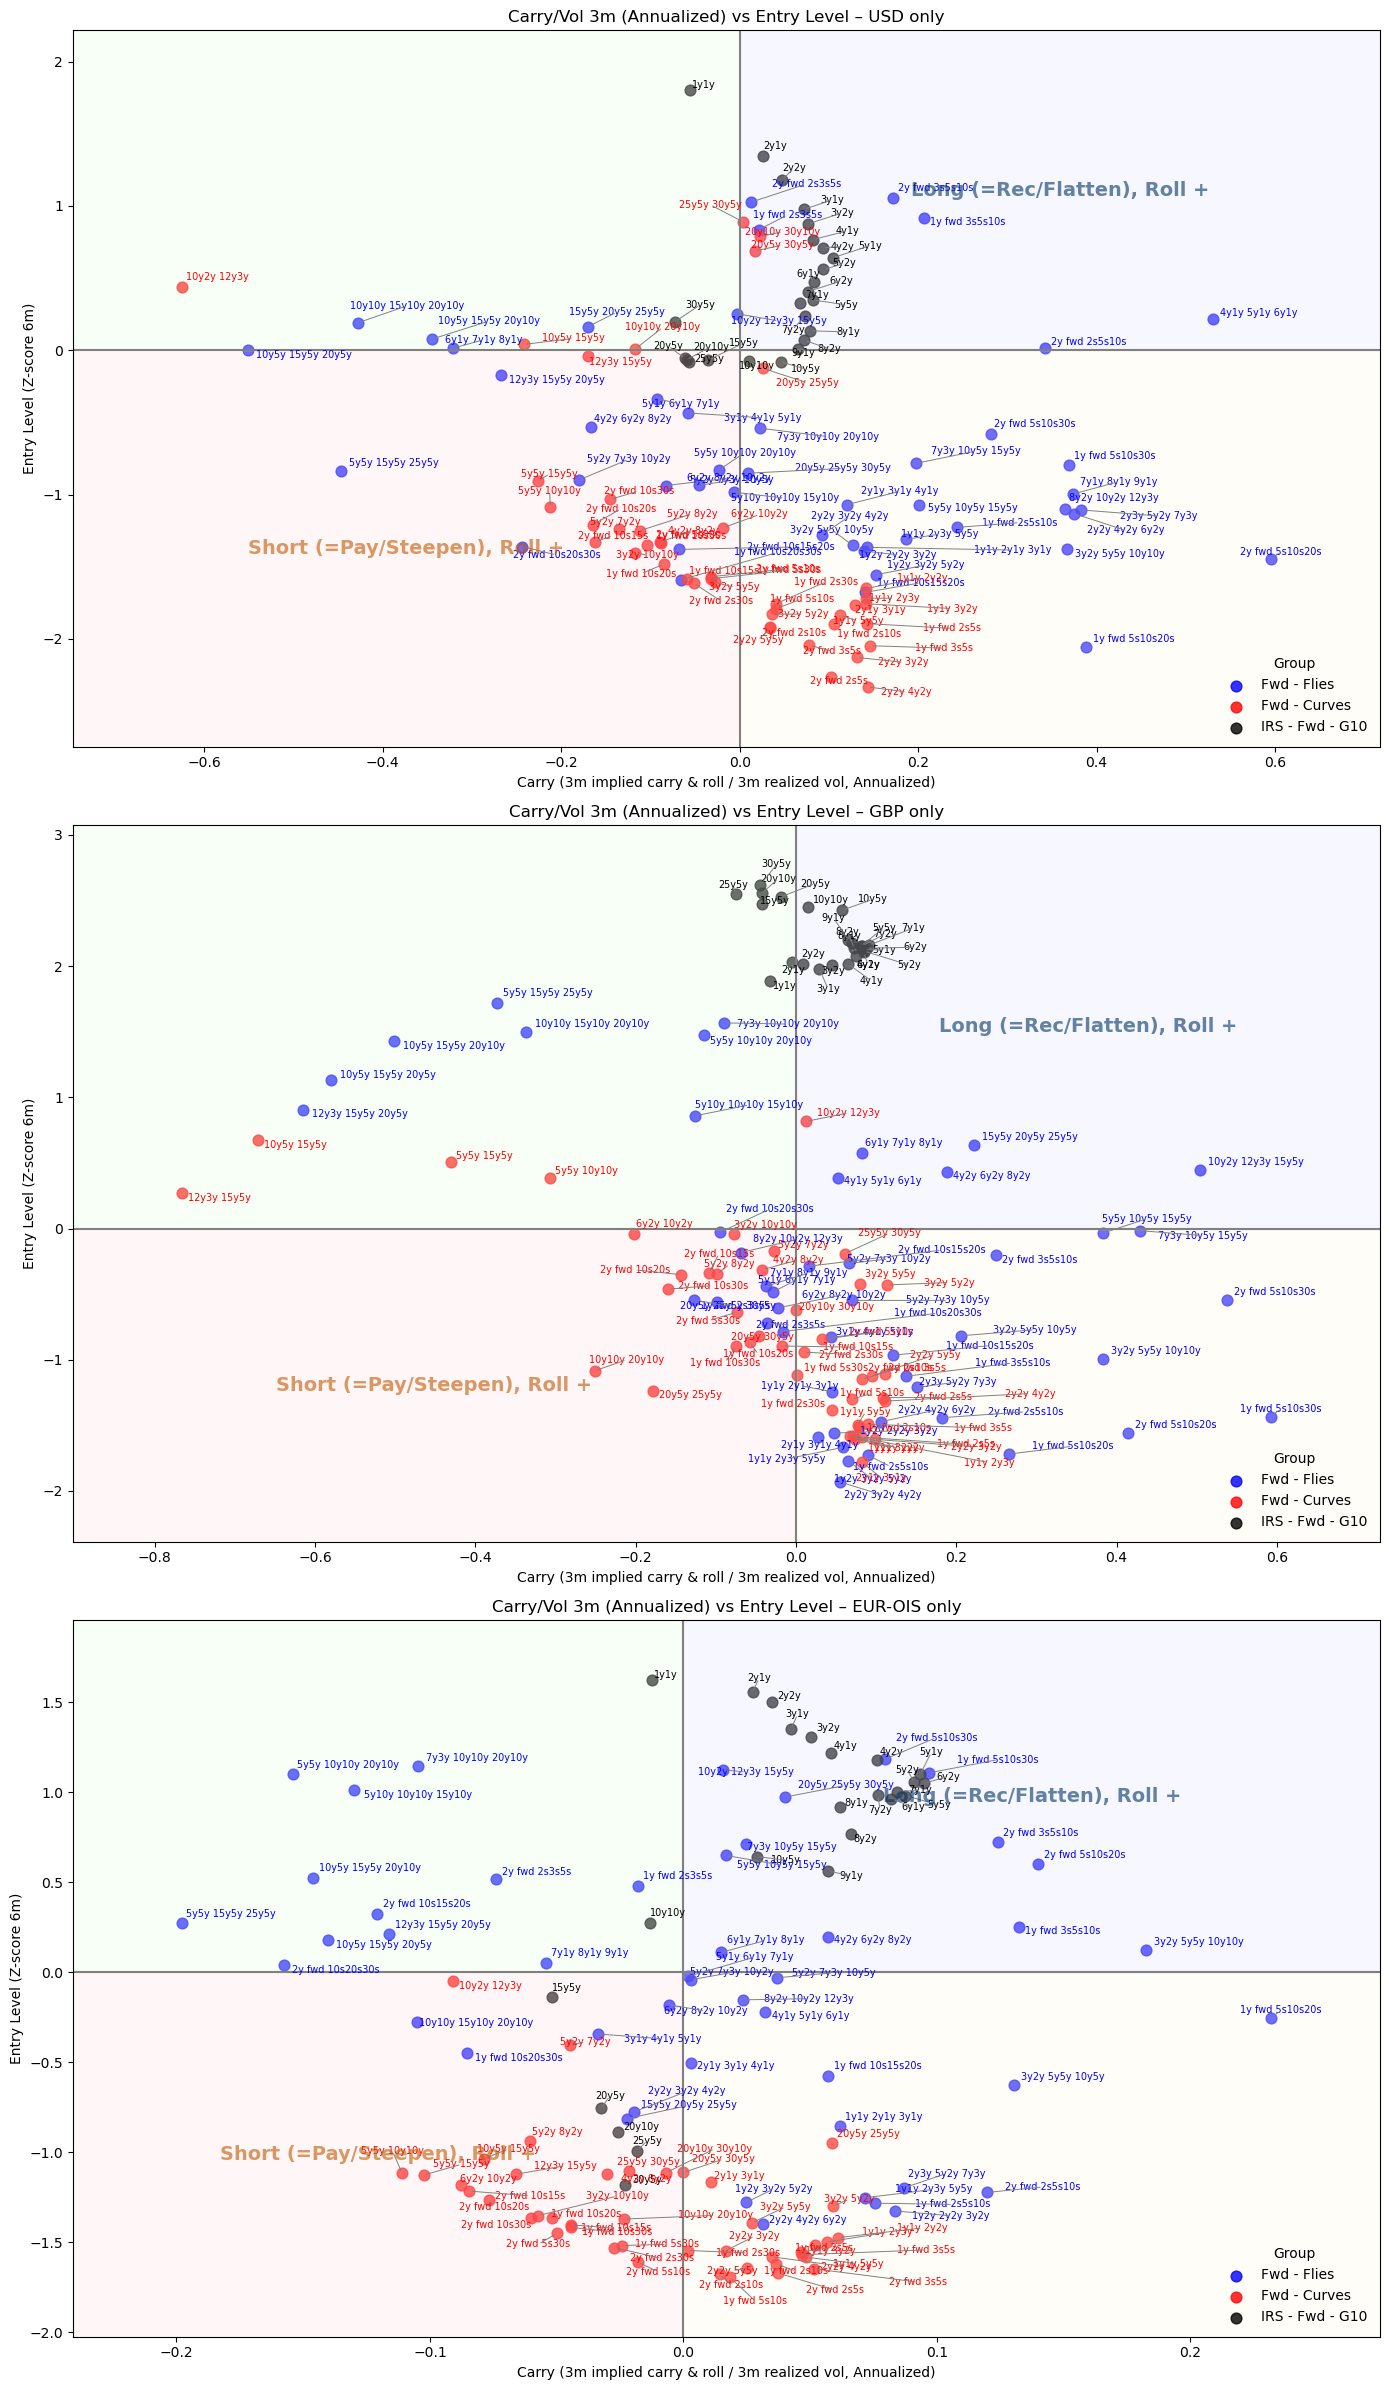

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
import re

# ---- BLACKLIST : Stranauctures à SUPPRIMER ----
# Ajoute ici toutes les structures que tu veux enlever (sans le préfixe devise)
blacklist = [
    # Exemple de structures complexes à supprimer
    "4y1y 5y1y", "5y1y 6y1y", "6y1y 7y1y", "7y1y 8y1y", "8y1y 9y1y", "9y1y 10y1y",
    "3y2y 4y2y", "4y2y 6y2y", "6y2y 8y2y", "8y2y 10y2y",
    "35y5y", "40y5y", "3y1y 4y1y", "20y10y 30y20y", "15y5y 20y10y", "5y2y 7y2y 9y2y", "3y2y 5y2y 7y2y",
    "6m fwd 2s5s","6m fwd 3s5s","6m fwd 5s10s","6m fwd 10s20s","6m fwd 10s30s","6m fwd 5s30s","6m fwd 10s15s","6m fwd 2s10s","6m fwd 2s30s",
    "6m fwd 2s5s10s","6m fwd 2s3s5s","6m fwd 3s5s10s","6m fwd 10s15s20s","6m fwd 5s10s20s","6m fwd 5s10s30s","6m fwd 10s20s30s"
    # Ajoute ici TOUTES les structures que tu veux supprimer
]

# Fonction pour vérifier si une structure est dans la blacklist
def is_blacklisted(structure):
    """Vérifie si la structure doit être supprimée"""
    # Nettoyer le nom (enlever devise et préfixes)
    clean = re.sub(r'^[A-Z]{3}(-OIS)?[_\-\s]*', '', structure)
    return clean in blacklist

# ---- Paramètres ----
wanted = ["Fwd - Flies", "Fwd - Curves", "IRS - Fwd - G10"]
color_map = {"Fwd - Flies": "blue", "Fwd - Curves": "red", "IRS - Fwd - G10": "black"}
margin = 0.1
ccys = ["USD", "GBP", "EUR-OIS"]

fig, axes = plt.subplots(len(ccys), 1, figsize=(14, 8 * len(ccys)))

for ax, ccy in zip(axes, ccys):
    # Sélection des colonnes et nettoyage des NaN
    df_ccy = (df_all[["Structure", "Zscore_6m", "carry_3m", "Stdev_3m", "Group"]]
                .drop_duplicates("Structure")
                .dropna(subset=["Zscore_6m", "carry_3m", "Stdev_3m", "Group"])
                .query("Structure.str.contains(@ccy)", engine="python"))
    
    df_ccy = df_ccy[df_ccy.Group.isin(wanted)].copy()
    
    print(f"\n{ccy} - Avant suppression : {len(df_ccy)} structures")
    
    # ⭐ SUPPRIMER LES STRUCTURES BLACKLISTÉES ⭐
    df_ccy = df_ccy[~df_ccy.Structure.apply(is_blacklisted)].copy()
    
    print(f"{ccy} - Après suppression : {len(df_ccy)} structures ✅")
    
    if len(df_ccy) == 0:
        print(f"⚠️  Aucune structure restante pour {ccy}")
        continue
    
    df_ccy["Clean"] = df_ccy.Structure.str.replace(rf"^{ccy}[_\-\s]*", "", regex=True)
    
    # Annualisation du carry et de la stdev
    df_ccy["carry_3m_ann"] = df_ccy["carry_3m"] * 4
    df_ccy["Stdev_3m_ann"] = df_ccy["Stdev_3m"] * np.sqrt(252)
    df_ccy["carry3m_ann_per_vol3m_ann"] = df_ccy["carry_3m_ann"] / df_ccy["Stdev_3m_ann"]
    
    # Bornes des axes avec marges
    x0, x1 = df_ccy.carry3m_ann_per_vol3m_ann.min(), df_ccy.carry3m_ann_per_vol3m_ann.max()
    dx = (x1 - x0) * margin
    x_min, x_max = x0 - dx, x1 + dx
    
    y0, y1 = df_ccy.Zscore_6m.min(), df_ccy.Zscore_6m.max()
    dy = (y1 - y0) * margin
    y_min, y_max = y0 - dy, y1 + dy
    
    # Scatter plot par groupe
    for grp in wanted:
        sub = df_ccy[df_ccy.Group == grp]
        ax.scatter(sub.carry3m_ann_per_vol3m_ann, sub.Zscore_6m,
                   s=60, color=color_map[grp], label=grp, alpha=0.8)
    
    # Labels intelligents
    texts = []
    for _, r in df_ccy.iterrows():
        texts.append(ax.text(r.carry3m_ann_per_vol3m_ann, r.Zscore_6m, r.Clean,
                             fontsize=7, color=color_map[r.Group]))
    
    adjust_text(
        texts, ax=ax, only_move={'text': 'xy'},
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.7),
        expand_text=(1.05, 1.2), force_text=0.1, force_points=0.1
    )
    
    # Quadrants de couleur
    ax.fill_betweenx([y_min, 0], x_min, 0, color="#ffe6e6", alpha=0.3)
    ax.fill_betweenx([0, y_max], x_min, 0, color="#e6ffe6", alpha=0.3)
    ax.fill_betweenx([0, y_max], 0, x_max, color="#e6e6ff", alpha=0.3)
    ax.fill_betweenx([y_min, 0], 0, x_max, color="#fff9e6", alpha=0.3)
    ax.axhline(0, color="gray")
    ax.axvline(0, color="gray")
    
    # Légendes dans les quadrants
    quad_fs = 14
    ax.text(x_max/2, y_max/2, "Long (=Rec/Flatten), Roll +", ha="center", va="center",
            fontsize=quad_fs, color="#003366", alpha=0.6, fontweight="bold")
    ax.text(x_min/2, y_min/2, "Short (=Pay/Steepen), Roll +", ha="center", va="center",
            fontsize=quad_fs, color="#c25800", alpha=0.6, fontweight="bold")
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Carry/Vol 3m (Annualized) vs Entry Level – {ccy} only")
    ax.set_xlabel("Carry (3m implied carry & roll / 3m realized vol, Annualized)")
    ax.set_ylabel("Entry Level (Z-score 6m)")
    ax.legend(title="Group", frameon=False, fontsize=10, loc="lower right")

plt.tight_layout()
fig.savefig("carry_vs_vol3m_filtered.png", dpi=150)
plt.show()

# F. EMAIL CONFO

In [22]:
import os
import base64
import win32com.client as win32

def encode_image(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image introuvable : {path}")
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

image_path = r"\\cad.local\dfsroot\GroupShares\PARIS\CAVENTOR\Code Analytics\Python\2.Swap\carry_vs_vol3m_filtered.png"
b64_carry = encode_image(image_path)

# 2) Convertissez vos pandas.Styler en HTML
html_ccy1 = styled_ccy1.to_html()
html_ccy2 = styled_ccy2.to_html()
html_xmkt = styled_xmkt.to_html()

# 3) Corps HTML avec métriques de backtest expliquées
html_body = f"""
<html>
  <head>
    <style>
      body {{ font-family: Arial, sans-serif; font-size:10pt; }}
      h2   {{ margin:20px 0 5px; text-align:center; }}
      table {{ border-collapse:collapse; width:100%; table-layout:fixed; }}
      th, td {{ border:1px solid #ddd; padding:4px 8px; font-size:9pt;
               max-width:120px; word-wrap:break-word; }}
      .metric-title {{ font-weight: bold; color: #2c3e50; }}
      .formula {{ background-color: #f0f0f0; padding: 3px 6px; border-radius: 3px; font-family: monospace; font-size: 9pt; }}
    </style>
  </head>
  <body>
    <p>Good morning,</p>
    <p style="background-color: #fff3cd; padding: 12px; border-left: 4px solid #ffc107; margin-bottom: 15px;">
      <strong>Please note that this is a purely mathematical model, highlighting only the most statistically extreme structures in the current market — it does not incorporate any macroeconomic or fundamental views.</strong>
    </p>
    <p>
      Below you'll find today's updates of the SWAP models with <strong>enhanced backtest metrics</strong>.<br>
      The models now include historical performance analysis over different trading horizons.<br>
      <strong>ALL METRICS AND THE BACKTESTING MODEL ARE EXPLAINED BELOW THE THREE TABLES.</strong><br>
    </p>

    <h2> Outright & Spread</h2>
    {html_ccy1}

    <h2>Flies</h2>
    {html_ccy2}

    <h2>X-MKT</h2>
    {html_xmkt}

    <h2>📊 BACKTEST Metric Definitions </h2>
    <p style="background-color: #e8f4f8; padding: 10px; border-left: 4px solid #3498db;">
      <strong>Important:</strong> Important: All backtest metrics are calculated using historical data when similar market conditions occurred. Each trade is then simulated over a forward holding period determined by the selected backtest framework.
    </p>
    
    <ol>
      <li>
        <span class="metric-title">Backtested_Win_rate_%</span>
        <ul>
          <li>Percentage of historical trades that were profitable under similar conditions</li>
          <li>Calculated when a combination of RSI, Z-Score, Yield Ratio, Moving Average positioning, and other technical indicators align with conditions comparable to the current market setup</li>
          <li>Trade management includes take-profit levels and trailing stop levels</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">RR_Vol_and_Proba_Adj (Risk-Reward Ratio)</span>
        <ul>
          <li><span class="formula">(Win_Rate × Avg_Win_Vol_Adj) / (Loss_Rate × Avg_Loss_Vol_Adj)</span></li>
          <li>Combines win probability with average risk-reward, normalized by volatility</li>
          <li><strong>Filter applied: Only showing trades with RR > 1.4 or "Only wins"</strong></li>
          <li>Values > 2.0 indicate excellent risk-adjusted opportunities</li>
          <li>"Only wins" = 100% historical win rate (no losses in backtest)</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">Expected_Win (in basis points)</span>
        <ul>
          <li>Average historical winning trade size × current volatility horizon</li>
          <li>Represents the expected gain if the trade reaches its target</li>
          <li>Calculated as: <span class="formula">Avg_Win_Vol_Adjusted × Vol_Horizon_Today</span></li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">Stop_Loss (in basis points)</span>
        <ul>
          <li>Optimal stop loss based on historical performance</li>
          <li>Calculated as: <span class="formula">Expected_Win / RR_Vol_and_Proba_Adj</span></li>
        </ul>
      </li>
    </ol>

    <h2>📈 Signal & Technical Metrics</h2>
    <ol>
      <li>
        <span class="metric-title">Latest Total Signal (CTA Signal)</span>
        <ul>
          <li>Aggregate CTA positioning signal ranging from -50 to +50</li>
          <li><strong>+50</strong> = CTAs are extremely long (maximum bullish positioning) – market receives the structure</li>
          <li><strong>0</strong> = Neutral positioning</li>
          <li><strong>-50</strong> = CTAs are extremely short (maximum bearish positioning) - market pays the structure</li>
          <li>This represents systematic trend-following funds' aggregate position</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">1 Week Change in Signal / 1 Day Change in Signal</span>
        <ul>
          <li>Evolution of the CTA signal over 1 week and 1 day respectively</li>
          <li>Shows momentum: is positioning increasing or decreasing?</li>
          <li><strong>Important:</strong> If the sign is opposite to Latest Total Signal, it indicates a reversal in momentum</li>
          <li>Example: Signal at +30 with 1W Change of -5 means CTAs are reducing longs</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">NoShock_5D_Change</span>
        <ul>
          <li>Predicted CTA signal change over the next 5 days assuming no market shocks</li>
          <li>Based on current momentum and systematic rules</li>
          <li>Helps anticipate future CTA flows before they happen</li>
          <li>Positive value = CTAs expected to add to longs/reduce shorts</li>
          <li>Negative value = CTAs expected to reduce longs/add to shorts</li>
        </ul>
      </li>
      
        <li>
          <span class="metric-title">MR_Score (Mean Reversion Score)</span>
          <ul>
            <li>Composite indicator measuring the overall mean reversion attractiveness of a structure</li>
            <li>Combines multiple layers of market information, including statistical dislocation, relative positioning, and reversion efficiency</li>
            <li>Ranges from 0 to 1, with higher values indicating a stronger historical tendency to normalize from current levels</li>
            <li><strong>Score &gt; 0.25</strong> = Meaningful mean reversion profile (filter applied)</li>
          </ul>
        </li>
      
      <li>
        <span class="metric-title">ZScore_6m / ZScore_1m</span>
        <ul>
          <li><span class="formula">(Current Value - Mean) / Standard Deviation</span></li>
          <li>6m = 126 trading days, 1m = 21 trading days</li>
          <li>Values > 2 or < -2 indicate extreme conditions</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">YieldRatio_6m / YieldRatio_1m</span>
        <ul>
          <li><span class="formula">(Current - Min) / (Max - Min)</span></li>
          <li>Normalized position in the historical range [0 to 1]</li>
          <li>0.95+ = near 6m/1m highs, 0.05- = near 6m/1m lows</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">MA20_Position_%</span>
        <ul>
          <li><span class="formula">((Current - Lower Band) / (Upper Band - Lower Band)) × 100</span></li>
          <li>Position within Bollinger Bands (MA20 ± 2σ)</li>
          <li>>95% = extreme overbought, <5% = extreme oversold</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">Metric_Lookback_for_Backtesting</span>
        <ul>
          <li>Optimal historical window (in months) used to calculate Z-Score, Yield Ratio, Moving Average, RSI, and other technical metrics for backtest similarity matching</li>
          <li>The algorithm dynamically selects the best lookback period that maximizes predictive accuracy</li>
          <li>This adaptive approach ensures we're comparing the current trade setup to the most relevant historical analogues</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">RSI14d</span>
        <ul>
          <li>14-day Relative Strength Index (Wilder's method)</li>
          <li>>70 = overbought, <30 = oversold</li>
          <li>Used in conjunction with other metrics for trade entry</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">Vol3w/Vol3m, Annualized</span>
        <ul>
          <li><span class="formula">3-week volatility / 3-month volatility</span></li>
          <li>>1 = Recent volatility exceeding historical average</li>
        </ul>
      </li>
      
      <li>
        <span class="metric-title">carry_3m (3-Month Carry, in basis points)</span>
        <ul>
          <li>Expected profit/loss from holding the structure for 3 months, expressed in basis points</li>
          <li><strong>Trading assumption:</strong> You are assumed to be <strong>long (receiving)</strong> the structure by default</li>
          <li><strong>Carry interpretation:</strong>
            <ul>
              <li><strong style="color: green;">Positive carry (+)</strong> = You earn carry by receiving the structure (favorable)</li>
              <li><strong style="color: red;">Negative carry (-)</strong> = You pay carry by receiving the structure (unfavorable)</li>
            </ul>
          </li>
          <li><strong>For short (paying) positions:</strong> Simply reverse the sign
            <ul>
              <li>If carry_3m = +5 bp and you pay the structure → you earn +5 bp carry</li>
              <li>If carry_3m = -5 bp and you pay the structure → you pay -5 bp carry (cost)</li>
            </ul>
          </li>
          <li>Higher positive carry values indicate better income-generating opportunities when receiving</li>
        </ul>
      </li>
    </ol>

    <h2>📈 Carry vs Volatility (3m)</h2>
    <p>
      The chart below shows the relationship between <strong>3-month carry</strong> and 
      <strong>3-month realized volatility</strong> for the main forward structures.<br>
      This visualization helps identify structures offering attractive carry relative to their volatility risk.
    </p>
    
    <img src="data:image/png;base64,{b64_carry}"
         style="max-width:700px; width:100%; display:block; margin:15px auto;">

    <p style="margin-top: 30px; padding-top: 20px; border-top: 2px solid #e0e0e0;">
      <strong>Note on Backtest Methodology:</strong><br>
      • Historical analysis covers ~5 years of data<br>
      • Volatility-adjusted metrics ensure comparability across different market regimes<br>
      • The backtest uses an adaptive lookback window for metric calculations to find the most relevant historical analogues<br>
    </p>

    <p>Best regards,<br>Samuel SARIAN</p>
  </body>
</html>
"""

# 4) Ouvrez le brouillon Outlook
outlook = win32.Dispatch("outlook.application")
mail = outlook.CreateItem(0)
mail.To = "samuel.sarian@caventorcapital.com"
mail.Subject = "Daily Swap Models with Backtest Analytics: G10"
mail.HTMLBody = html_body
mail.Display()

GRAPH

Modules importés avec succès
❌ Aucun DataFrame de bandes Bollinger trouvé
📋 Assurez-vous d'avoir exécuté le code de calcul des bandes de Bollinger



Choisissez la fenêtre (1-1):  1



📊 Nombre de barres à afficher:
1. 100 dernières barres
2. 250 dernières barres
3. 500 dernières barres
4. 1000 dernières barres
5. Toutes les données
6. Nombre personnalisé



Choisissez (1-6):  2



🎨 Génération du graphique...
   📊 Dataset: df_with_bb
   🎯 Instrument: EUR-6s 2s-3s-5s
   📏 Fenêtre: 20 jours
   📈 Barres: 250

📊 STATISTIQUES - EUR-6s 2s-3s-5s (BB20):
   💰 Yield actuel: -4.845
   📈 Bande supérieure: -3.125
   📊 Moyenne mobile: -7.280
   📉 Bande inférieure: -11.434
   📍 Position: 79.3% dans la bande
   🔺 Breaks hauts: 12
   🔻 Breaks bas: 6


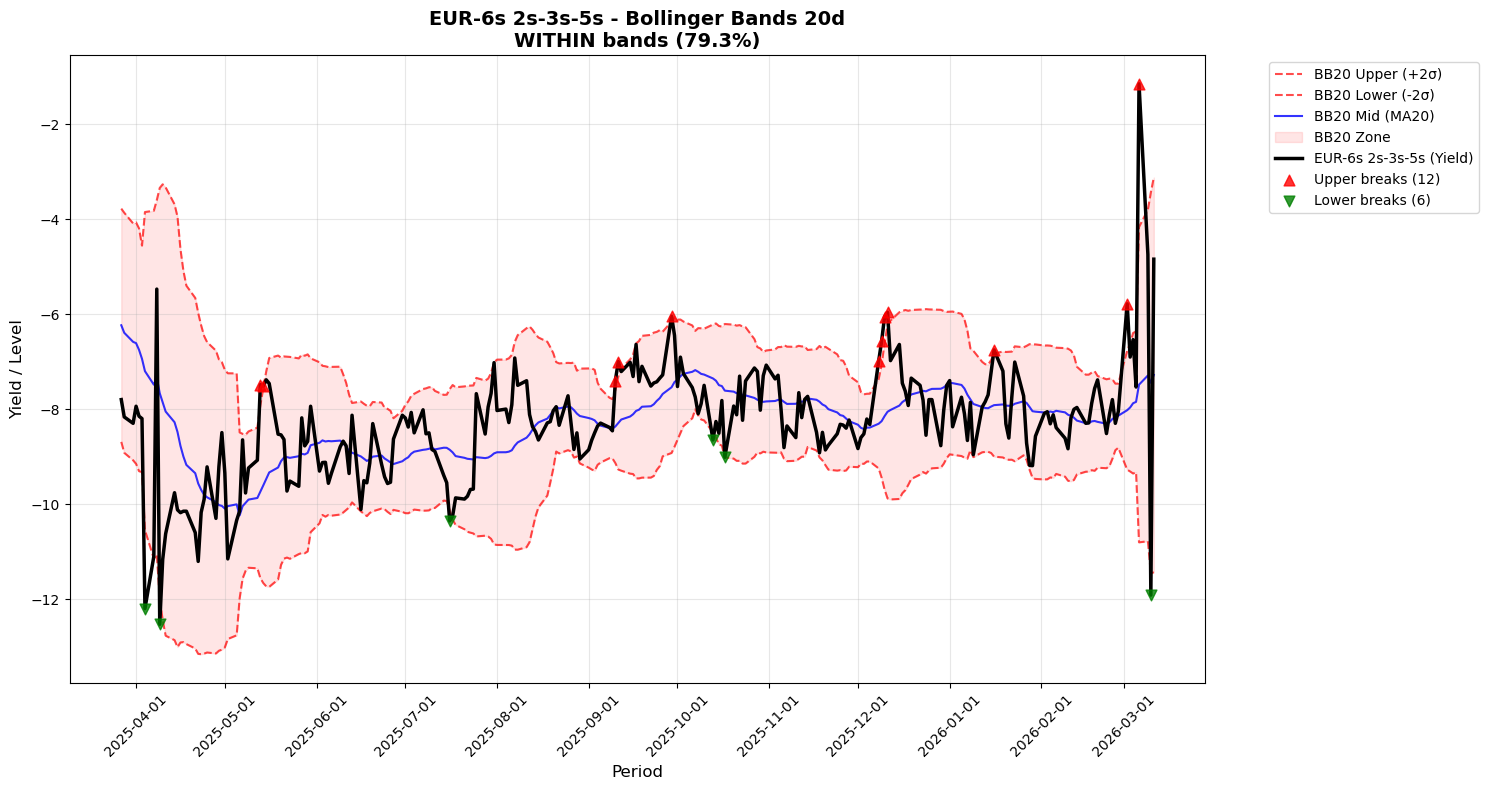


🔄 Voulez-vous afficher un autre graphique? (y/n):  y



INTERACTIVE BOLLINGER BANDS VIEWER

Available datasets:
1. df_with_bb (Main structures)
2. df_cross_with_bb (Cross-CCY)



Choisissez le dataset (1-2):  1



📋 Instruments disponibles dans df_with_bb (1021):
  1. EUR-OIS 5s-2s
  2. EUR-OIS 5s-3s
  3. EUR-OIS 7s-5s
  4. EUR-OIS 10s-5s
  5. EUR-OIS 10s-7s
  6. EUR-OIS 20s-10s
  7. EUR-OIS 30s-2s
  8. EUR-OIS 30s-5s
  9. EUR-OIS 15s-10s
 10. EUR-OIS 10s-2s
 11. EUR-OIS 30s-10s
 12. EUR-OIS 15s-7s
 13. EUR-OIS 3s-2s
 14. EUR-OIS 20s-7s
 15. EUR-OIS 30s-3s
 16. EUR-6s 5s-2s
 17. EUR-6s 5s-3s
 18. EUR-6s 7s-5s
 19. EUR-6s 10s-5s
 20. EUR-6s 10s-7s
 21. EUR-6s 20s-10s
 22. EUR-6s 30s-2s
 23. EUR-6s 30s-5s
 24. EUR-6s 15s-10s
 25. EUR-6s 10s-2s
 26. EUR-6s 30s-10s
 27. EUR-6s 15s-7s
 28. EUR-6s 3s-2s
 29. EUR-6s 20s-7s
 30. EUR-6s 30s-3s
 31. GBP 5s-2s
 32. GBP 5s-3s
 33. GBP 7s-5s
 34. GBP 10s-5s
 35. GBP 10s-7s
 36. GBP 20s-10s
 37. GBP 30s-2s
 38. GBP 30s-5s
 39. GBP 15s-10s
 40. GBP 10s-2s
 41. GBP 30s-10s
 42. GBP 15s-7s
 43. GBP 3s-2s
 44. GBP 20s-7s
 45. GBP 30s-3s
 46. USD 5s-2s
 47. USD 5s-3s
 48. USD 7s-5s
 49. USD 10s-5s
 50. USD 10s-7s
 51. USD 20s-10s
 52. USD 30s-2s
 53. USD 30s-5s
 


Choisissez un instrument (1-1021) ou 'q' pour quitter:  840



📏 Fenêtres Bollinger disponibles pour EUR-OIS 6m2y-6m3y-6m5y:
1. 20 jours ✅



Choisissez la fenêtre (1-1):  1



📊 Nombre de barres à afficher:
1. 100 dernières barres
2. 250 dernières barres
3. 500 dernières barres
4. 1000 dernières barres
5. Toutes les données
6. Nombre personnalisé



Choisissez (1-6):  2



🎨 Génération du graphique...
   📊 Dataset: df_with_bb
   🎯 Instrument: EUR-OIS 6m2y-6m3y-6m5y
   📏 Fenêtre: 20 jours
   📈 Barres: 250

📊 STATISTIQUES - EUR-OIS 6m2y-6m3y-6m5y (BB20):
   💰 Yield actuel: -6.713
   📈 Bande supérieure: -5.607
   📊 Moyenne mobile: -7.664
   📉 Bande inférieure: -9.722
   📍 Position: 73.1% dans la bande
   🔺 Breaks hauts: 12
   🔻 Breaks bas: 7


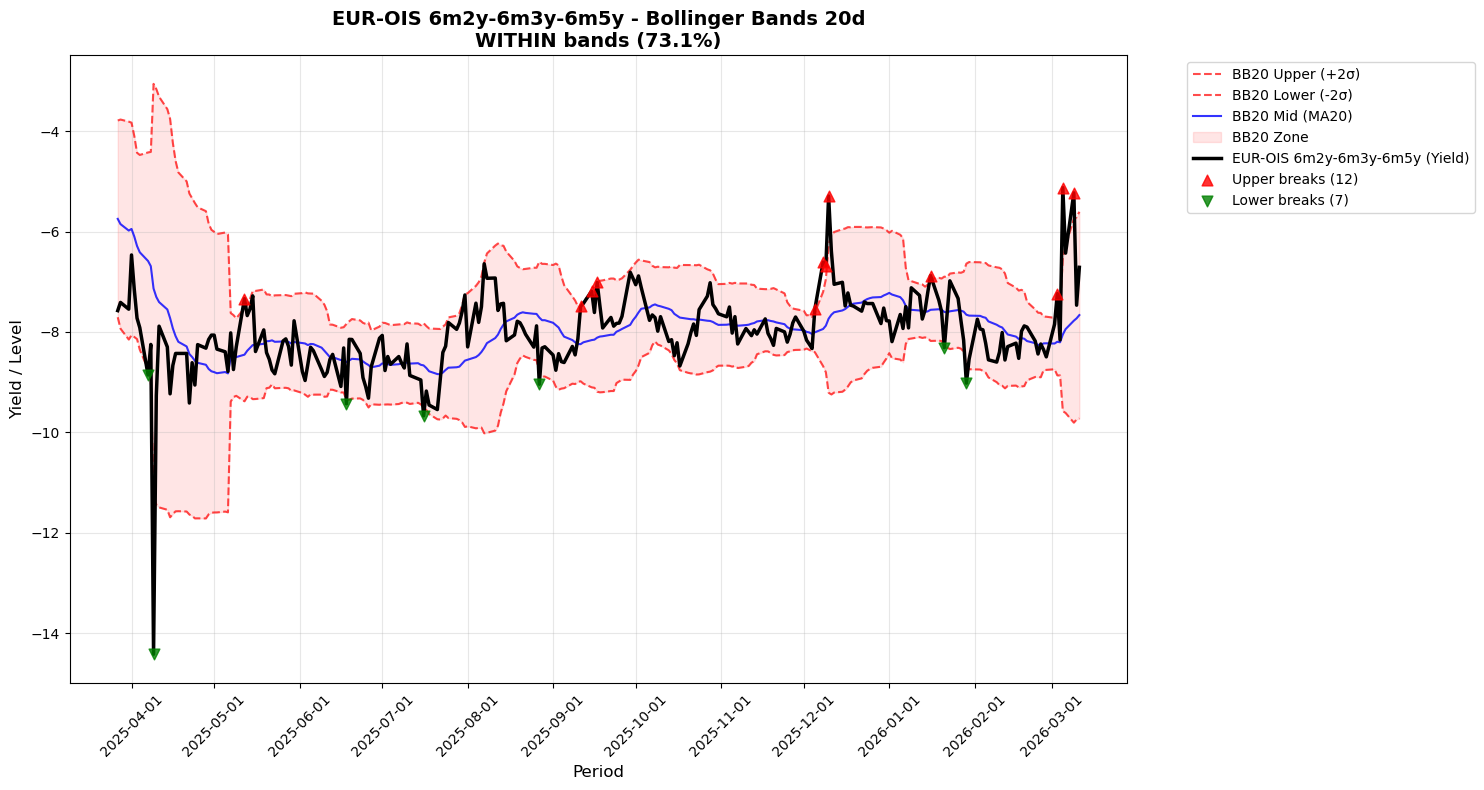


🔄 Voulez-vous afficher un autre graphique? (y/n):  n


In [62]:
# Testez si les modules sont disponibles
try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    print("Modules importés avec succès")
except ImportError as e:
    print(f"Erreur d'import: {e}")

### import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

def plot_bollinger_bands(df_data, instrument, window_days=20, nb_bars=500, chart_type='both'):
    """
    Trace les bandes de Bollinger pour un instrument donné
    
    Parameters:
    -----------
    df_data : DataFrame
        DataFrame contenant les données (df_with_bb ou df_cross_with_bb)
    instrument : str
        Nom de l'instrument/structure à afficher
    window_days : int
        Nombre de jours pour les bandes de Bollinger (20 ou 50)
    nb_bars : int
        Nombre de barres à afficher
    chart_type : str
        'both', 'bb20', 'bb50' - quelles bandes afficher
    """
    
    # Vérification que l'instrument existe
    if instrument not in df_data.columns:
        print(f"❌ Instrument '{instrument}' non trouvé dans les données")
        available = [col for col in df_data.columns if not col.endswith(('_upper', '_lower', '_mid'))]
        print(f"📋 Instruments disponibles : {available[:10]}...")  # Première 10
        return
    
    # Colonnes nécessaires
    yield_col = instrument
    mid_col = f"{instrument}_BB{window_days}_mid"
    upper_col = f"{instrument}_BB{window_days}_upper" 
    lower_col = f"{instrument}_BB{window_days}_lower"
    
    # Vérification que les colonnes Bollinger existent
    missing_cols = []
    for col in [mid_col, upper_col, lower_col]:
        if col not in df_data.columns:
            missing_cols.append(col)
    
    if missing_cols:
        print(f"❌ Colonnes manquantes : {missing_cols}")
        print(f"📋 Fenêtres disponibles pour {instrument}:")
        for w in [20, 50]:
            test_col = f"{instrument}_BB{w}_mid"
            if test_col in df_data.columns:
                print(f"   - {w} jours ✅")
            else:
                print(f"   - {w} jours ❌")
        return
    
    # Extraction des données
    data = df_data[[yield_col, mid_col, upper_col, lower_col]].dropna()
    
    # Limitation selon nb_bars
    if len(data) > nb_bars:
        data = data.tail(nb_bars)
    
    if len(data) == 0:
        print(f"❌ Aucune donnée disponible pour {instrument}")
        return
    
    # Préparation des dates - utiliser l'index du DataFrame
    dates = data.index
    
    # Si le DataFrame original a une colonne 'Date' et qu'on peut la récupérer
    if 'Date' in df_data.columns:
        try:
            # Essayer de récupérer les dates correspondantes
            original_dates = df_data.loc[data.index, 'Date']
            if not original_dates.empty:
                dates = original_dates
        except (KeyError, IndexError):
            # Si ça échoue, garder l'index original
            pass
    
    # Vérifier si on a des vraies dates
    try:
        if hasattr(dates.iloc[0], 'strftime'):
            x_values = dates  # Utiliser directement les dates
            date_labels = None  # Pas besoin de labels séparés
        else:
            # Fallback: utiliser des indices numériques
            x_values = range(len(dates))
            date_labels = [str(d) for d in dates]
    except (AttributeError, IndexError):
        # En cas d'erreur, utiliser des indices numériques
        x_values = range(len(data))
        date_labels = [str(i) for i in range(len(data))]
    
    # Création du graphique
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # ═══ TRACÉ DES BANDES DE BOLLINGER ═══
    
    if chart_type in ['both', f'bb{window_days}']:
        # Bande supérieure
        ax.plot(x_values, data[upper_col], 
                color='red', linestyle='--', alpha=0.7, linewidth=1.5,
                label=f'BB{window_days} Upper (+2σ)')
        
        # Bande inférieure  
        ax.plot(x_values, data[lower_col],
                color='red', linestyle='--', alpha=0.7, linewidth=1.5,
                label=f'BB{window_days} Lower (-2σ)')
        
        # Moyenne mobile (milieu)
        ax.plot(x_values, data[mid_col],
                color='blue', linestyle='-', alpha=0.8, linewidth=1.5,
                label=f'BB{window_days} Mid (MA{window_days})')
        
        # Zone entre les bandes (remplissage)
        ax.fill_between(x_values, data[upper_col], data[lower_col],
                        color='red', alpha=0.1, label=f'BB{window_days} Zone')
    
    # ═══ TRACÉ DU YIELD (SÉRIE PRINCIPALE) ═══
    ax.plot(x_values, data[yield_col],
            color='black', linestyle='-', linewidth=2.5,
            label=f'{instrument} (Yield)', zorder=5)
    
    # ═══ DÉTECTION DES BREAKS ═══
    
    # Points où le yield dépasse les bandes
    breaks_upper = data[yield_col] > data[upper_col]
    breaks_lower = data[yield_col] < data[lower_col]
    
    # Marqueurs pour les breaks
    if breaks_upper.any():
        break_points_up = data[breaks_upper]
        try:
            if date_labels is None:
                # On a de vraies dates
                break_dates = dates[breaks_upper]
            else:
                # On utilise des indices
                break_dates = [i for i, val in enumerate(breaks_upper) if val]
            
            ax.scatter(break_dates, break_points_up[yield_col],
                      color='red', marker='^', s=60, alpha=0.8,
                      label=f'Upper breaks ({breaks_upper.sum()})', zorder=6)
        except Exception:
            # Fallback: utiliser des indices
            ax.scatter([i for i, val in enumerate(breaks_upper) if val], 
                      break_points_up[yield_col],
                      color='red', marker='^', s=60, alpha=0.8,
                      label=f'Upper breaks ({breaks_upper.sum()})', zorder=6)
    
    if breaks_lower.any():
        break_points_down = data[breaks_lower]
        try:
            if date_labels is None:
                # On a de vraies dates
                break_dates = dates[breaks_lower]
            else:
                # On utilise des indices
                break_dates = [i for i, val in enumerate(breaks_lower) if val]
            
            ax.scatter(break_dates, break_points_down[yield_col], 
                      color='green', marker='v', s=60, alpha=0.8,
                      label=f'Lower breaks ({breaks_lower.sum()})', zorder=6)
        except Exception:
            # Fallback: utiliser des indices
            ax.scatter([i for i, val in enumerate(breaks_lower) if val],
                      break_points_down[yield_col], 
                      color='green', marker='v', s=60, alpha=0.8,
                      label=f'Lower breaks ({breaks_lower.sum()})', zorder=6)
    
    # ═══ STATISTIQUES RAPIDES ═══
    
    # Position actuelle dans la bande
    current_yield = data[yield_col].iloc[-1]
    current_upper = data[upper_col].iloc[-1]
    current_lower = data[lower_col].iloc[-1]
    
    if current_upper != current_lower:
        position_pct = ((current_yield - current_lower) / 
                       (current_upper - current_lower) * 100)
    else:
        position_pct = 50
    
    # Détermination du statut
    if current_yield > current_upper:
        status = f"ABOVE bands (+{current_yield - current_upper:.2f})"
        status_color = 'black'
    elif current_yield < current_lower:
        status = f"BELOW bands ({current_yield - current_lower:.2f})"
        status_color = 'black'
    else:
        status = f"WITHIN bands ({position_pct:.1f}%)"
        status_color = 'black'
    
    # ═══ MISE EN FORME DU GRAPHIQUE ═══
    
    # Titre avec informations
    title = f'{instrument} - Bollinger Bands {window_days}d\n{status}'
    ax.set_title(title, fontsize=14, weight='bold', color=status_color)
    
    # Labels et grille
    ax.set_ylabel('Yield / Level', fontsize=12)
    ax.set_xlabel('Period', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Gestion des dates sur l'axe X
    if date_labels is None:
        # On a de vraies dates, laisser matplotlib gérer automatiquement
        ax.tick_params(axis='x', rotation=45)
        # Formater les dates si nécessaire
        if len(dates) > 20:
            from matplotlib.dates import DateFormatter, MonthLocator
            ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
            if len(dates) > 100:
                ax.xaxis.set_major_locator(MonthLocator(interval=1))
    else:
        # Fallback pour indices numériques
        step = max(1, len(dates) // 10)
        tick_positions = range(0, len(dates), step)
        tick_labels_display = [date_labels[i] for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels_display, rotation=45, ha='right')
    
    # Légende
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
    
    # Ajustement automatique
    plt.tight_layout()
    
    # ═══ AFFICHAGE DES STATISTIQUES ═══
    print(f"\n📊 STATISTIQUES - {instrument} (BB{window_days}):")
    print(f"   💰 Yield actuel: {current_yield:.3f}")
    print(f"   📈 Bande supérieure: {current_upper:.3f}")
    print(f"   📊 Moyenne mobile: {data[mid_col].iloc[-1]:.3f}")
    print(f"   📉 Bande inférieure: {current_lower:.3f}")
    print(f"   📍 Position: {position_pct:.1f}% dans la bande")
    print(f"   🔺 Breaks hauts: {breaks_upper.sum()}")
    print(f"   🔻 Breaks bas: {breaks_lower.sum()}")
    
    plt.show()

def interactive_bollinger_menu():
    """
    Menu interactif pour choisir et visualiser les bandes de Bollinger
    """
    print("\n" + "="*60)
    print("INTERACTIVE BOLLINGER BANDS VIEWER")
    print("="*60)
    
    # Choix du dataset
    print("\nAvailable datasets:")
    print("1. df_with_bb (Main structures)")
    print("2. df_cross_with_bb (Cross-CCY)")
    
    while True:
        try:
            dataset_choice = input("\nChoisissez le dataset (1-2): ").strip()
            if dataset_choice == '1':
                if 'df_with_bb' not in globals():
                    print("df_with_bb not available")
                    continue
                selected_df = df_with_bb
                df_name = "df_with_bb"
                break
            elif dataset_choice == '2':
                if 'df_cross_with_bb' not in globals():
                    print("df_cross_with_bb not available") 
                    continue
                selected_df = df_cross_with_bb
                df_name = "df_cross_with_bb"
                break
            else:
                print("Please enter 1 or 2")
        except:
            print("Input error")
    
    # Liste des instruments disponibles
    instruments = [col for col in selected_df.columns 
                  if not col.endswith(('_upper', '_lower', '_mid')) and col != 'Date']
    
    print(f"\n📋 Instruments disponibles dans {df_name} ({len(instruments)}):")
    for i, inst in enumerate(instruments, 1):
        print(f"{i:3d}. {inst}")
    
    # Sélection instrument
    while True:
        try:
            choice = input(f"\nChoisissez un instrument (1-{len(instruments)}) ou 'q' pour quitter: ").strip()
            if choice.lower() == 'q':
                return
            choice = int(choice)
            if 1 <= choice <= len(instruments):
                selected_instrument = instruments[choice-1]
                break
            else:
                print(f"Veuillez entrer un nombre entre 1 et {len(instruments)}")
        except ValueError:
            print("Veuillez entrer un nombre valide ou 'q'")
    
    # Sélection de la fenêtre Bollinger
    print(f"\n📏 Fenêtres Bollinger disponibles pour {selected_instrument}:")
    available_windows = []
    for w in [20, 50]:
        test_col = f"{selected_instrument}_BB{w}_mid"
        if test_col in selected_df.columns:
            available_windows.append(w)
            print(f"{len(available_windows)}. {w} jours ✅")
    
    if not available_windows:
        print(f"❌ Aucune bande Bollinger disponible pour {selected_instrument}")
        return
    
    while True:
        try:
            window_choice = input(f"\nChoisissez la fenêtre (1-{len(available_windows)}): ").strip()
            window_choice = int(window_choice)
            if 1 <= window_choice <= len(available_windows):
                selected_window = available_windows[window_choice-1]
                break
            else:
                print(f"Veuillez entrer un nombre entre 1 et {len(available_windows)}")
        except ValueError:
            print("Veuillez entrer un nombre valide")
    
    # Sélection du nombre de barres
    print("\n📊 Nombre de barres à afficher:")
    print("1. 100 dernières barres")
    print("2. 250 dernières barres") 
    print("3. 500 dernières barres")
    print("4. 1000 dernières barres")
    print("5. Toutes les données")
    print("6. Nombre personnalisé")
    
    while True:
        try:
            bars_choice = input("\nChoisissez (1-6): ").strip()
            if bars_choice == '1':
                nb_bars = 100
                break
            elif bars_choice == '2':
                nb_bars = 250
                break
            elif bars_choice == '3':
                nb_bars = 500
                break
            elif bars_choice == '4':
                nb_bars = 1000
                break
            elif bars_choice == '5':
                nb_bars = 999999
                break
            elif bars_choice == '6':
                nb_bars = int(input("Entrez le nombre de barres: "))
                break
            else:
                print("Veuillez entrer un nombre entre 1 et 6")
        except ValueError:
            print("Veuillez entrer un nombre valide")
    
    # Génération du graphique
    print(f"\n🎨 Génération du graphique...")
    print(f"   📊 Dataset: {df_name}")
    print(f"   🎯 Instrument: {selected_instrument}")
    print(f"   📏 Fenêtre: {selected_window} jours")
    print(f"   📈 Barres: {nb_bars if nb_bars < 999999 else 'Toutes'}")
    
    plot_bollinger_bands(
        df_data=selected_df,
        instrument=selected_instrument, 
        window_days=selected_window,
        nb_bars=nb_bars
    )
    
    # Proposer un autre graphique
    another = input("\n🔄 Voulez-vous afficher un autre graphique? (y/n): ").strip().lower()
    if another in ['y', 'yes', 'o', 'oui']:
        interactive_bollinger_menu()

# ═══ FONCTION RAPIDE POUR TESTER ═══
def quick_bollinger_plot(instrument, window=20, dataset='main', bars=500):
    """
    Fonction rapide pour tracer sans menu interactif
    
    Usage:
    quick_bollinger_plot('EUR-OIS 2y2y-5y5y', window=20, dataset='main', bars=500)
    """
    if dataset == 'main' and 'df_with_bb' in globals():
        df_data = df_with_bb
    elif dataset == 'cross' and 'df_cross_with_bb' in globals():
        df_data = df_cross_with_bb
    else:
        print(f"❌ Dataset '{dataset}' non disponible")
        return
    
    plot_bollinger_bands(df_data, instrument, window, bars)

# ═══ LANCEMENT DU MENU PRINCIPAL ═══
if __name__ == "__main__":
    # Vérification que les DataFrames existent
    if 'df_with_bb' not in globals() and 'df_cross_with_bb' not in globals():
        print("❌ Aucun DataFrame de bandes Bollinger trouvé")
        print("📋 Assurez-vous d'avoir exécuté le code de calcul des bandes de Bollinger")
    else:
        interactive_bollinger_menu()

BACKTEST STATS

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 🔥 Fonction pour backtester un seul asset choisi manuellement
# -------------------------------------------------------------
def backtest_one_asset(asset_name, df_all, df_results, df_un):
    """
    Backtest un seul asset choisi par l'utilisateur.
    """
    # Trouver la ligne correspondant à l’asset
    row = df_all[df_all["Structure"] == asset_name]
    if row.empty:
        raise ValueError(f"❌ Asset '{asset_name}' introuvable dans df_all")

    row = row.iloc[0]
    old_struct = row["Old Structure"]
    group = row.get("Group", "")

    # Sélection du bon dataframe historique
    df_hist = df_un if str(group).startswith("XMKT") else df_results

    if old_struct not in df_hist.columns:
        raise ValueError(f"❌ Historique introuvable : colonne '{old_struct}' absente dans df_results/df_un")

    # Série historique de l’asset
    s = df_hist[old_struct].dropna()
    if s.empty:
        raise ValueError("❌ Historique vide pour cet asset")

    # Informations du jour
    today_base = {"carry_3m": row.get("carry_3m", np.nan)}

    # Lancer le moteur de backtest multi-horizon
    results = backtest_structure(s, today_base)

    # Affichage des résultats
    print("\n=====================================")
    print(f" 📊 Résultats de backtest : {asset_name}")
    print("=====================================\n")

    for k, v in results.items():
        print(f"{k:35} : {v}")

    return results
# -------------------------------------------------------------
# 🚀 Fonction d’exécution simple : tu tapes le nom de l’asset
# -------------------------------------------------------------
def run_manual_backtest(df_all, df_results, df_un):

    print("\nAssets disponibles pour backtest :")
    for a in df_all["Structure"].unique():
        print(" -", a)

    asset = input("\n👉 Entre le nom de l’asset à backtester : ")

    print("\n⏳ Lancement du backtest...\n")

    return backtest_one_asset(asset, df_all, df_results, df_un)

In [ ]:
run_manual_backtest(df_all, df_results, df_un)


Assets disponibles pour backtest :
 - HKD 2Y
 - HKD 5Y
 - CLP 2Y
 - CLP 5Y
 - CLP 10Y
 - EUR-OIS 1y1y
 - EUR-OIS 2y1y
 - EUR-OIS 2y2y
 - EUR-OIS 3y2y
 - EUR-OIS 5y2y
 - EUR-OIS 7y2y
 - EUR-OIS 5y5y
 - EUR-OIS 10y10y
 - EUR-OIS 10y5y
 - EUR-OIS 15y5y
 - EUR-OIS 20y10y
 - EUR-OIS 35y5y
 - EUR-OIS 25y5y
 - EUR-OIS 20y5y
 - EUR-OIS 40y5y
 - EUR-OIS 30y5y
 - EUR-6s 1y1y
 - EUR-6s 2y1y
 - EUR-6s 2y2y
 - EUR-6s 3y2y
 - EUR-6s 5y2y
 - EUR-6s 7y2y
 - EUR-6s 5y5y
 - EUR-6s 10y10y
 - EUR-6s 10y5y
 - EUR-6s 15y5y
 - EUR-6s 20y10y
 - EUR-6s 35y5y
 - EUR-6s 25y5y
 - EUR-6s 20y5y
 - EUR-6s 40y5y
 - EUR-6s 30y5y
 - GBP 1y1y
 - GBP 2y1y
 - GBP 2y2y
 - GBP 3y2y
 - GBP 5y2y
 - GBP 7y2y
 - GBP 5y5y
 - GBP 10y10y
 - GBP 10y5y
 - GBP 15y5y
 - GBP 20y10y
 - GBP 35y5y
 - GBP 25y5y
 - GBP 20y5y
 - GBP 40y5y
 - GBP 30y5y
 - USD 1y1y
 - USD 2y1y
 - USD 2y2y
 - USD 3y2y
 - USD 5y2y
 - USD 7y2y
 - USD 5y5y
 - USD 10y10y
 - USD 10y5y
 - USD 15y5y
 - USD 20y10y
 - USD 35y5y
 - USD 25y5y
 - USD 20y5y
 - USD 40y5y
 -

KeyboardInterrupt: Interrupted by user

In [ ]:
#### ============================================================
# ENTRY POINTS VIEWER - VERSION df_results / df_un
# ============================================================

try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    print("Modules importés avec succès")
except ImportError as e:
    print(f"Erreur d'import: {e}")


# === Configuration des 3 horizons de backtest ===
HORIZONS_CONFIG = {
    "6M": {
        "window_ma": 20,
        "multiplier": 2,
        "lookback": 126,
        "rsi_period": 14,
        "horizon": 110,
        "sl_multiplier": 2.5,
        "ew_multiplier": 3.75
    },
    "3M": {
        "window_ma": 20,
        "multiplier": 2,
        "lookback": 63,
        "rsi_period": 14,
        "horizon": 55,
        "sl_multiplier": 2.2,
        "ew_multiplier": 3.3
    },
    "1M": {
        "window_ma": 10,
        "multiplier": 2,
        "lookback": 21,
        "rsi_period": 14,
        "horizon": 21,
        "sl_multiplier": 2.0,
        "ew_multiplier": 3.0
    }
}


# ============================================================
# CALCULS
# ============================================================

def calc_rsi(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / roll_down
    return 100 - (100 / (1 + rs))


def compute_metrics_horizon(s, config):
    window_ma = config["window_ma"]
    multiplier = config["multiplier"]
    lookback = config["lookback"]
    rsi_period = config["rsi_period"]
    horizon = config["horizon"]

    rsi = calc_rsi(s, rsi_period)

    ma = s.rolling(window=window_ma, min_periods=window_ma).mean()
    std = s.rolling(window=window_ma, min_periods=window_ma).std()

    bb_upper = ma + multiplier * std
    bb_lower = ma - multiplier * std

    bb_range = (bb_upper - bb_lower).replace(0, np.nan)
    ma_position_pct = (s - bb_lower) / bb_range * 100

    mean_lb = s.rolling(window=lookback).mean()
    std_lb = s.rolling(window=lookback).std().replace(0, np.nan)
    zscore = (s - mean_lb) / std_lb

    rolling_min = s.rolling(window=lookback).min()
    rolling_max = s.rolling(window=lookback).max()
    range_lb = (rolling_max - rolling_min).replace(0, np.nan)
    yield_ratio = (s - rolling_min) / range_lb

    daily_std = s.diff().rolling(30).std()
    vol_annual = daily_std * np.sqrt(252)
    vol_horizon = vol_annual * np.sqrt(horizon / 252)

    return pd.DataFrame({
        "Value": s,
        "RSI": rsi,
        "MA": ma,
        "BB_Upper": bb_upper,
        "BB_Lower": bb_lower,
        "MA_Position_%": ma_position_pct,
        "ZScore": zscore,
        "YieldRatio": yield_ratio,
        "STD30": daily_std,
        "Vol_Annual": vol_annual,
        "Vol_Horizon": vol_horizon
    }, index=s.index)


def group_blocks(indices, values, extreme="max"):
    if len(indices) == 0:
        return []

    blocks = []
    block = [indices[0]]

    for idx in indices[1:]:
        if idx == block[-1] + 1:
            block.append(idx)
        else:
            blocks.append(block)
            block = [idx]

    blocks.append(block)

    if extreme == "max":
        return [max(b, key=lambda i: values[i]) for b in blocks]
    else:
        return [min(b, key=lambda i: values[i]) for b in blocks]


# ============================================================
# EXTRACTION DES POINTS D'ENTREE
# Reprend EXACTEMENT la logique d'entrée de ton backtest
# ============================================================

def extract_entry_points(s, horizon_name, today_carry_3m=np.nan):
    config = HORIZONS_CONFIG[horizon_name]
    metrics = compute_metrics_horizon(s, config)

    if metrics.empty:
        return metrics, pd.DataFrame()

    today_metrics = metrics.iloc[-1].to_dict()
    today_metrics["carry_3m"] = today_carry_3m

    today_position = today_metrics["MA_Position_%"]
    is_short_setup = today_position > 91
    is_long_setup = today_position < 9

    if is_short_setup:
        cond_mask = (
            (metrics["RSI"] > 60) &
            (metrics["YieldRatio"] > 0.95) &
            (metrics["ZScore"] > 2) &
            (metrics["MA_Position_%"] > 95)
        )
        indices = group_blocks(
            np.where(cond_mask.fillna(False))[0],
            metrics["MA_Position_%"].fillna(-999999).values,
            extreme="max"
        )
        direction = "SHORT"

    elif is_long_setup:
        cond_mask = (
            (metrics["RSI"] < 40) &
            (metrics["YieldRatio"] < 0.05) &
            (metrics["ZScore"] < -2) &
            (metrics["MA_Position_%"] < 5)
        )
        indices = group_blocks(
            np.where(cond_mask.fillna(False))[0],
            metrics["MA_Position_%"].fillna(999999).values,
            extreme="min"
        )
        direction = "LONG"

    else:
        cond_mask = (
            (metrics["RSI"] >= today_metrics["RSI"]) &
            (metrics["YieldRatio"] >= today_metrics["YieldRatio"]) &
            (metrics["ZScore"] >= today_metrics["ZScore"]) &
            (metrics["MA_Position_%"] >= today_metrics["MA_Position_%"])
        )
        indices = group_blocks(
            np.where(cond_mask.fillna(False))[0],
            metrics["MA_Position_%"].fillna(-999999).values,
            extreme="max"
        )
        direction = "SHORT" if today_position > 50 else "LONG"

    horizon = config["horizon"]
    valid_indices = [i for i in indices if i + horizon < len(metrics)]

    if len(valid_indices) == 0:
        entry_df = pd.DataFrame(columns=[
            "Date", "Value", "RSI", "ZScore", "YieldRatio",
            "MA_Position_%", "Vol_Horizon", "Direction", "Horizon"
        ])
    else:
        entry_df = pd.DataFrame({
            "Date": metrics.index[valid_indices],
            "Value": metrics["Value"].iloc[valid_indices].values,
            "RSI": metrics["RSI"].iloc[valid_indices].values,
            "ZScore": metrics["ZScore"].iloc[valid_indices].values,
            "YieldRatio": metrics["YieldRatio"].iloc[valid_indices].values,
            "MA_Position_%": metrics["MA_Position_%"].iloc[valid_indices].values,
            "Vol_Horizon": metrics["Vol_Horizon"].iloc[valid_indices].values,
            "Direction": direction,
            "Horizon": horizon_name
        })

    return metrics, entry_df


# ============================================================
# PLOT
# ============================================================

def plot_entry_points(df_data, instrument, horizon_name="3M", nb_bars=500, today_carry_3m=np.nan):
    if instrument not in df_data.columns:
        print(f"❌ Instrument '{instrument}' non trouvé dans le DataFrame")
        available = [col for col in df_data.columns if col != "Date"]
        print(f"📋 Exemples disponibles : {available[:10]}")
        return

    s = df_data[instrument].dropna()
    if s.empty:
        print(f"❌ Série vide pour {instrument}")
        return

    metrics, entry_df = extract_entry_points(s, horizon_name, today_carry_3m=today_carry_3m)

    if metrics.empty:
        print(f"❌ Impossible de calculer les métriques pour {instrument}")
        return

    metrics_plot = metrics.copy()
    if len(metrics_plot) > nb_bars:
        metrics_plot = metrics_plot.tail(nb_bars)

    if not entry_df.empty:
        entry_df_plot = entry_df[entry_df["Date"].isin(metrics_plot.index)].copy()
    else:
        entry_df_plot = entry_df.copy()

    today_position = metrics["MA_Position_%"].iloc[-1]
    setup_type = "SHORT" if today_position > 91 else ("LONG" if today_position < 9 else ("SHORT" if today_position > 50 else "LONG"))

    fig, ax = plt.subplots(figsize=(16, 8))

    ax.plot(metrics_plot.index, metrics_plot["BB_Upper"], linestyle="--", alpha=0.7, linewidth=1.3, label="BB Upper")
    ax.plot(metrics_plot.index, metrics_plot["BB_Lower"], linestyle="--", alpha=0.7, linewidth=1.3, label="BB Lower")
    ax.plot(metrics_plot.index, metrics_plot["MA"], linestyle="-", alpha=0.8, linewidth=1.3, label="MA")

    ax.fill_between(
        metrics_plot.index,
        metrics_plot["BB_Upper"],
        metrics_plot["BB_Lower"],
        alpha=0.08
    )

    ax.plot(
        metrics_plot.index,
        metrics_plot["Value"],
        linewidth=2.3,
        label=f"{instrument} (Yield)",
        zorder=5
    )

    if not entry_df_plot.empty:
        marker_style = "v" if setup_type == "SHORT" else "^"
        scatter_label = f"Entrées détectées ({len(entry_df_plot)}) - {horizon_name} - {setup_type}"

        ax.scatter(
            entry_df_plot["Date"],
            entry_df_plot["Value"],
            marker=marker_style,
            s=70,
            alpha=0.9,
            zorder=8,
            label=scatter_label
        )

    ax.set_title(
        f"{instrument} - Entry Points Viewer - {horizon_name}\n"
        f"Setup actuel: {setup_type} | Points trouvés: {len(entry_df)}",
        fontsize=14,
        weight="bold"
    )

    ax.set_ylabel("Yield / Level", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 90)
    print(f"POINTS D'ENTRÉE TROUVÉS - {instrument} - {horizon_name}")
    print("=" * 90)
    print(f"Nombre total de points retenus par group_blocks : {len(entry_df)}")

    if not entry_df.empty:
        display_cols = ["Date", "Value", "RSI", "ZScore", "YieldRatio", "MA_Position_%", "Direction"]
        print(entry_df[display_cols].to_string(index=False))
    else:
        print("Aucun point trouvé.")


# ============================================================
# MENU INTERACTIF
# ============================================================

def interactive_entry_points_menu():
    print("\n" + "=" * 70)
    print("INTERACTIVE ENTRY POINTS VIEWER")
    print("=" * 70)

    print("\nDatasets disponibles :")
    print("1. df_results")
    print("2. df_un")

    while True:
        try:
            dataset_choice = input("\nChoisissez le dataset (1-2) ou 'q' pour quitter: ").strip()
            if dataset_choice.lower() == "q":
                return

            if dataset_choice == "1":
                if "df_results" not in globals():
                    print("❌ df_results non disponible")
                    continue
                selected_df = df_results
                df_name = "df_results"
                break

            elif dataset_choice == "2":
                if "df_un" not in globals():
                    print("❌ df_un non disponible")
                    continue
                selected_df = df_un
                df_name = "df_un"
                break

            else:
                print("Veuillez entrer 1 ou 2")
        except Exception:
            print("Erreur de saisie")

    available_cols = [col for col in selected_df.columns if col != "Date"]

    print(f"\n📋 Structures disponibles dans {df_name} ({len(available_cols)}):")
    for i, col in enumerate(available_cols, 1):
        print(f"{i:3d}. {col}")

    while True:
        try:
            choice = input(f"\nChoisissez une structure (1-{len(available_cols)}) ou 'q' pour quitter: ").strip()
            if choice.lower() == "q":
                return

            choice = int(choice)
            if 1 <= choice <= len(available_cols):
                selected_instrument = available_cols[choice - 1]
                break
            else:
                print("Choix invalide")
        except ValueError:
            print("Veuillez entrer un nombre valide")

    print("\n📏 Horizons disponibles :")
    print("1. 1M")
    print("2. 3M")
    print("3. 6M")

    while True:
        horizon_choice = input("\nChoisissez l'horizon (1-3): ").strip()
        if horizon_choice == "1":
            selected_horizon = "1M"
            break
        elif horizon_choice == "2":
            selected_horizon = "3M"
            break
        elif horizon_choice == "3":
            selected_horizon = "6M"
            break
        else:
            print("Veuillez entrer 1, 2 ou 3")

    print("\n📊 Nombre de barres à afficher :")
    print("1. 100")
    print("2. 250")
    print("3. 500")
    print("4. 1000")
    print("5. Toutes")
    print("6. Personnalisé")

    while True:
        bars_choice = input("\nChoisissez (1-6): ").strip()
        try:
            if bars_choice == "1":
                nb_bars = 100
                break
            elif bars_choice == "2":
                nb_bars = 250
                break
            elif bars_choice == "3":
                nb_bars = 500
                break
            elif bars_choice == "4":
                nb_bars = 1000
                break
            elif bars_choice == "5":
                nb_bars = 999999
                break
            elif bars_choice == "6":
                nb_bars = int(input("Entrez le nombre de barres: ").strip())
                break
            else:
                print("Choix invalide")
        except ValueError:
            print("Veuillez entrer un nombre valide")

    print("\n🎨 Génération du graphique...")
    print(f"   📊 Dataset : {df_name}")
    print(f"   🎯 Structure : {selected_instrument}")
    print(f"   📏 Horizon : {selected_horizon}")
    print(f"   📈 Nb barres : {nb_bars if nb_bars < 999999 else 'Toutes'}")

    plot_entry_points(
        df_data=selected_df,
        instrument=selected_instrument,
        horizon_name=selected_horizon,
        nb_bars=nb_bars
    )

    again = input("\n🔄 Voulez-vous afficher un autre graphique ? (y/n): ").strip().lower()
    if again in ["y", "yes", "o", "oui"]:
        interactive_entry_points_menu()


# ============================================================
# FONCTION RAPIDE
# ============================================================

def quick_entry_plot(dataset_name, instrument, horizon_name="3M", bars=500, today_carry_3m=np.nan):
    """
    Exemple:
    quick_entry_plot("df_results", "EUR 2s5s10s", horizon_name="3M", bars=500)
    quick_entry_plot("df_un", "XMKT XXX", horizon_name="6M", bars=1000)
    """
    if dataset_name == "df_results":
        df_data = df_results
    elif dataset_name == "df_un":
        df_data = df_un
    else:
        print("❌ dataset_name doit être 'df_results' ou 'df_un'")
        return

    plot_entry_points(
        df_data=df_data,
        instrument=instrument,
        horizon_name=horizon_name,
        nb_bars=bars,
        today_carry_3m=today_carry_3m
    )


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    interactive_entry_points_menu()

Modules importés avec succès

INTERACTIVE ENTRY POINTS VIEWER

Datasets disponibles :
1. df_results
2. df_un



Choisissez le dataset (1-2) ou 'q' pour quitter:  1



📋 Structures disponibles dans df_results (1021):
  1. EUR-OIS 5s-2s
  2. EUR-OIS 5s-3s
  3. EUR-OIS 7s-5s
  4. EUR-OIS 10s-5s
  5. EUR-OIS 10s-7s
  6. EUR-OIS 20s-10s
  7. EUR-OIS 30s-2s
  8. EUR-OIS 30s-5s
  9. EUR-OIS 15s-10s
 10. EUR-OIS 10s-2s
 11. EUR-OIS 30s-10s
 12. EUR-OIS 15s-7s
 13. EUR-OIS 3s-2s
 14. EUR-OIS 20s-7s
 15. EUR-OIS 30s-3s
 16. EUR-6s 5s-2s
 17. EUR-6s 5s-3s
 18. EUR-6s 7s-5s
 19. EUR-6s 10s-5s
 20. EUR-6s 10s-7s
 21. EUR-6s 20s-10s
 22. EUR-6s 30s-2s
 23. EUR-6s 30s-5s
 24. EUR-6s 15s-10s
 25. EUR-6s 10s-2s
 26. EUR-6s 30s-10s
 27. EUR-6s 15s-7s
 28. EUR-6s 3s-2s
 29. EUR-6s 20s-7s
 30. EUR-6s 30s-3s
 31. GBP 5s-2s
 32. GBP 5s-3s
 33. GBP 7s-5s
 34. GBP 10s-5s
 35. GBP 10s-7s
 36. GBP 20s-10s
 37. GBP 30s-2s
 38. GBP 30s-5s
 39. GBP 15s-10s
 40. GBP 10s-2s
 41. GBP 30s-10s
 42. GBP 15s-7s
 43. GBP 3s-2s
 44. GBP 20s-7s
 45. GBP 30s-3s
 46. USD 5s-2s
 47. USD 5s-3s
 48. USD 7s-5s
 49. USD 10s-5s
 50. USD 10s-7s
 51. USD 20s-10s
 52. USD 30s-2s
 53. USD 30s-5s
 5

KeyboardInterrupt: Interrupted by user